#Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Project Config

In [2]:
PROJECT_NAME = "credit_card_final"
BASE_PATH = f"/content/drive/MyDrive/ml_projects/{PROJECT_NAME}/"
DATA_RAW_PATH = BASE_PATH + "data/raw/"
MODEL_PATH = BASE_PATH + "models/"
import os

folders = [
    DATA_RAW_PATH,
    MODEL_PATH,
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")


Project folders created successfully.


#Kaggle Setup and Download Dataset

In [3]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

%cd {DATA_RAW_PATH}

!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset

Kaggle API configured successfully.
/content/drive/MyDrive/ml_projects/credit_card_final/data/raw
Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
default-of-credit-card-clients-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


#Unzip Dataset( First Run )

In [4]:
#!unzip default-of-credit-card-clients-dataset.zip

# Credit Card Default — Exploratory Data Analysis

> **Dataset:** Default of Credit Card Clients in Taiwan (April–September 2005)  
> **Goal:** Understand the data, uncover patterns, and identify features for default prediction.


## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Basic Overview](#2-overview)
3. [Target Variable Analysis](#3-target)
4. [Demographic Analysis](#4-demographics)
5. [Payment History Analysis](#5-payment)
6. [Bill & Payment Amounts](#6-amounts)
7. [Correlation Analysis](#7-correlation)
8. [Statistical Summary](#8-summary)
9. [Feature Recommendations for Deep Learning](#9-dl-features)

---
## 1. Setup & Data Loading <a id='1-setup'></a>

In [5]:
# ── Install dependencies (run once if needed) ─────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global Style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
sns.set_palette(PALETTE)
TARGET = 'default.payment.next.month'

print('Libraries loaded successfully')

Libraries loaded successfully


#Load Data

In [6]:
#Load Data
df = pd.read_csv(DATA_RAW_PATH +'UCI_Credit_Card.csv')

# Drop ID column — not useful for analysis
df.drop(columns=['ID'], errors='ignore', inplace=True)

print(f'Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Data loaded: 30,000 rows × 24 columns


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0


---
## 2. Basic Overview <a id='2-overview'></a>

Before diving into plots, let's understand what's in the data — shape, types, missing values, and basic stats.

#Shapes and Types

In [7]:
# Shape & Types
print(f'Shape          : {df.shape}')
print(f'Numeric cols   : {df.select_dtypes(include=np.number).shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()} total')
print()
print('── Column Data Types ──')
print(df.dtypes.to_string())

Shape          : (30000, 24)
Numeric cols   : 24
Missing values : 0 total

── Column Data Types ──
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month 

#Missing Values

In [8]:
# Missing Value
missing = df.isnull().sum()
if missing.sum() == 0:
    print('No missing values found — clean dataset!')
else:
    fig, ax = plt.subplots(figsize=(14, 2))
    sns.heatmap(df.isnull().T, cbar=False, ax=ax, cmap='Reds')
    ax.set_title('Missing Values Map (red = missing)')
    plt.tight_layout(); plt.show()

No missing values found — clean dataset!


#Data Quality Check


In [9]:
# Data Quality Check
print('── Unique values per column ──')
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].unique()[:5]
    print(f'  {col:<35} nunique={n:>5}   sample={sample}')

── Unique values per column ──
  LIMIT_BAL                           nunique=   81   sample=[ 20000. 120000.  90000.  50000. 500000.]
  SEX                                 nunique=    2   sample=[2 1]
  EDUCATION                           nunique=    7   sample=[2 1 3 5 4]
  MARRIAGE                            nunique=    4   sample=[1 2 3 0]
  AGE                                 nunique=   56   sample=[24 26 34 37 57]
  PAY_0                               nunique=   11   sample=[ 2 -1  0 -2  1]
  PAY_2                               nunique=   11   sample=[ 2  0 -1 -2  3]
  PAY_3                               nunique=   11   sample=[-1  0  2 -2  3]
  PAY_4                               nunique=   11   sample=[-1  0 -2  2  3]
  PAY_5                               nunique=   10   sample=[-2  0 -1  2  3]
  PAY_6                               nunique=   10   sample=[-2  2  0 -1  3]
  BILL_AMT1                           nunique=22723   sample=[ 3913.  2682. 29239. 46990.  8617.]
  BILL_AMT2

---
## 3. Target Variable Analysis <a id='3-target'></a>

Understanding **class imbalance** is critical — imbalanced targets need special handling during model training.

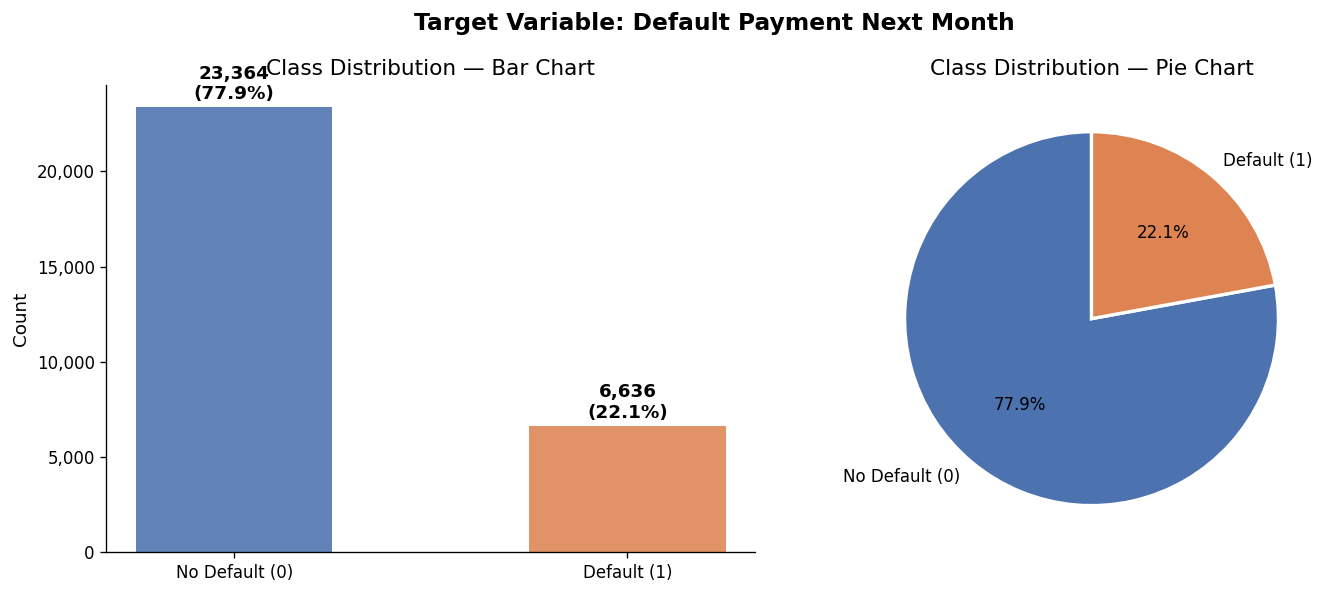


Default rate         : 22.12%
Class imbalance ratio : 3.52:1  (No Default : Default)

Imbalanced dataset — consider SMOTE, class_weight, or oversampling during modeling.


In [10]:
# Target Distribution
counts   = df[TARGET].value_counts().sort_index()
labels   = ['No Default (0)', 'Default (1)']
colors   = [PALETTE[0], PALETTE[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, alpha=0.88, edgecolor='none', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution — Bar Chart')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Pie Chart')

fig.suptitle('Target Variable: Default Payment Next Month', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

ratio = (df[TARGET]==0).sum() / (df[TARGET]==1).sum()
print(f'\nDefault rate         : {df[TARGET].mean()*100:.2f}%')
print(f'Class imbalance ratio : {ratio:.2f}:1  (No Default : Default)')
print(f'\nImbalanced dataset — consider SMOTE, class_weight, or oversampling during modeling.')

---
## 4. Demographic Analysis <a id='4-demographics'></a>

Exploring how **Gender, Education, Marriage, and Age** relate to default rates.

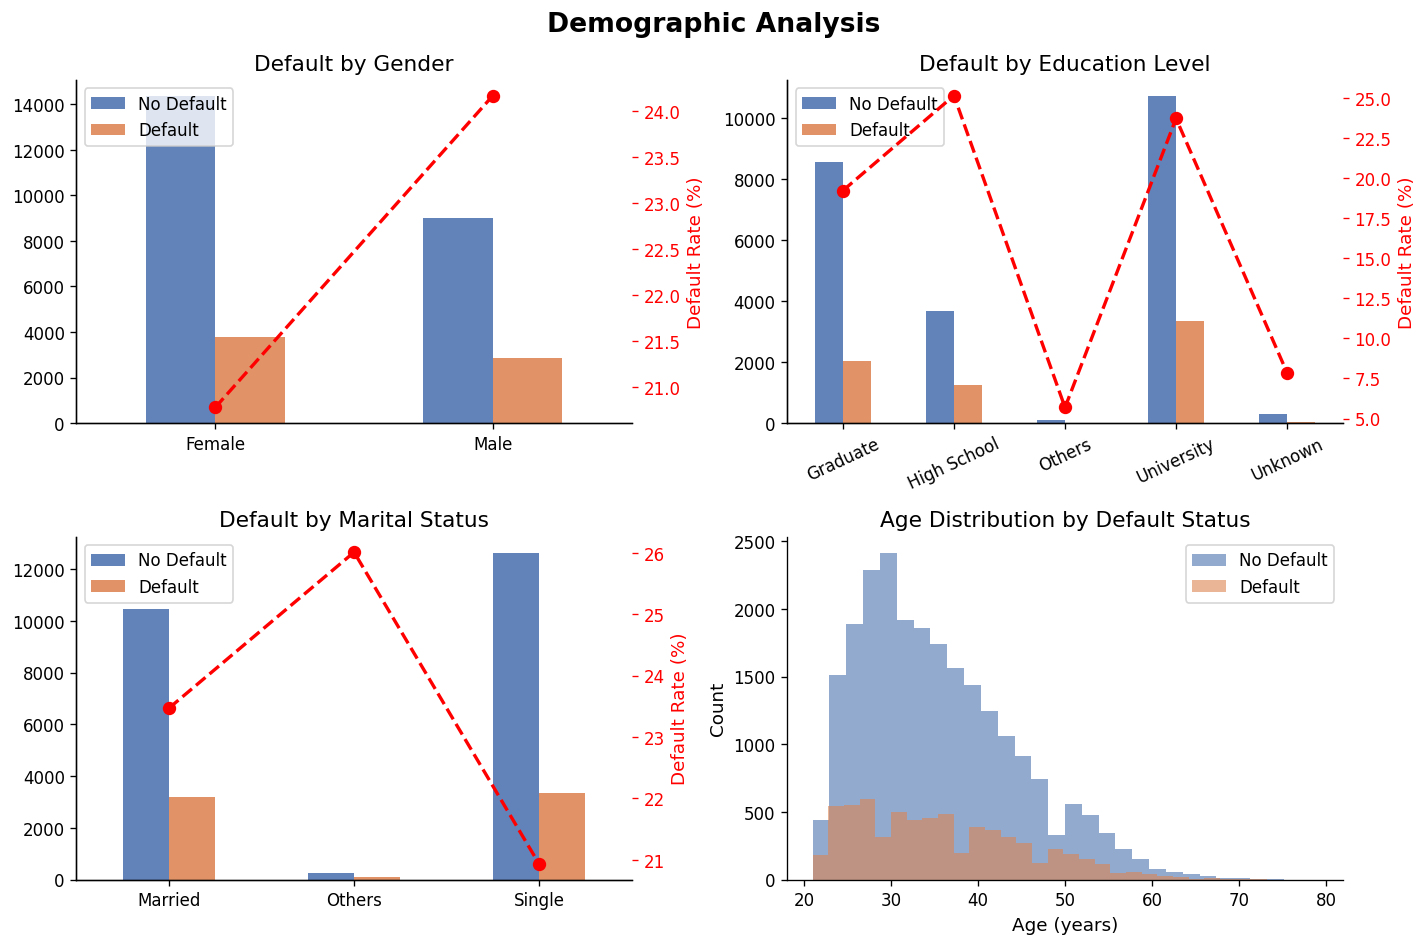

In [11]:
#Label Mappings
sex_map  = {1: 'Male', 2: 'Female'}
edu_map  = {1: 'Graduate', 2: 'University', 3: 'High School',
            4: 'Others', 5: 'Unknown', 6: 'Unknown'}
mar_map  = {1: 'Married', 2: 'Single', 3: 'Others'}

df['SEX_L'] = df['SEX'].map(sex_map)
df['EDU_L'] = df['EDUCATION'].map(edu_map)
df['MAR_L'] = df['MARRIAGE'].map(mar_map)

# Helper: default rate by category
def default_rate(col_label):
    return df.groupby(col_label)[TARGET].mean().mul(100).round(2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#Gender
sex_cnt = df.groupby(['SEX_L', TARGET]).size().unstack()
sex_cnt.plot(kind='bar', ax=axes[0,0], color=[PALETTE[0], PALETTE[1]],
             edgecolor='none', rot=0, alpha=0.88)
ax2 = axes[0,0].twinx()
dr = default_rate('SEX_L')
ax2.plot(dr.index, dr.values, 'o--', color='red', ms=7, lw=2, label='Default Rate %')
ax2.set_ylabel('Default Rate (%)', color='red')
ax2.tick_params(axis='y', colors='red')
axes[0,0].set_title('Default by Gender')
axes[0,0].set_xlabel('')
axes[0,0].legend(['No Default', 'Default'], loc='upper left')

#Education
edu_cnt = df.groupby(['EDU_L', TARGET]).size().unstack()
edu_cnt.plot(kind='bar', ax=axes[0,1], color=[PALETTE[0], PALETTE[1]],
             edgecolor='none', rot=25, alpha=0.88)
ax3 = axes[0,1].twinx()
dr_edu = default_rate('EDU_L')
ax3.plot(range(len(dr_edu)), dr_edu.values, 'o--', color='red', ms=7, lw=2)
ax3.set_ylabel('Default Rate (%)', color='red')
ax3.tick_params(axis='y', colors='red')
axes[0,1].set_title('Default by Education Level')
axes[0,1].set_xlabel('')
axes[0,1].legend(['No Default', 'Default'], loc='upper left')

#Marriage
mar_cnt = df.groupby(['MAR_L', TARGET]).size().unstack()
mar_cnt.plot(kind='bar', ax=axes[1,0], color=[PALETTE[0], PALETTE[1]],
             edgecolor='none', rot=0, alpha=0.88)
ax4 = axes[1,0].twinx()
dr_mar = default_rate('MAR_L')
ax4.plot(range(len(dr_mar)), dr_mar.values, 'o--', color='red', ms=7, lw=2)
ax4.set_ylabel('Default Rate (%)', color='red')
ax4.tick_params(axis='y', colors='red')
axes[1,0].set_title('Default by Marital Status')
axes[1,0].set_xlabel('')
axes[1,0].legend(['No Default', 'Default'], loc='upper left')

#Age Distribution
for val, label, color in [(0, 'No Default', PALETTE[0]), (1, 'Default', PALETTE[1])]:
    axes[1,1].hist(df[df[TARGET]==val]['AGE'], bins=30,
                   alpha=0.6, label=label, color=color, edgecolor='none')
axes[1,1].set_title('Age Distribution by Default Status')
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

fig.suptitle('Demographic Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

#Cleanup temp label columns
df.drop(columns=['SEX_L', 'EDU_L', 'MAR_L'], inplace=True)

#Default Rate by Age Group

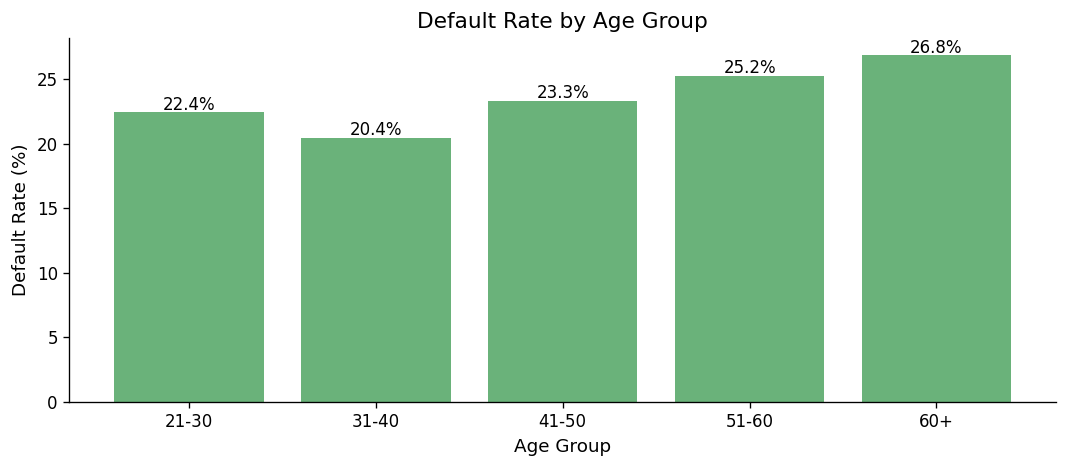

In [12]:
#Default Rate by Age Group
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80],
                          labels=['21-30','31-40','41-50','51-60','60+'])
age_dr = df.groupby('AGE_GROUP')[TARGET].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_dr.index.astype(str), age_dr.values,
              color=PALETTE[2], alpha=0.88, edgecolor='none')
for bar, val in zip(bars, age_dr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_title('Default Rate by Age Group')
ax.set_xlabel('Age Group'); ax.set_ylabel('Default Rate (%)')
plt.tight_layout(); plt.show()

df.drop(columns=['AGE_GROUP'], inplace=True)

#Credit Limit Distribution by Default Status

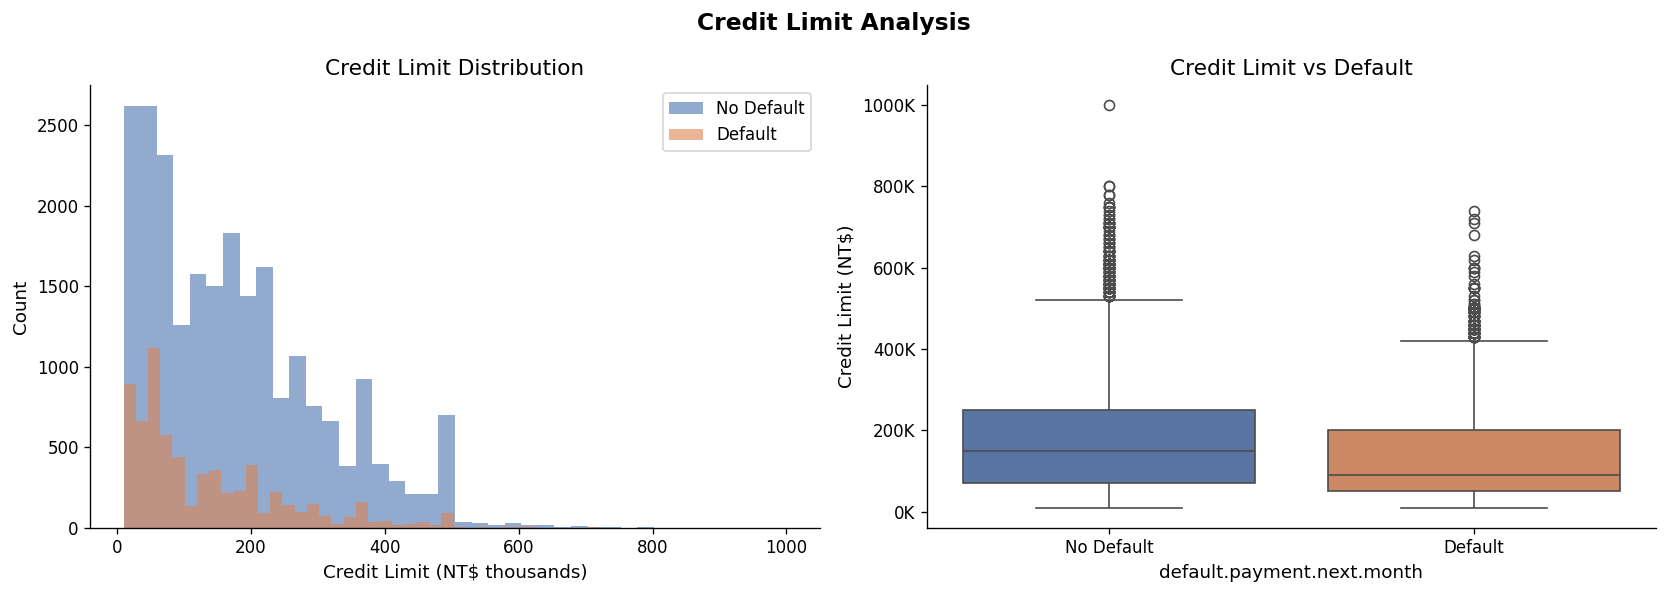

Insight: Defaulters tend to have LOWER credit limits — lower credit = higher risk proxy.


In [13]:
#Credit Limit Distribution by Default Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0, 'No Default', PALETTE[0]), (1, 'Default', PALETTE[1])]:
    axes[0].hist(df[df[TARGET]==val]['LIMIT_BAL']/1000, bins=40,
                 alpha=0.6, label=label, color=color, edgecolor='none')
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('Credit Limit (NT$ thousands)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(x=TARGET, y='LIMIT_BAL', data=df, palette=[PALETTE[0], PALETTE[1]], ax=axes[1])
axes[1].set_title('Credit Limit vs Default')
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].set_ylabel('Credit Limit (NT$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

fig.suptitle('Credit Limit Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Insight: Defaulters tend to have LOWER credit limits — lower credit = higher risk proxy.')

---
## 5. Payment History Analysis <a id='5-payment'></a>

`PAY_0` to `PAY_6` represent **repayment status** each month.  
Negative values = paid on time; Positive values = months of delay.  
This is one of the **most predictive** feature groups.

#Payment Status Columns

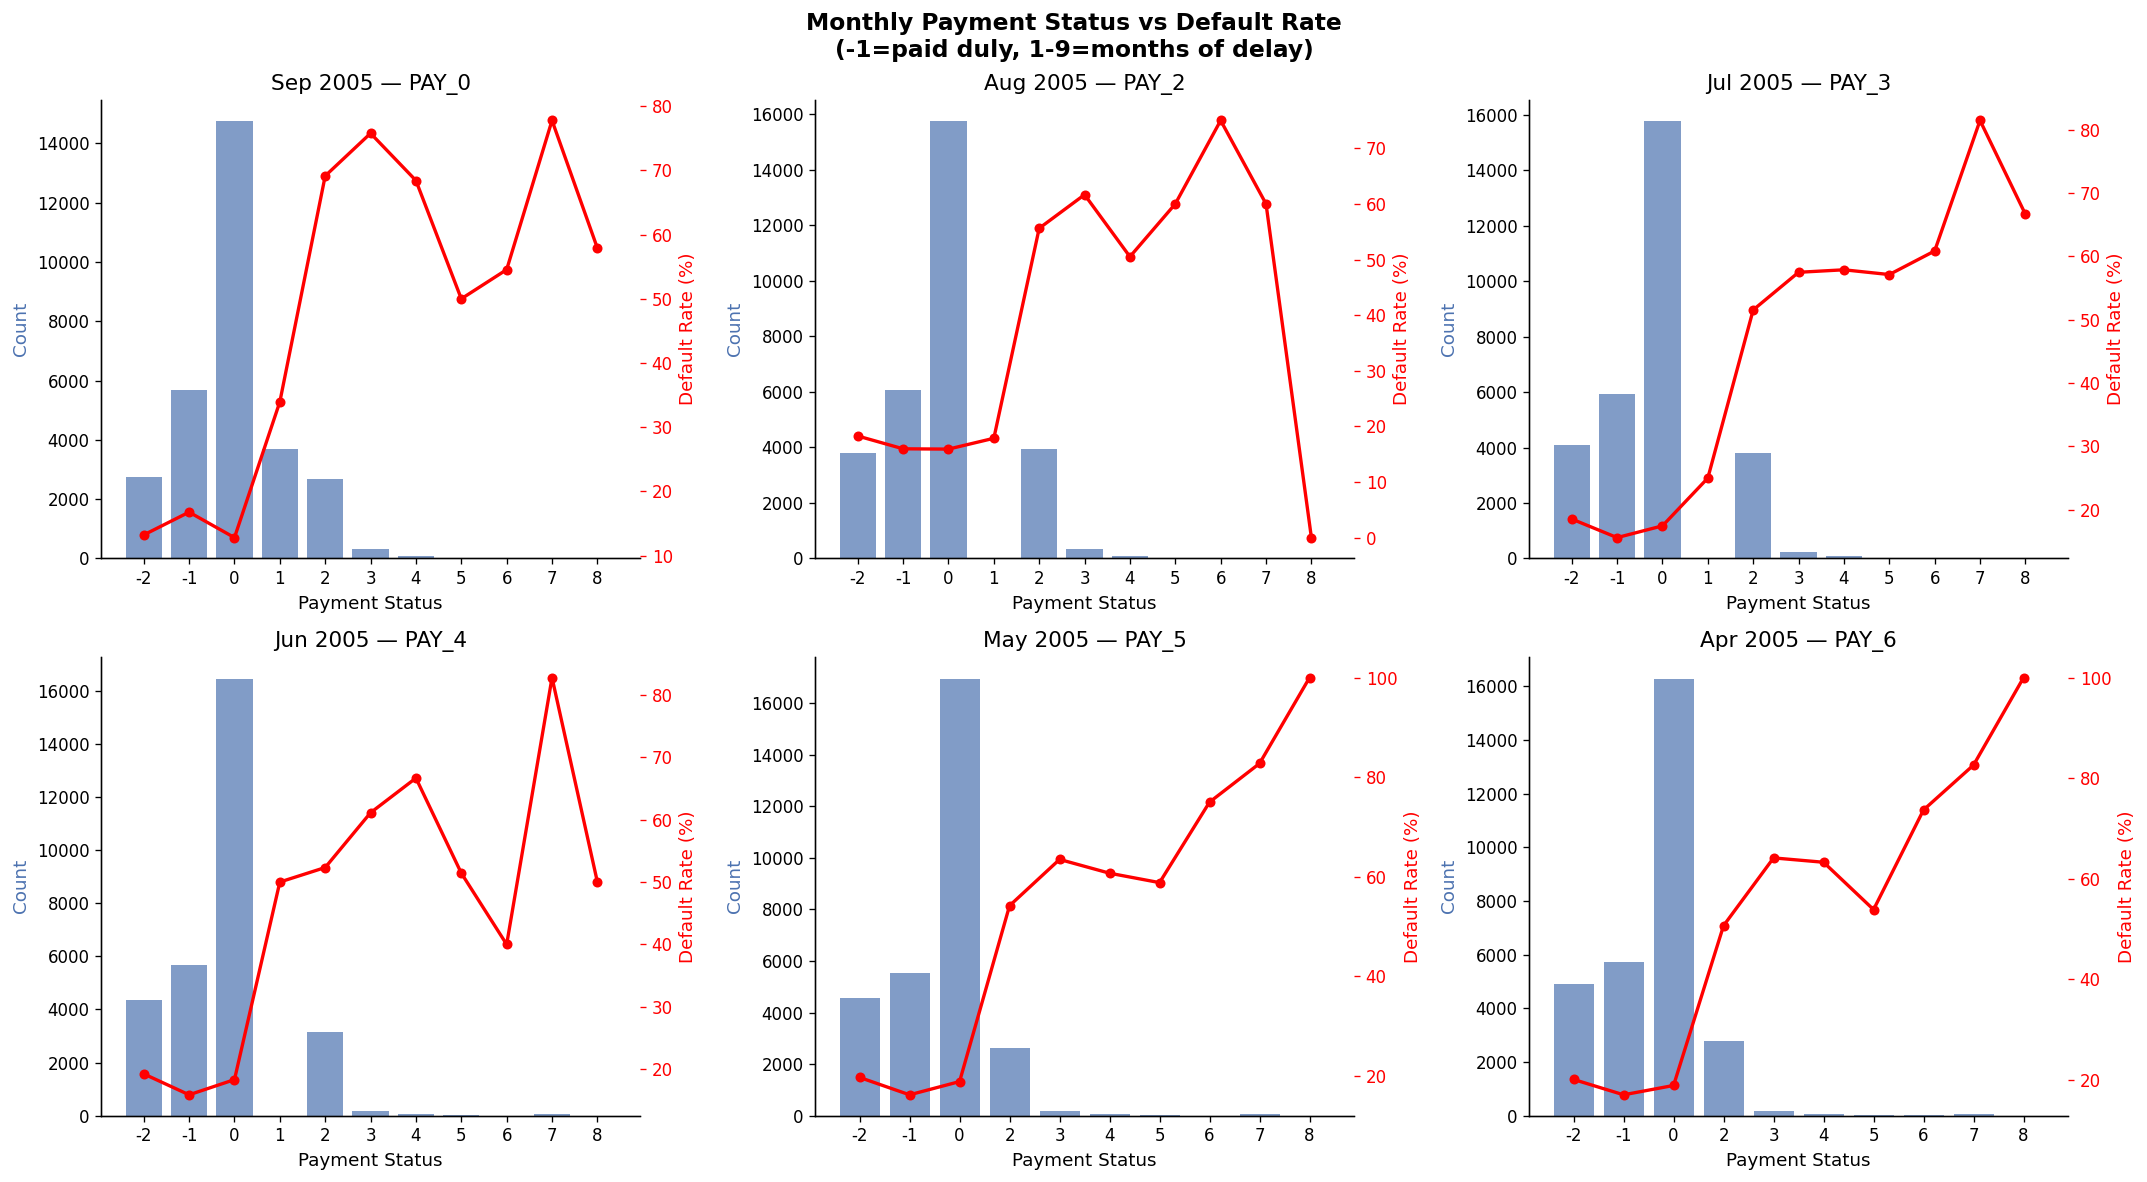

Insight: As payment delay (PAY_0 to PAY_6) increases, default rate rises sharply.


In [14]:
#Payment Status Columns
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
months   = ['Sep','Aug','Jul','Jun','May','Apr']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, month) in enumerate(zip(pay_cols, months)):
    dr = df.groupby(col)[TARGET].mean().mul(100)
    counts_pay = df[col].value_counts().sort_index()

    ax1 = axes[i]
    bars = ax1.bar(counts_pay.index.astype(str), counts_pay.values,
                   color=PALETTE[0], alpha=0.7, edgecolor='none')
    ax1.set_title(f'{month} 2005 — {col}')
    ax1.set_xlabel('Payment Status')
    ax1.set_ylabel('Count', color=PALETTE[0])

    ax2 = ax1.twinx()
    ax2.plot(range(len(dr)), dr.values, 'o-', color='red', ms=5, lw=2, label='Default %')
    ax2.set_ylabel('Default Rate (%)', color='red')
    ax2.tick_params(axis='y', colors='red')

fig.suptitle('Monthly Payment Status vs Default Rate\n(-1=paid duly, 1-9=months of delay)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('Insight: As payment delay (PAY_0 to PAY_6) increases, default rate rises sharply.')

#Heatmap: Avg Payment Status by Default Class

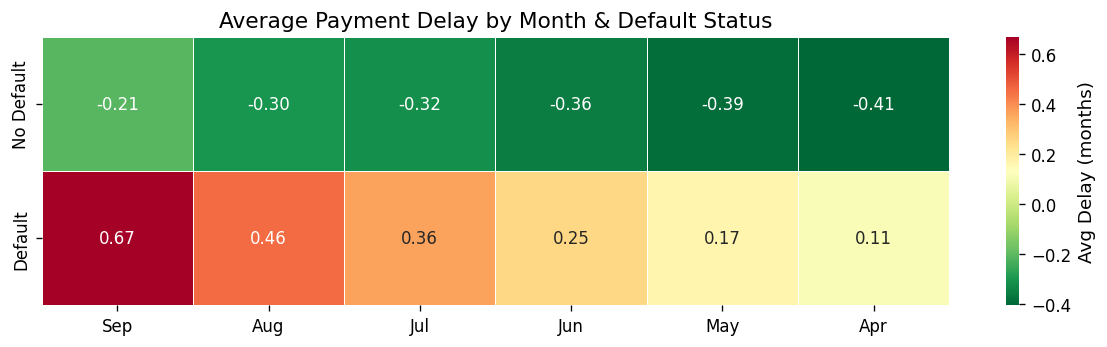

In [15]:
#Heatmap: Avg Payment Status by Default Class
pay_avg = df.groupby(TARGET)[pay_cols].mean()
pay_avg.index = ['No Default', 'Default']
pay_avg.columns = months

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(pay_avg, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Avg Delay (months)'})
ax.set_title('Average Payment Delay by Month & Default Status')
plt.tight_layout(); plt.show()


## 6.Bill & Payment Amount Analysis <a id='6-amounts'></a>

##Bill Amount Trends

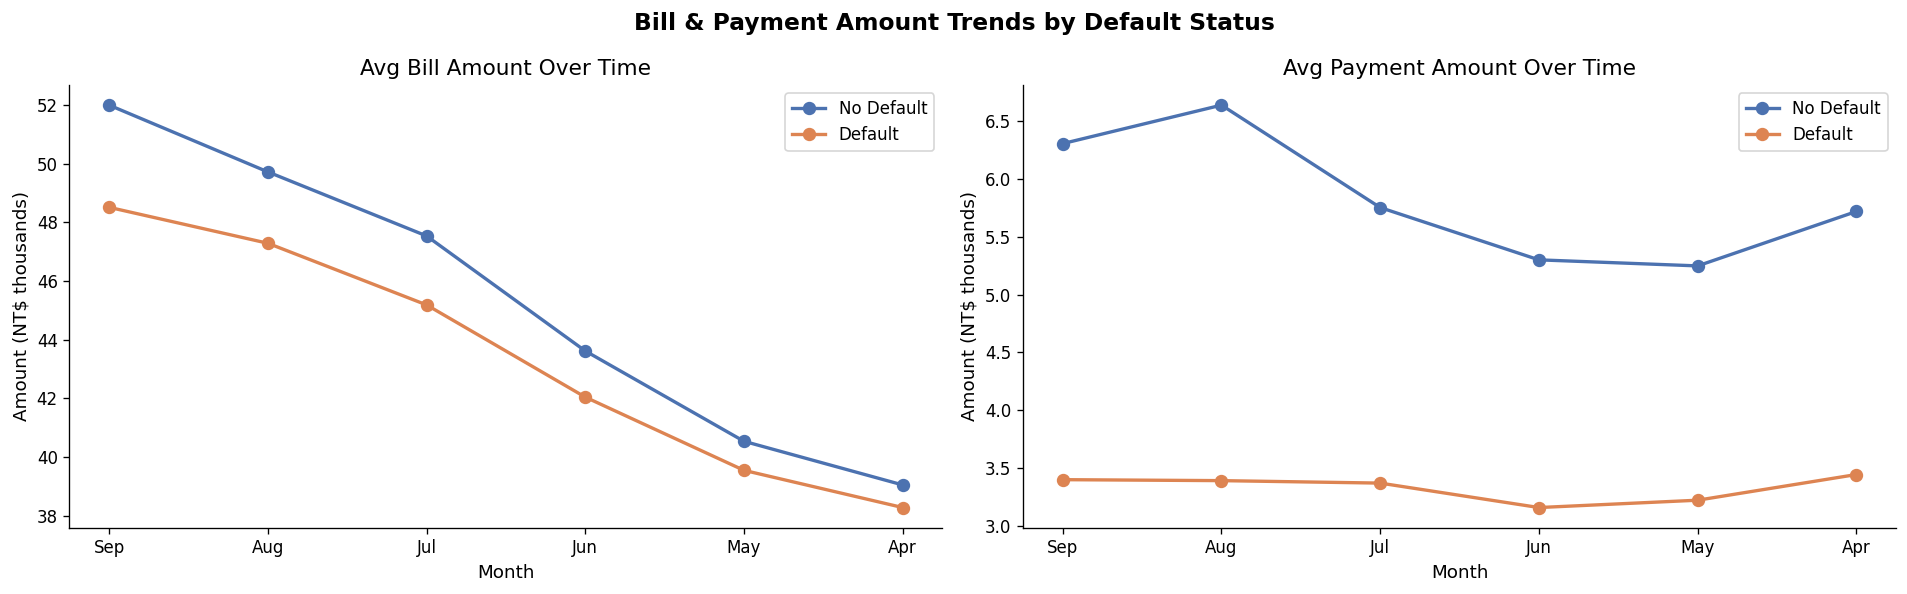

In [16]:
# Bill Amount Trends
bill_cols  = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
month_labels = ['Sep','Aug','Jul','Jun','May','Apr']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for grp, label, color in [(0,'No Default',PALETTE[0]), (1,'Default',PALETTE[1])]:
    subset = df[df[TARGET]==grp]
    means  = [subset[c].mean()/1000 for c in bill_cols]
    axes[0].plot(month_labels, means, 'o-', color=color, label=label, lw=2, ms=7)

axes[0].set_title('Avg Bill Amount Over Time')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Amount (NT$ thousands)')
axes[0].legend()

for grp, label, color in [(0,'No Default',PALETTE[0]), (1,'Default',PALETTE[1])]:
    subset = df[df[TARGET]==grp]
    means  = [subset[c].mean()/1000 for c in pay_amt_cols]
    axes[1].plot(month_labels, means, 'o-', color=color, label=label, lw=2, ms=7)

axes[1].set_title('Avg Payment Amount Over Time')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Amount (NT$ thousands)')
axes[1].legend()

fig.suptitle('Bill & Payment Amount Trends by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

##Payment Ratio: How much did clients pay vs bill?

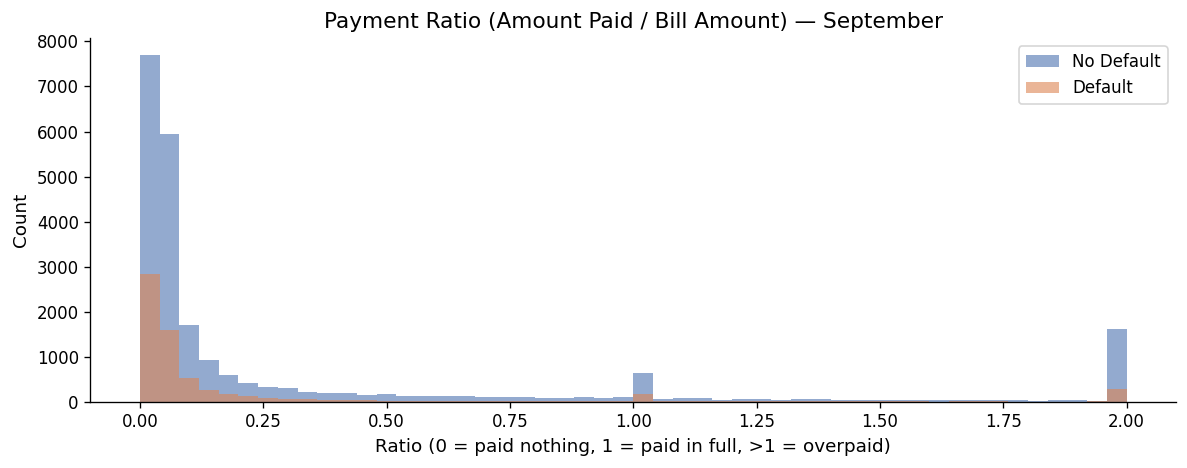

Insight: Defaulters pay a much smaller fraction of their bill each month.


In [17]:
# Payment Ratio: How much did clients pay vs bill?
df['PAY_RATIO_SEP'] = np.where(
    df['BILL_AMT1'] > 0,
    df['PAY_AMT1'] / df['BILL_AMT1'],
    0
).clip(0, 2)  # cap at 200%

fig, ax = plt.subplots(figsize=(10, 4))
for grp, label, color in [(0,'No Default',PALETTE[0]), (1,'Default',PALETTE[1])]:
    ax.hist(df[df[TARGET]==grp]['PAY_RATIO_SEP'], bins=50,
            alpha=0.6, label=label, color=color, edgecolor='none')
ax.set_title('Payment Ratio (Amount Paid / Bill Amount) — September')
ax.set_xlabel('Ratio (0 = paid nothing, 1 = paid in full, >1 = overpaid)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

df.drop(columns=['PAY_RATIO_SEP'], inplace=True)
print('Insight: Defaulters pay a much smaller fraction of their bill each month.')

---
## 7. Correlation Analysis <a id='7-correlation'></a>

##Full Correlation Heatmap

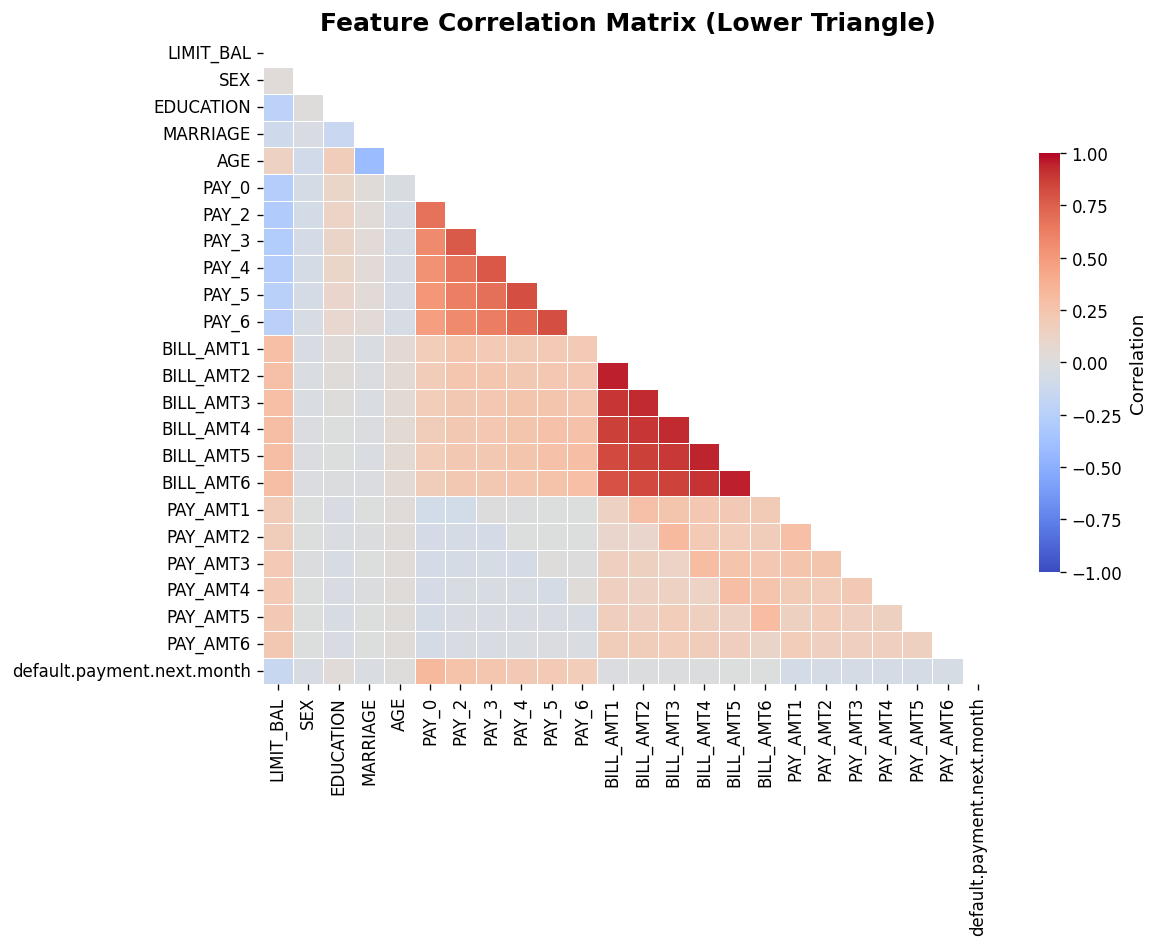

In [18]:
#Full Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            ax=ax, linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.65, 'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

##Top Features Correlated with Target

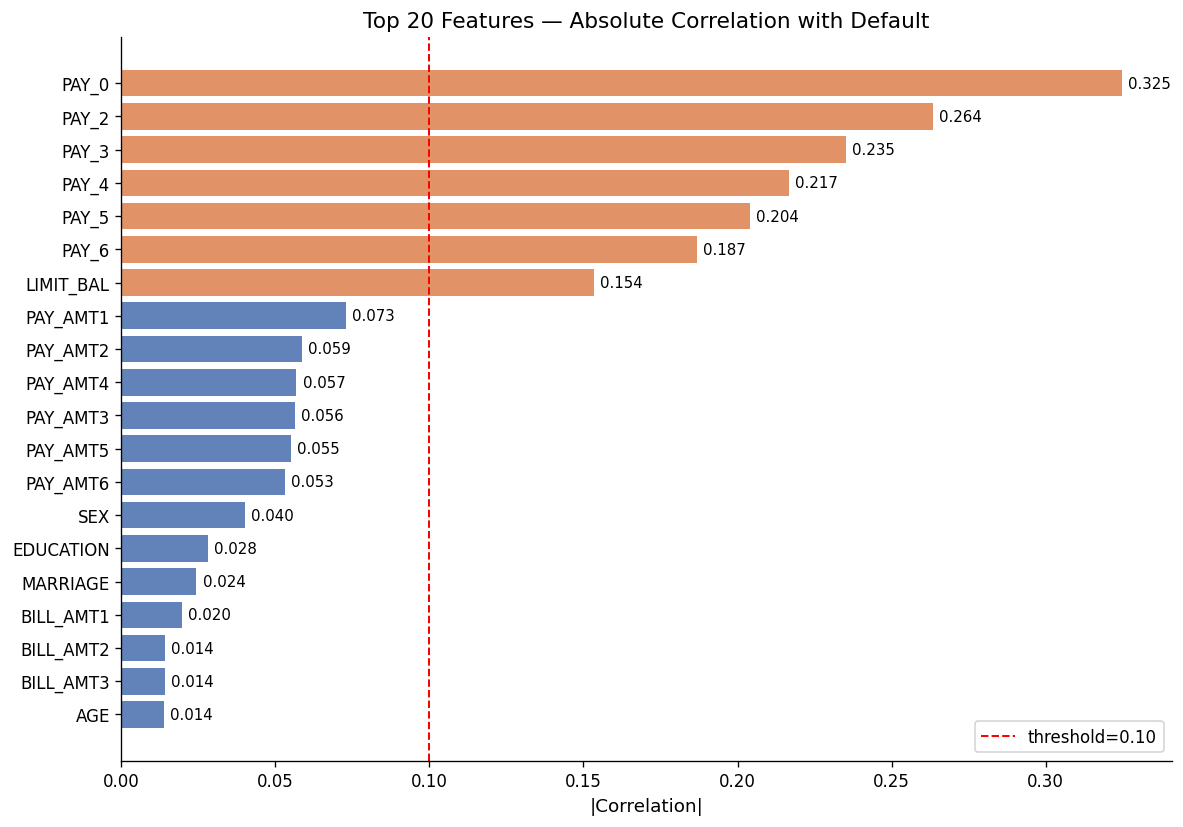


Top 15 features by absolute correlation with target:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006


In [19]:
# op Features Correlated with Target
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [PALETTE[1] if v > 0.1 else PALETTE[0]
              for v in target_corr.head(20).values]
bars = ax.barh(target_corr.head(20).index[::-1],
               target_corr.head(20).values[::-1],
               color=colors_bar[::-1], alpha=0.88, edgecolor='none')
for bar, val in zip(bars, target_corr.head(20).values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.axvline(0.1, color='red', linestyle='--', lw=1.2, label='threshold=0.10')
ax.set_title('Top 20 Features — Absolute Correlation with Default', fontsize=13)
ax.set_xlabel('|Correlation|')
ax.legend()
plt.tight_layout(); plt.show()

print('\nTop 15 features by absolute correlation with target:')
print(target_corr.head(15).to_string())

---
## 8. Statistical Summary <a id='8-summary'></a>

##Full Describe

In [20]:
# Full Describe
print('  FULL DATASET STATISTICAL SUMMARY')
print('='*70)
print(df.describe().round(2).to_string())
print()
print(f'Class imbalance ratio : {(df[TARGET]==0).sum()/(df[TARGET]==1).sum():.2f}:1')
print(f'Default rate          : {df[TARGET].mean()*100:.2f}%')

  FULL DATASET STATISTICAL SUMMARY
        LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE     PAY_0     PAY_2     PAY_3     PAY_4     PAY_5     PAY_6  BILL_AMT1  BILL_AMT2   BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6   PAY_AMT1    PAY_AMT2   PAY_AMT3   PAY_AMT4   PAY_AMT5   PAY_AMT6  default.payment.next.month
count    30000.00  30000.00   30000.00  30000.00  30000.00  30000.00  30000.00  30000.00  30000.00  30000.00  30000.00   30000.00   30000.00    30000.00   30000.00   30000.00   30000.00   30000.00    30000.00   30000.00   30000.00   30000.00   30000.00                    30000.00
mean    167484.32      1.60       1.85      1.55     35.49     -0.02     -0.13     -0.17     -0.22     -0.27     -0.29   51223.33   49179.08    47013.15   43262.95   40311.40   38871.76    5663.58     5921.16    5225.68    4826.08    4799.39    5215.50                        0.22
std     129747.66      0.49       0.79      0.52      9.22      1.12      1.20      1.20      1.17      1.13      1.15   7

##Default Rate by Demographic Segment (Summary Table)

In [21]:
#Default Rate by Demographic Segment (Summary Table)
df['SEX_L'] = df['SEX'].map({1:'Male', 2:'Female'})
df['EDU_L'] = df['EDUCATION'].map({1:'Graduate',2:'University',3:'High School',
                                    4:'Others',5:'Unknown',6:'Unknown'})
df['MAR_L'] = df['MARRIAGE'].map({1:'Married',2:'Single',3:'Others'})

print('\n── Default Rate by Gender ──')
print(df.groupby('SEX_L')[TARGET].agg(['mean','count'])
        .rename(columns={'mean':'Default Rate','count':'N'})
        .assign(**{'Default Rate': lambda x: (x['Default Rate']*100).round(2)})
        .to_string())

print('\n── Default Rate by Education ──')
print(df.groupby('EDU_L')[TARGET].agg(['mean','count'])
        .rename(columns={'mean':'Default Rate','count':'N'})
        .assign(**{'Default Rate': lambda x: (x['Default Rate']*100).round(2)})
        .to_string())

print('\n── Default Rate by Marriage ──')
print(df.groupby('MAR_L')[TARGET].agg(['mean','count'])
        .rename(columns={'mean':'Default Rate','count':'N'})
        .assign(**{'Default Rate': lambda x: (x['Default Rate']*100).round(2)})
        .to_string())

df.drop(columns=['SEX_L','EDU_L','MAR_L'], inplace=True)


── Default Rate by Gender ──
        Default Rate      N
SEX_L                      
Female         20.78  18112
Male           24.17  11888

── Default Rate by Education ──
             Default Rate      N
EDU_L                           
Graduate            19.23  10585
High School         25.16   4917
Others               5.69    123
University          23.73  14030
Unknown              7.85    331

── Default Rate by Marriage ──
         Default Rate      N
MAR_L                       
Married         23.47  13659
Others          26.01    323
Single          20.93  15964


---
## 9.Feature Recommendations for Deep Learning <a id='9-dl-features'></a>

> Based on the EDA above, here are the best features to use when building a Deep Learning model.

### Tier 1 — High Priority (Strong Predictors)

| Feature | Type | Why it matters |
|---|---|---|
| `PAY_0` | Ordinal | Most recent payment status — strongest single predictor |
| `PAY_2` to `PAY_6` | Ordinal | Payment delay history — temporal pattern |
| `LIMIT_BAL` | Continuous | Lower limit = higher risk |
| `PAY_AMT1` to `PAY_AMT6` | Continuous | Actual payment behavior over time |

### Tier 2 — Moderate Priority (Contextual)

| Feature | Type | Why it matters |
|---|---|---|
| `BILL_AMT1` to `BILL_AMT6` | Continuous | Spending pattern / utilization |
| `AGE` | Continuous | Slight signal; younger clients default more |
| `EDUCATION` | Categorical | Graduate school shows lower default |
| `MARRIAGE` | Categorical | Minor signal |
| `SEX` | Binary | Small but consistent signal |

### Engineered Features to Add

```python
# 1. Payment Ratio each month (how much was paid vs billed)
for i in range(1, 7):
    df[f'PAY_RATIO_{i}'] = df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'] + 1)

# 2. Total bill and payment
df['TOTAL_BILL']    = df[[f'BILL_AMT{i}' for i in range(1,7)]].sum(axis=1)
df['TOTAL_PAID']    = df[[f'PAY_AMT{i}'  for i in range(1,7)]].sum(axis=1)

# 3. Credit utilization rate
df['UTIL_RATE']     = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 4. Count of months with delayed payment
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df['DELAY_COUNT']   = (df[pay_cols] > 0).sum(axis=1)

# 5. Max delay across all months
df['MAX_DELAY']     = df[pay_cols].max(axis=1)
```

### Recommended Deep Learning Architecture

```
Input Layer  →  [all features after engineering ~35 features]
     ↓
Embedding    →  for categorical: SEX, EDUCATION, MARRIAGE (optional)
     ↓
Dense(256, relu)  →  BatchNorm  →  Dropout(0.3)
     ↓
Dense(128, relu)  →  BatchNorm  →  Dropout(0.3)
     ↓
Dense(64, relu)   →  BatchNorm  →  Dropout(0.2)
     ↓
Dense(1, sigmoid)  →  Binary output
```

### Preprocessing Checklist for DL

| Step | Action |
|---|---|
| **Scaling** | StandardScaler or MinMaxScaler on all continuous features |
| **Imbalance** | Use `class_weight` or SMOTE — 78:22 ratio |
| **Categoricals** | One-hot or embedding for SEX, EDU, MAR |
| **Validation** | Stratified K-Fold (k=5) |
| **Metric** | Focus on **AUC-ROC** and **Recall for class 1** (catching defaults matters most) |


In [23]:
print("━"*55)
print("  STEP 5 — FEATURE ENGINEERING")
print("━"*55)
print(f"  Input shape: {df.shape}")

# ── Define column groups HERE (fixes the NameError) ──────────────────────
BILL_COLS    = [f'BILL_AMT{i}' for i in range(1, 7)]
PAY_AMT_COLS = [f'PAY_AMT{i}'  for i in range(1, 7)]
PAY_ST_COLS  = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# ── Pay ratios ────────────────────────────────────────────────────────────
for i in range(1, 7):
    df[f'PAY_RATIO_{i}'] = (
        df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'].abs() + 1)
    ).clip(0, 5)

# ── Aggregates ────────────────────────────────────────────────────────────
df['TOTAL_BILL']        = df[BILL_COLS].sum(axis=1)
df['TOTAL_PAID']        = df[PAY_AMT_COLS].sum(axis=1)
df['OVERALL_PAY_RATIO'] = (df['TOTAL_PAID'] / (df['TOTAL_BILL'].abs() + 1)).clip(0, 5)
df['UTIL_RATE']         = (df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)).clip(0, 2)
df['DELAY_COUNT']       = (df[PAY_ST_COLS] > 0).sum(axis=1)
df['MAX_DELAY']         = df[PAY_ST_COLS].max(axis=1)
df['AVG_DELAY']         = df[PAY_ST_COLS].mean(axis=1)

# ── 3 New features ────────────────────────────────────────────────────────
df['RECENT_DELAY']   = (df['PAY_0'] > 0).astype(int)
df['ZERO_PAY_COUNT'] = sum(
    (df[f'PAY_AMT{i}'] == 0).astype(int) for i in range(1, 7)
)
df['BILL_TREND']     = df['BILL_AMT1'] - df['BILL_AMT6']

print(f"  Output shape : {df.shape}")
print(f"\n  Features added:")
print(f"    PAY_RATIO_1–6  : payment-to-bill ratio per month")
print(f"    TOTAL_BILL     : sum of all 6 bill amounts")
print(f"    TOTAL_PAID     : sum of all 6 payment amounts")
print(f"    OVERALL_PAY_RATIO : total paid / total billed")
print(f"    UTIL_RATE      : latest bill / credit limit")
print(f"    DELAY_COUNT    : months with late payment")
print(f"    MAX_DELAY      : worst single month delay")
print(f"    AVG_DELAY      : average delay across months")
print(f"    RECENT_DELAY   : was last month late? (0/1)  ✚ NEW")
print(f"    ZERO_PAY_COUNT : months with zero payment    ✚ NEW")
print(f"    BILL_TREND     : debt growing or shrinking   ✚ NEW")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 5 — FEATURE ENGINEERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input shape: (30000, 30)
  Output shape : (30000, 40)

  Features added:
    PAY_RATIO_1–6  : payment-to-bill ratio per month
    TOTAL_BILL     : sum of all 6 bill amounts
    TOTAL_PAID     : sum of all 6 payment amounts
    OVERALL_PAY_RATIO : total paid / total billed
    UTIL_RATE      : latest bill / credit limit
    DELAY_COUNT    : months with late payment
    MAX_DELAY      : worst single month delay
    AVG_DELAY      : average delay across months
    RECENT_DELAY   : was last month late? (0/1)  ✚ NEW
    ZERO_PAY_COUNT : months with zero payment    ✚ NEW
    BILL_TREND     : debt growing or shrinking   ✚ NEW


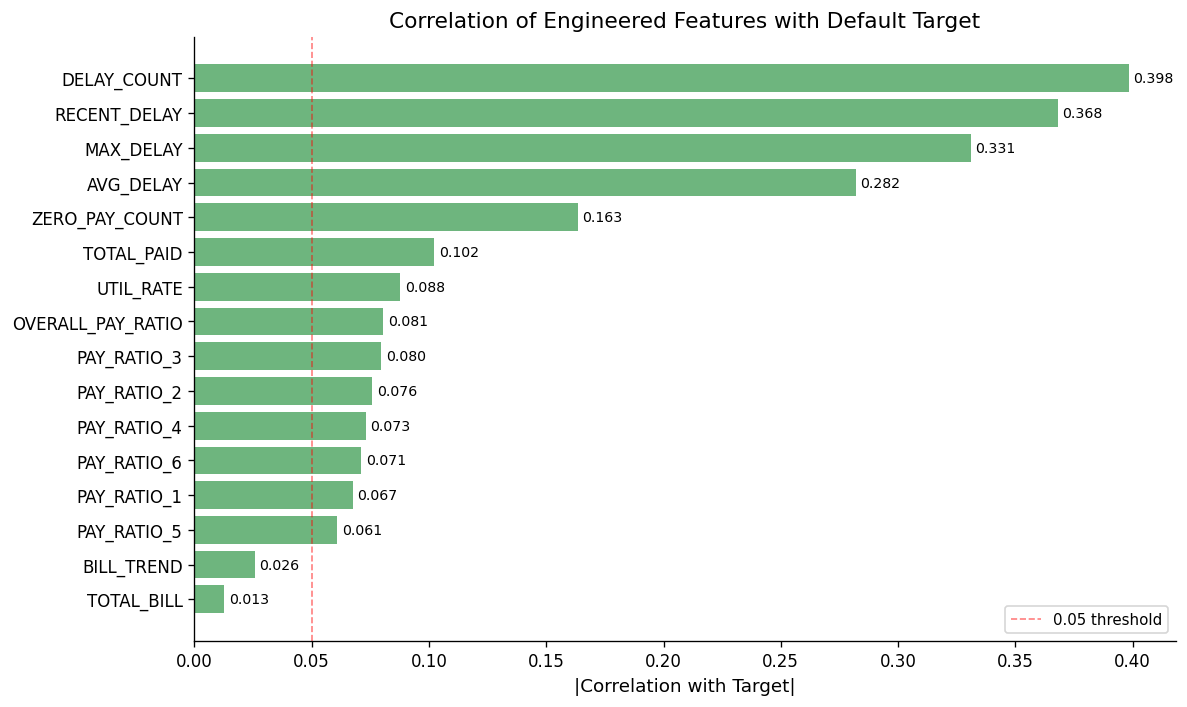


  Feature Correlation Ranking:
  Feature                |Corr|     Strength
  ---------------------------------------------
  DELAY_COUNT            0.3984     🔴 Strong
  RECENT_DELAY           0.3681     🔴 Strong
  MAX_DELAY              0.3310     🔴 Strong
  AVG_DELAY              0.2820     🔴 Strong
  ZERO_PAY_COUNT         0.1634     🔴 Strong
  TOTAL_PAID             0.1024     🟡 Moderate
  UTIL_RATE              0.0878     🟡 Moderate
  OVERALL_PAY_RATIO      0.0805     🟡 Moderate
  PAY_RATIO_3            0.0796     🟡 Moderate
  PAY_RATIO_2            0.0759     🟡 Moderate
  PAY_RATIO_4            0.0730     🟡 Moderate
  PAY_RATIO_6            0.0711     🟡 Moderate
  PAY_RATIO_1            0.0674     🟡 Moderate
  PAY_RATIO_5            0.0608     🟡 Moderate
  BILL_TREND             0.0256     ⚪ Weak
  TOTAL_BILL             0.0127     ⚪ Weak

  Summary: EDA Complete!
  → RECENT_DELAY and DELAY_COUNT are strongest engineered predictors.
  → ZERO_PAY_COUNT and MAX_DELAY capture fina

In [26]:
# Correlation of Engineered Features with Target
ENGINEERED_FEATURES = [
    'PAY_RATIO_1','PAY_RATIO_2','PAY_RATIO_3',
    'PAY_RATIO_4','PAY_RATIO_5','PAY_RATIO_6',
    'TOTAL_BILL','TOTAL_PAID','OVERALL_PAY_RATIO',
    'UTIL_RATE','DELAY_COUNT','MAX_DELAY','AVG_DELAY',
    'RECENT_DELAY','ZERO_PAY_COUNT','BILL_TREND'       # ← 3 new ones
]

# Use real df (not df_eng which is deleted)
eng_corr = df.corr(numeric_only=True)[TARGET].abs()
eng_new  = eng_corr[ENGINEERED_FEATURES].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(eng_new.index[::-1], eng_new.values[::-1],
               color=PALETTE[2], alpha=0.85, edgecolor='none')

# Add value labels on bars
for bar, val in zip(bars, eng_new.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.set_title('Correlation of Engineered Features with Default Target', fontsize=13)
ax.set_xlabel('|Correlation with Target|')
ax.axvline(0.05, color='red', ls='--', lw=1, alpha=0.5, label='0.05 threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print ranked summary
print("\n  Feature Correlation Ranking:")
print(f"  {'Feature':<22} {'|Corr|':<10} {'Strength'}")
print(f"  {'-'*45}")
for feat, corr in eng_new.items():
    strength = "🔴 Strong" if corr >= 0.15 else "🟡 Moderate" if corr >= 0.05 else "⚪ Weak"
    print(f"  {feat:<22} {corr:<10.4f} {strength}")

print('\n  Summary: EDA Complete!')
print('  → RECENT_DELAY and DELAY_COUNT are strongest engineered predictors.')
print('  → ZERO_PAY_COUNT and MAX_DELAY capture financial distress well.')
print('  → BILL_TREND adds trend signal missing from static features.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FULL FEATURE CORRELATION WITH TARGET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total features analysed: 39


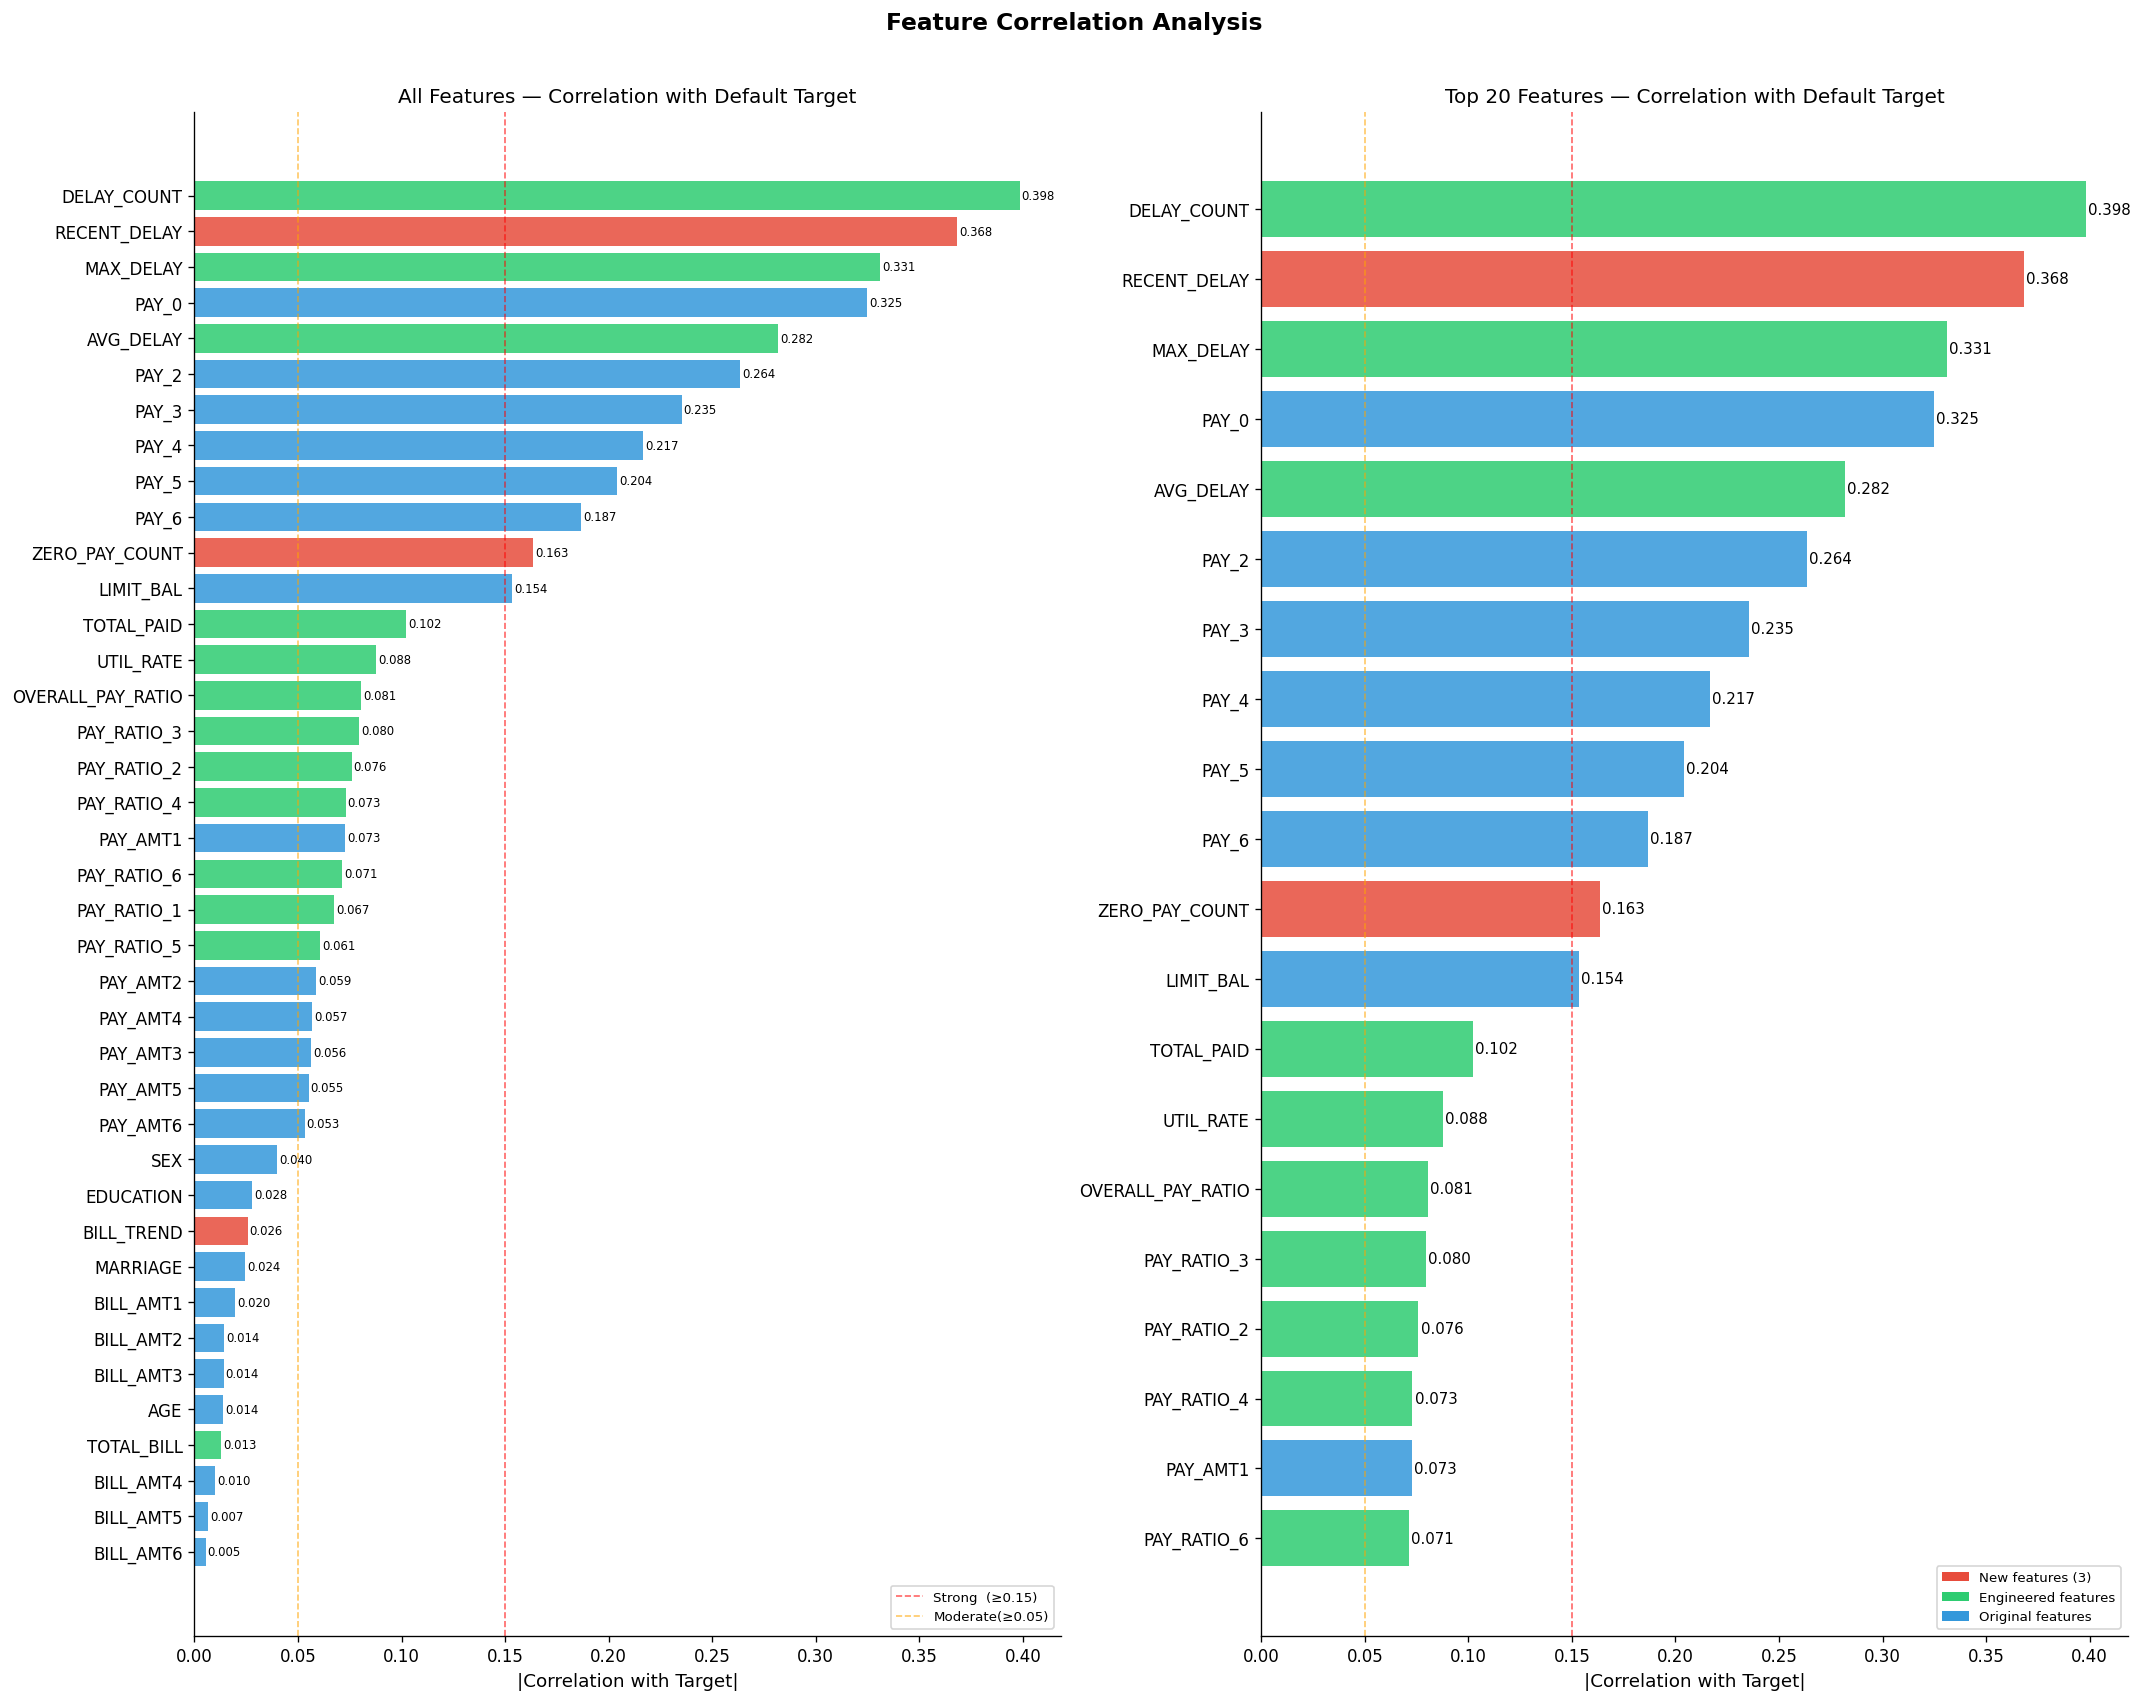


  Rank   Feature                |Corr|     Type            Strength
  -----------------------------------------------------------------
  1      DELAY_COUNT            0.3984     🟢 Engineered    Strong
  2      RECENT_DELAY           0.3681     🔴 New           Strong
  3      MAX_DELAY              0.3310     🟢 Engineered    Strong
  4      PAY_0                  0.3248     🔵 Original      Strong
  5      AVG_DELAY              0.2820     🟢 Engineered    Strong
  6      PAY_2                  0.2636     🔵 Original      Strong
  7      PAY_3                  0.2353     🔵 Original      Strong
  8      PAY_4                  0.2166     🔵 Original      Strong
  9      PAY_5                  0.2041     🔵 Original      Strong
  10     PAY_6                  0.1869     🔵 Original      Strong
  11     ZERO_PAY_COUNT         0.1634     🔴 New           Strong
  12     LIMIT_BAL              0.1535     🔵 Original      Strong
  13     TOTAL_PAID             0.1024     🟢 Engineered    Moderate
  1

In [27]:
# ── Full Correlation Analysis — All Features with Target ──────────────────
print("━"*55)
print("  FULL FEATURE CORRELATION WITH TARGET")
print("━"*55)

# Compute correlation of ALL features with target
all_corr = df.corr(numeric_only=True)[TARGET].abs().drop(TARGET)
all_corr = all_corr.sort_values(ascending=False)

print(f"  Total features analysed: {len(all_corr)}")

# ── Plot: All features ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Left: ALL features
colors = []
for feat in all_corr.index:
    if feat in ['RECENT_DELAY', 'ZERO_PAY_COUNT', 'BILL_TREND']:
        colors.append('#E74C3C')   # red  = new features
    elif feat in ENGINEERED_FEATURES:
        colors.append('#2ECC71')   # green = engineered
    else:
        colors.append('#3498DB')   # blue = original

bars = axes[0].barh(all_corr.index[::-1], all_corr.values[::-1],
                    color=colors[::-1], alpha=0.85, edgecolor='none')

for bar, val in zip(bars, all_corr.values[::-1]):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=7)

axes[0].axvline(0.15, color='red',    ls='--', lw=1, alpha=0.6, label='Strong  (≥0.15)')
axes[0].axvline(0.05, color='orange', ls='--', lw=1, alpha=0.6, label='Moderate(≥0.05)')
axes[0].set_title('All Features — Correlation with Default Target', fontsize=12)
axes[0].set_xlabel('|Correlation with Target|')
axes[0].legend(fontsize=8, loc='lower right')

# Right: Top 20 only (easier to read)
top20 = all_corr.head(20)
bar_colors_top = []
for feat in top20.index:
    if feat in ['RECENT_DELAY', 'ZERO_PAY_COUNT', 'BILL_TREND']:
        bar_colors_top.append('#E74C3C')
    elif feat in ENGINEERED_FEATURES:
        bar_colors_top.append('#2ECC71')
    else:
        bar_colors_top.append('#3498DB')

bars2 = axes[1].barh(top20.index[::-1], top20.values[::-1],
                     color=bar_colors_top[::-1], alpha=0.85, edgecolor='none')

for bar, val in zip(bars2, top20.values[::-1]):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

axes[1].axvline(0.15, color='red',    ls='--', lw=1, alpha=0.6)
axes[1].axvline(0.05, color='orange', ls='--', lw=1, alpha=0.6)
axes[1].set_title('Top 20 Features — Correlation with Default Target', fontsize=12)
axes[1].set_xlabel('|Correlation with Target|')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='New features (3)'),
    Patch(facecolor='#2ECC71', label='Engineered features'),
    Patch(facecolor='#3498DB', label='Original features'),
]
axes[1].legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Printed ranked table ──────────────────────────────────────────────────
print(f"\n  {'Rank':<6} {'Feature':<22} {'|Corr|':<10} {'Type':<15} {'Strength'}")
print(f"  {'-'*65}")

for rank, (feat, corr) in enumerate(all_corr.items(), 1):
    if feat in ['RECENT_DELAY', 'ZERO_PAY_COUNT', 'BILL_TREND']:
        ftype = '🔴 New'
    elif feat in ENGINEERED_FEATURES:
        ftype = '🟢 Engineered'
    else:
        ftype = '🔵 Original'

    strength = "Strong"   if corr >= 0.15 else \
               "Moderate" if corr >= 0.05 else "Weak"

    print(f"  {rank:<6} {feat:<22} {corr:<10.4f} {ftype:<15} {strength}")

# ── Summary ───────────────────────────────────────────────────────────────
strong   = all_corr[all_corr >= 0.15]
moderate = all_corr[(all_corr >= 0.05) & (all_corr < 0.15)]
weak     = all_corr[all_corr < 0.05]

print(f"\n  {'━'*45}")
print(f"  Strong   (≥0.15) : {len(strong):>3} features → {list(strong.index)}")
print(f"  Moderate (≥0.05) : {len(moderate):>3} features")
print(f"  Weak     (<0.05) : {len(weak):>3} features → consider dropping these")
print(f"\n  Top 3 predictors : {list(all_corr.head(3).index)}")
print(f"  New feature ranks : RECENT_DELAY=#{list(all_corr.index).index('RECENT_DELAY')+1}, "
      f"ZERO_PAY_COUNT=#{list(all_corr.index).index('ZERO_PAY_COUNT')+1}, "
      f"BILL_TREND=#{list(all_corr.index).index('BILL_TREND')+1}")

# Credit Card Default — Production-Grade Preprocessing

> **Continues from:** EDA Notebook  
> **Goal:** Transform raw data into a clean, scaled, model-ready dataset — step by step.



### Preprocessing Pipeline Overview

```
RAW CSV
  │
  ▼
[STEP 1]  Load & Validate Raw Data
  │
  ▼
[STEP 2]  Drop Irrelevant Columns
  │
  ▼
[STEP 3]  Fix Invalid / Noisy Category Values
  │
  ▼
[STEP 4]  Handle Missing Values
  │
  ▼
[STEP 5]  Feature Engineering (New Features)
  │
  ▼
[STEP 6]  Encode Categorical Features
  │
  ▼
[STEP 7]  Outlier Detection & Capping
  │
  ▼
[STEP 8]  Feature Scaling
  │
  ▼
[STEP 9]  Handle Class Imbalance (SMOTE)
  │
  ▼
[STEP 10] Train / Validation / Test Split
  │
  ▼
[STEP 11] Save Preprocessed Data
  │
  ▼
CLEAN MODEL-READY FILES (.csv + .pkl)
```


## Table of Contents
1. [Setup & Imports](#step0)
2. [Step 1 — Load & Validate](#step1)
3. [Step 2 — Drop Irrelevant Columns](#step2)
4. [Step 3 — Fix Invalid Category Values](#step3)
5. [Step 4 — Handle Missing Values](#step4)
6. [Step 5 — Feature Engineering](#step5)
7. [Step 6 — Encode Categoricals](#step6)
8. [Step 7 — Outlier Capping](#step7)
9. [Step 8 — Feature Scaling](#step8)
10. [Step 9 — Handle Class Imbalance](#step9)
11. [Step 10 — Train / Val / Test Split](#step10)
12. [Step 11 — Save Everything](#step11)
13. [Final Summary](#summary)

---
## 0. Setup & Imports <a id='step0'></a>

In [28]:
# ── Install any missing packages ──────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, MinMaxScaler
from sklearn.impute          import SimpleImputer
from imblearn.over_sampling  import SMOTE
from collections             import Counter

# ── Global Config ─────────────────────────────────────────────────────────
TARGET      = 'default.payment.next.month'
RANDOM_SEED = 42
OUTPUT_DIR  = 'preprocessed_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 12})

print('All libraries loaded')
print(f'Output directory: {OUTPUT_DIR}/')

All libraries loaded
Output directory: preprocessed_data/


---
## Step 1 — Load & Validate Raw Data <a id='step1'></a>

### INPUT
- Raw CSV file: `UCI_Credit_Card.csv`
- 30,000 rows × 25 columns (as downloaded)

### OUTPUT
- `df` — pandas DataFrame with exact same shape as the raw file
- A validation report showing types, missing values, and shape

### Why this step?
Before doing anything, we **confirm the data arrived correctly**. In production, data pipelines can silently drop rows, corrupt types, or produce extra columns. This is our sanity check gate.

In [29]:
# Load
# df = pd.read_excel('default of credit card clients.xls', header=1)

print('━'*55)
print('  STEP 1 — RAW DATA VALIDATION REPORT')
print('━'*55)
print(f'  Rows              : {df.shape[0]:,}')
print(f'  Columns           : {df.shape[1]}')
print(f'  Total cells       : {df.size:,}')
print(f'  Memory usage      : {df.memory_usage(deep=True).sum()/1e6:.2f} MB')
print(f'  Missing values    : {df.isnull().sum().sum()}')
print(f'  Duplicate rows    : {df.duplicated().sum()}')
print()
print('  Dtypes:')
print(df.dtypes.to_string())
print()
print('  First 3 rows:')
df.head(3)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 1 — RAW DATA VALIDATION REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rows              : 30,000
  Columns           : 40
  Total cells       : 1,200,000
  Memory usage      : 9.60 MB
  Missing values    : 0
  Duplicate rows    : 35

  Dtypes:
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                    

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,TOTAL_BILL,TOTAL_PAID,OVERALL_PAY_RATIO,UTIL_RATE,DELAY_COUNT,MAX_DELAY,AVG_DELAY,RECENT_DELAY,ZERO_PAY_COUNT,BILL_TREND
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,7704.0,689.0,0.089422,0.195640,2,2,-0.333333,1,5,3913.0
1,120000.0,2,2,2,26,-1,2,0,0,0,...,17077.0,5000.0,0.292774,0.022350,2,2,0.500000,0,2,-579.0
2,90000.0,2,2,2,34,0,0,0,0,0,...,101653.0,11018.0,0.108387,0.324874,0,0,0.000000,0,0,13690.0


In [30]:
# Remove duplicate rows if any
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed : {before - after}')
print(f'Shape after dedup  : {df.shape}')

Duplicates removed : 35
Shape after dedup  : (29965, 40)


---
## Step 2 — Drop Irrelevant Columns <a id='step2'></a>

### INPUT
- `df` — 30,000 rows × 25 columns (includes `ID`)

### OUTPUT
- `df` — 30,000 rows × **24 columns** (`ID` removed)

### why this step?
The `ID` column is just a **row identifier** — it has no predictive value. If kept, a model could accidentally memorize IDs, leading to data leakage and misleading performance scores.

In [31]:
#Drop ID column
COLS_TO_DROP = ['ID']

before_cols = df.shape[1]
df.drop(columns=COLS_TO_DROP, errors='ignore', inplace=True)
after_cols = df.shape[1]

print('━'*55)
print('  STEP 2 — DROP IRRELEVANT COLUMNS')
print('━'*55)
print(f'  Columns dropped   : {COLS_TO_DROP}')
print(f'  Before            : {before_cols} columns')
print(f'  After             : {after_cols} columns')
print(f'  Remaining columns : {list(df.columns)}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 2 — DROP IRRELEVANT COLUMNS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Columns dropped   : ['ID']
  Before            : 40 columns
  After             : 40 columns
  Remaining columns : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'PAY_RATIO_1', 'PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5', 'PAY_RATIO_6', 'TOTAL_BILL', 'TOTAL_PAID', 'OVERALL_PAY_RATIO', 'UTIL_RATE', 'DELAY_COUNT', 'MAX_DELAY', 'AVG_DELAY', 'RECENT_DELAY', 'ZERO_PAY_COUNT', 'BILL_TREND']


---
## Step 3 — Fix Invalid / Noisy Category Values <a id='step3'></a>

### INPUT
- `df` with raw `EDUCATION` and `MARRIAGE` columns
- `EDUCATION` has values: 0, 1, 2, 3, 4, 5, 6 — but **0, 5, 6 are undocumented / unknown**
- `MARRIAGE` has values: 0, 1, 2, 3 — but **0 is undocumented**

### OUTPUT
- Same `df` with `EDUCATION` values {0,5,6} → 4 (Others/Unknown)
- Same `df` with `MARRIAGE` value {0} → 3 (Others)
- Clean, consistent categorical codes ready for encoding

### Why this step?
Invalid category codes are **silent data quality bugs**. If we encode them as-is, the model treats them as distinct meaningful groups — which they are not. Merging them into a catch-all 'Others' is honest and prevents phantom patterns.

In [32]:
# Before: Show invalid value counts
print('━'*55)
print('  STEP 3 — FIX INVALID CATEGORY VALUES')
print('━'*55)

print('\n  EDUCATION value counts (BEFORE):')
print(df['EDUCATION'].value_counts().sort_index().to_string())

print('\n  MARRIAGE value counts (BEFORE):')
print(df['MARRIAGE'].value_counts().sort_index().to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 3 — FIX INVALID CATEGORY VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  EDUCATION value counts (BEFORE):
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51

  MARRIAGE value counts (BEFORE):
MARRIAGE
0       54
1    13643
2    15945
3      323


In [33]:
# Fix EDUCATION: 0, 5, 6 → 4 (Others/Unknown)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Fix MARRIAGE: 0 → 3 (Others)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print('  EDUCATION value counts (AFTER — valid codes only: 1,2,3,4):')
edu_map = {1:'Graduate', 2:'University', 3:'High School', 4:'Others'}
print(df['EDUCATION'].value_counts().sort_index()
        .rename(edu_map).to_string())

print('\n  MARRIAGE value counts (AFTER — valid codes only: 1,2,3):')
mar_map = {1:'Married', 2:'Single', 3:'Others'}
print(df['MARRIAGE'].value_counts().sort_index()
        .rename(mar_map).to_string())

print('\nAll invalid category values corrected.')

  EDUCATION value counts (AFTER — valid codes only: 1,2,3,4):
EDUCATION
Graduate       10563
University     14019
High School     4915
Others           468

  MARRIAGE value counts (AFTER — valid codes only: 1,2,3):
MARRIAGE
Married    13643
Single     15945
Others       377

All invalid category values corrected.


#Visualize cleaned distributions

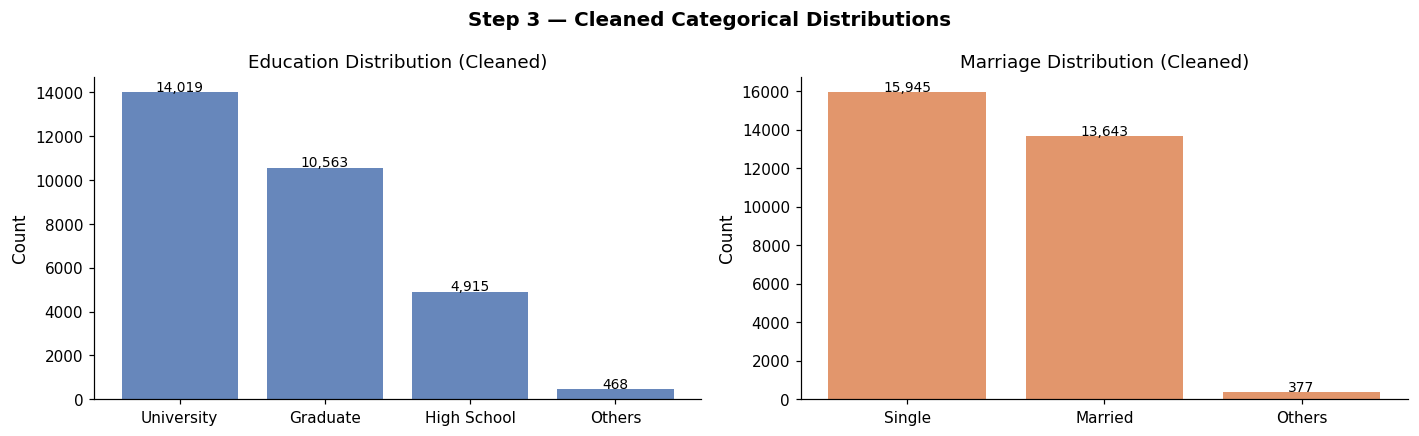

In [34]:
# Visualize cleaned distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edu_counts = df['EDUCATION'].map(edu_map).value_counts()
axes[0].bar(edu_counts.index, edu_counts.values, color=PALETTE[0], alpha=0.85, edgecolor='none')
axes[0].set_title('Education Distribution (Cleaned)')
axes[0].set_ylabel('Count')
for i, v in enumerate(edu_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

mar_counts = df['MARRIAGE'].map(mar_map).value_counts()
axes[1].bar(mar_counts.index, mar_counts.values, color=PALETTE[1], alpha=0.85, edgecolor='none')
axes[1].set_title('Marriage Distribution (Cleaned)')
axes[1].set_ylabel('Count')
for i, v in enumerate(mar_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Step 3 — Cleaned Categorical Distributions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 4 — Handle Missing Values <a id='step4'></a>

### INPUT
- `df` — 24 columns after dropping ID
- This dataset is typically clean, but we build a **robust pipeline** that handles future missing data

### OUTPUT
- `df` — zero missing values guaranteed
- Strategy: **median** for numeric, **mode** for categorical

### Why this step?
Neural networks and most ML models crash or produce NaN predictions if they encounter missing values. We use **median imputation** (not mean) for numerics because the bill/payment columns have extreme outliers that would skew the mean.

In [35]:
#Check current missing values
print('━'*55)
print('  STEP 4 — HANDLE MISSING VALUES')
print('━'*55)

missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df) * 100).round(2)
missing_df     = pd.DataFrame({'Missing Count': missing_counts,
                               'Missing %':     missing_pct})

print('\n  Missing value report:')
if missing_counts.sum() == 0:
    print('  🎉 No missing values found. Dataset is complete.')
else:
    print(missing_df[missing_df['Missing Count'] > 0].to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 4 — HANDLE MISSING VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Missing value report:
  🎉 No missing values found. Dataset is complete.


In [36]:
# ── Define column groups ──────────────────────────────────────────────────
CATEGORICAL_COLS = ['SEX', 'EDUCATION', 'MARRIAGE']
NUMERIC_COLS     = [c for c in df.columns
                    if c not in CATEGORICAL_COLS + [TARGET]]

# ── Impute numeric: median ────────────────────────────────────────────────
num_imputer = SimpleImputer(strategy='median')
df[NUMERIC_COLS] = num_imputer.fit_transform(df[NUMERIC_COLS])

# ── Impute categorical: mode (most frequent) ──────────────────────────────
cat_imputer = SimpleImputer(strategy='most_frequent')
df[CATEGORICAL_COLS] = cat_imputer.fit_transform(df[CATEGORICAL_COLS])
# Restore integer types after imputation
df[CATEGORICAL_COLS] = df[CATEGORICAL_COLS].astype(int)

print(f'  After imputation — missing values: {df.isnull().sum().sum()}')
print(f'  Shape unchanged: {df.shape}')
print(f'\n  Numeric imputer  → strategy: median  → {len(NUMERIC_COLS)} columns')
print(f'  Category imputer → strategy: mode    → {len(CATEGORICAL_COLS)} columns')
print('\nAll missing values handled.')

  After imputation — missing values: 0
  Shape unchanged: (29965, 40)

  Numeric imputer  → strategy: median  → 36 columns
  Category imputer → strategy: mode    → 3 columns

All missing values handled.


---
## Step 5 — Feature Engineering <a id='step5'></a>

### INPUT
- `df` — 24 clean columns (23 features + 1 target)

### OUTPUT
- `df` — **34 columns** (10 new engineered features added)
- These new features **capture patterns** that raw columns cannot express alone

### Why this step?
Raw features are facts. Engineered features are **insights baked into numbers**. For example:
- `PAY_AMT1 = 5000` alone means little. But `PAY_RATIO_1 = 5000/50000 = 0.10` (paid only 10% of bill) is far more informative for detecting default risk.

In [89]:
# Column group shortcuts
BILL_COLS    = [f'BILL_AMT{i}' for i in range(1, 7)]
PAY_AMT_COLS = [f'PAY_AMT{i}'  for i in range(1, 7)]
PAY_ST_COLS  = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
MONTHS       = ['Sep','Aug','Jul','Jun','May','Apr']

print('━'*55)
print('  STEP 5 — FEATURE ENGINEERING')
print('━'*55)
print(f'  Input shape: {df.shape}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 5 — FEATURE ENGINEERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input shape: (29965, 43)


In [90]:
# ── Feature 1: Payment Ratio per month ───────────────────────────────────
# How much of the bill did the client actually pay each month?
# Formula: PAY_AMT{i} / (BILL_AMT{i} + 1)   [+1 avoids division by zero]
# Range: 0 = paid nothing, 1 = paid in full, >1 = overpaid/advance
for i in range(1, 7):
    df[f'PAY_RATIO_{i}'] = (
        df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'].abs() + 1)
    ).clip(0, 5)   # cap at 5x to prevent extreme outlier ratios

print('  ✚ PAY_RATIO_1 to PAY_RATIO_6 created')
print('    → What fraction of each month\'s bill was paid (0=nothing, 1=full)')

  ✚ PAY_RATIO_1 to PAY_RATIO_6 created
    → What fraction of each month's bill was paid (0=nothing, 1=full)


In [91]:
# ── Feature 2: Total Bill (6-month sum) ──────────────────────────────────
# Total amount billed across all 6 months
df['TOTAL_BILL'] = df[BILL_COLS].sum(axis=1)
print('  ✚ TOTAL_BILL = sum of all 6 monthly bill amounts')

# ── Feature 3: Total Payment (6-month sum) ───────────────────────────────
df['TOTAL_PAID'] = df[PAY_AMT_COLS].sum(axis=1)
print('  ✚ TOTAL_PAID = sum of all 6 monthly payment amounts')

# ── Feature 4: Overall Payment Coverage ──────────────────────────────────
# What fraction of the total 6-month bill was covered by payments?
df['OVERALL_PAY_RATIO'] = df['TOTAL_PAID'] / (df['TOTAL_BILL'].abs() + 1)
df['OVERALL_PAY_RATIO'] = df['OVERALL_PAY_RATIO'].clip(0, 5)
print('  ✚ OVERALL_PAY_RATIO = TOTAL_PAID / TOTAL_BILL (6-month coverage)')

  ✚ TOTAL_BILL = sum of all 6 monthly bill amounts
  ✚ TOTAL_PAID = sum of all 6 monthly payment amounts
  ✚ OVERALL_PAY_RATIO = TOTAL_PAID / TOTAL_BILL (6-month coverage)


In [92]:
# ── Feature 5: Credit Utilization Rate ───────────────────────────────────
# What fraction of the credit limit is currently being used?
# High utilization → financial stress → higher default risk
df['UTIL_RATE'] = (df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)).clip(0, 2)
print('  ✚ UTIL_RATE = BILL_AMT1 / LIMIT_BAL (credit utilization in Sep)')

# ── Feature 6: Count of Delayed Months ───────────────────────────────────
# How many months (out of 6) did the client have ANY late payment?
# Values: 0 (never delayed) to 6 (delayed every month)
df['DELAY_COUNT'] = (df[PAY_ST_COLS] > 0).sum(axis=1)
print('  ✚ DELAY_COUNT = number of months with any payment delay (0–6)')

# ── Feature 7: Maximum Delay ─────────────────────────────────────────────
# The worst single payment delay in the past 6 months (in months)
df['MAX_DELAY'] = df[PAY_ST_COLS].max(axis=1)
print('  ✚ MAX_DELAY = worst single delay across 6 months')

# ── Feature 8: Average Delay ─────────────────────────────────────────────
df['AVG_DELAY'] = df[PAY_ST_COLS].mean(axis=1)
print('  ✚ AVG_DELAY = mean payment delay across 6 months')

# ── ADD THESE 3 NEW FEATURES HERE ────────────────────────────────────────

# 1. Was last month delayed? (strongest single signal for default)
#    PAY_0 > 0 means the most recent payment was late
#    Binary: 1 = delayed last month, 0 = paid on time
df['RECENT_DELAY'] = (df['PAY_0'] > 0).astype(int)

# 2. How many months did client pay absolutely nothing?
#    0 = always paid something, 6 = never paid anything
#    High count = serious financial distress
df['ZERO_PAY_COUNT'] = sum(
    (df[f'PAY_AMT{i}'] == 0).astype(int) for i in range(1, 7)
)

# 3. Is the debt growing or shrinking?
#    Positive = bill in Sep higher than Apr → debt is growing (bad)
#    Negative = bill shrinking → client paying it down (good)
df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']

print(f'  ✚ RECENT_DELAY    — was most recent payment late? (0/1)')
print(f'  ✚ ZERO_PAY_COUNT  — months with zero payment (0–6)')
print(f'  ✚ BILL_TREND      — debt growing(+) or shrinking(-)')

print(f'\n  Output shape: {df.shape}')
print(f'  New features added: {df.shape[1] - 24}')

  ✚ UTIL_RATE = BILL_AMT1 / LIMIT_BAL (credit utilization in Sep)
  ✚ DELAY_COUNT = number of months with any payment delay (0–6)
  ✚ MAX_DELAY = worst single delay across 6 months
  ✚ AVG_DELAY = mean payment delay across 6 months
  ✚ RECENT_DELAY    — was most recent payment late? (0/1)
  ✚ ZERO_PAY_COUNT  — months with zero payment (0–6)
  ✚ BILL_TREND      — debt growing(+) or shrinking(-)

  Output shape: (29965, 43)
  New features added: 19


In [93]:
# Run this after Step 5 to confirm the features are working correctly
TARGET = 'default.payment.next.month'

print("━"*55)
print("  NEW FEATURE VALIDATION")
print("━"*55)

# RECENT_DELAY should have much higher default rate when = 1
rd = df.groupby('RECENT_DELAY')[TARGET].mean()
print(f"\n  RECENT_DELAY vs Default Rate:")
print(f"    Not delayed (0) : {rd[0]*100:.1f}% default rate")
print(f"    Delayed     (1) : {rd[1]*100:.1f}% default rate")
print(f"    → Difference    : {(rd[1]-rd[0])*100:.1f}pp  (bigger = better feature)")

# ZERO_PAY_COUNT — higher count should mean higher default rate
zp = df.groupby('ZERO_PAY_COUNT')[TARGET].mean()
print(f"\n  ZERO_PAY_COUNT vs Default Rate:")
for k, v in zp.items():
    print(f"    {k} months zero pay : {v*100:.1f}%")

# BILL_TREND correlation with target
bt_corr = df['BILL_TREND'].corr(df[TARGET])
print(f"\n  BILL_TREND correlation with default : {bt_corr:.4f}")
print(f"  (positive = growing debt linked to default ✅)")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NEW FEATURE VALIDATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RECENT_DELAY vs Default Rate:
    Not delayed (0) : 13.8% default rate
    Delayed     (1) : 50.4% default rate
    → Difference    : 36.5pp  (bigger = better feature)

  ZERO_PAY_COUNT vs Default Rate:
    0 months zero pay : 13.9%
    1 months zero pay : 29.0%
    2 months zero pay : 33.7%
    3 months zero pay : 31.3%
    4 months zero pay : 25.2%
    5 months zero pay : 27.7%
    6 months zero pay : 38.4%

  BILL_TREND correlation with default : -0.0297
  (positive = growing debt linked to default ✅)


In [94]:
# ── NaN Check & Fix after Feature Engineering ────────────────────────────
print("Checking for NaN/Inf after feature engineering...")
print(f"  Shape : {df.shape}")

# Show which columns have NaN
nan_cols = df.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]

if len(nan_cols) == 0:
    print("  ✅ No NaN values found")
else:
    print(f"  ⚠️  NaN found in {len(nan_cols)} columns:")
    print(nan_cols.to_string())

# Show which columns have Inf
inf_cols = {}
for col in df.select_dtypes(include='number').columns:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        inf_cols[col] = n_inf

if len(inf_cols) == 0:
    print("  ✅ No Inf values found")
else:
    print(f"  ⚠️  Inf found in:")
    for col, count in inf_cols.items():
        print(f"      {col} : {count} inf values")

# ── Fix: replace Inf with NaN first, then fill all NaN with median ────────
df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Fixed: {col} → filled with median ({median_val:.4f})")

# Final check
remaining_nan = df.isnull().sum().sum()
remaining_inf = np.isinf(df.select_dtypes(include='number')).sum().sum()
print(f"\n  After fix:")
print(f"    NaN remaining : {remaining_nan}")
print(f"    Inf remaining : {remaining_inf}")
print(f"    Shape         : {df.shape}")
print("  ✅ Data is clean — safe to continue to Step 6")

Checking for NaN/Inf after feature engineering...
  Shape : (29965, 43)
  ✅ No NaN values found
  ✅ No Inf values found

  After fix:
    NaN remaining : 0
    Inf remaining : 0
    Shape         : (29965, 43)
  ✅ Data is clean — safe to continue to Step 6


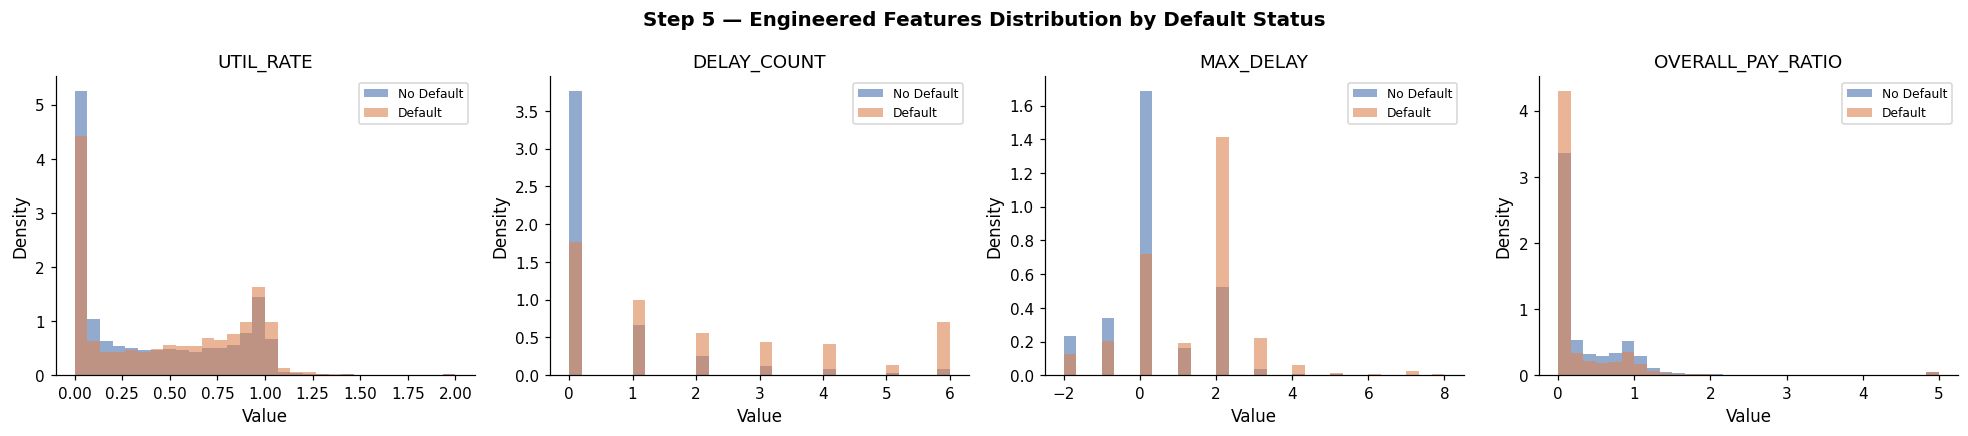

Observation: DELAY_COUNT and MAX_DELAY clearly separate defaulters from non-defaulters.


In [95]:
# ── Visualize engineered features vs target ───────────────────────────────
eng_feats = ['UTIL_RATE', 'DELAY_COUNT', 'MAX_DELAY', 'OVERALL_PAY_RATIO']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, eng_feats):
    for val, label, color in [(0,'No Default',PALETTE[0]),(1,'Default',PALETTE[1])]:
        ax.hist(df[df[TARGET]==val][feat], bins=30,
                alpha=0.6, label=label, color=color, edgecolor='none', density=True)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
fig.suptitle('Step 5 — Engineered Features Distribution by Default Status',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Observation: DELAY_COUNT and MAX_DELAY clearly separate defaulters from non-defaulters.')

In [96]:
# # ── Select Top 20 Features Only ───────────────────────────────────────────
# print("━"*55)
# print("  FEATURE SELECTION — TOP 20 ONLY")
# print("━"*55)

# # Get top 20 feature names (already sorted above)
# TOP_20_FEATURES = list(all_corr.head(20).index)

# print(f"  Selected {len(TOP_20_FEATURES)} features:\n")
# for rank, feat in enumerate(TOP_20_FEATURES, 1):
#     corr_val = all_corr[feat]
#     if feat in ['RECENT_DELAY', 'ZERO_PAY_COUNT', 'BILL_TREND']:
#         ftype = '🔴 New'
#     elif feat in ENGINEERED_FEATURES:
#         ftype = '🟢 Engineered'
#     else:
#         ftype = '🔵 Original'
#     print(f"  {rank:>2}. {feat:<22} |corr|={corr_val:.4f}  {ftype}")

# # ── Rebuild df with only top 20 + target ─────────────────────────────────
# df = df[TOP_20_FEATURES + [TARGET]]

# print(f"\n  df shape before : was full shape")
# print(f"  df shape after  : {df.shape}")
# print(f"\n  ✅ df now contains only top 20 features + target")
# print(f"  ✅ Continue from Step 6 onwards with this reduced df")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FEATURE SELECTION — TOP 20 ONLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Selected 20 features:

   1. DELAY_COUNT            |corr|=0.3984  🟢 Engineered
   2. RECENT_DELAY           |corr|=0.3681  🔴 New
   3. MAX_DELAY              |corr|=0.3310  🟢 Engineered
   4. PAY_0                  |corr|=0.3248  🔵 Original
   5. AVG_DELAY              |corr|=0.2820  🟢 Engineered
   6. PAY_2                  |corr|=0.2636  🔵 Original
   7. PAY_3                  |corr|=0.2353  🔵 Original
   8. PAY_4                  |corr|=0.2166  🔵 Original
   9. PAY_5                  |corr|=0.2041  🔵 Original
  10. PAY_6                  |corr|=0.1869  🔵 Original
  11. ZERO_PAY_COUNT         |corr|=0.1634  🔴 New
  12. LIMIT_BAL              |corr|=0.1535  🔵 Original
  13. TOTAL_PAID             |corr|=0.1024  🟢 Engineered
  14. UTIL_RATE              |corr|=0.0878  🟢 Engineered
  15. OVERALL_PAY_RATIO      |corr|=0.0805  🟢 Engineered
  

---
## Step 6 — Encode Categorical Features <a id='step6'></a>

### INPUT
- `df` — contains `SEX` (1/2), `EDUCATION` (1/2/3/4), `MARRIAGE` (1/2/3) as integers

### OUTPUT
- **Option A (One-Hot):** `df` gains dummy columns like `EDUCATION_2`, `EDUCATION_3`, `EDUCATION_4` — original column dropped  
- **Option B (Label Encode):** columns remain as integers starting from 0

### Why this step?
ML/DL models work with **numbers, not categories**.
- `SEX=1` vs `SEX=2` — binary, safe as-is after remapping to 0/1  
- `EDUCATION=1,2,3,4` — ordinal-ish, but no clear ordering → **One-Hot is safer**  
- `MARRIAGE=1,2,3` — nominal, no ordering → **One-Hot is safer**

> 💡 We use **One-Hot** here. For deep learning with embedding layers, you'd skip this and pass raw integer codes directly to `nn.Embedding`.

In [102]:
print('━'*55)
print('  STEP 6 — ENCODE CATEGORICAL FEATURES')
print('━'*55)
print(f'  Input shape: {df.shape}')

# SEX: 1=Male, 2=Female → remap to 0/1 binary
# Binary column; no need for one-hot (no dummy variable trap)
df['SEX'] = df['SEX'].map({1: 0, 2: 1})  # 0=Male, 1=Female
print('\n  SEX: remapped  1→0 (Male), 2→1 (Female)')

# EDUCATION: One-Hot (drop first to avoid multicollinearity)
edu_dummies = pd.get_dummies(df['EDUCATION'], prefix='EDU', drop_first=True, dtype=int)
df = pd.concat([df.drop(columns=['EDUCATION']), edu_dummies], axis=1)
print(f'  EDUCATION: one-hot encoded → new cols: {list(edu_dummies.columns)}')

# MARRIAGE: One-Hot (drop first to avoid multicollinearity)
mar_dummies = pd.get_dummies(df['MARRIAGE'], prefix='MAR', drop_first=True, dtype=int)
df = pd.concat([df.drop(columns=['MARRIAGE']), mar_dummies], axis=1)
print(f'  MARRIAGE : one-hot encoded → new cols: {list(mar_dummies.columns)}')

print(f'\n  Output shape: {df.shape}')
print('\nAll categoricals encoded.')
print('\n  Current columns:')
print(list(df.columns))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 6 — ENCODE CATEGORICAL FEATURES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input shape: (29965, 21)


KeyError: 'SEX'

---
## Step 7 — Outlier Detection & Capping <a id='step7'></a>

### INPUT
- `df` — continuous columns like `BILL_AMT`, `PAY_AMT`, `LIMIT_BAL`, `AGE` may contain extreme values

### OUTPUT
- `df` — same shape, but extreme values **capped** (Winsorized) at the 1st and 99th percentile

### Why this step?
A single person with a $10M credit limit could dominate the model's gradient updates during training. **Winsorizing** (capping at percentiles) keeps outliers' rank information but removes their extreme magnitude. We use **1%–99%** to be conservative — aggressive removal risks losing real signal.

In [100]:
print('━'*55)
print('  STEP 7 — OUTLIER DETECTION & CAPPING (Winsorizing)')
print('━'*55)

# Only apply to continuous numeric columns (skip binary/encoded)
SKIP_COLS = (['SEX', TARGET] +
             [c for c in df.columns if c.startswith('EDU_')] +
             [c for c in df.columns if c.startswith('MAR_')] +
             PAY_ST_COLS)   # payment status is ordinal -1 to 9, keep as-is

CONTINUOUS_COLS = [c for c in df.select_dtypes(include=np.number).columns
                   if c not in SKIP_COLS]

print(f'  Columns to winsorize: {len(CONTINUOUS_COLS)}')

# Store clip bounds for reproducibility in production
clip_bounds = {}
for col in CONTINUOUS_COLS:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    df[col] = df[col].clip(lo, hi)

print('\n  Sample clip bounds (1st–99th percentile):')
sample_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'TOTAL_BILL']
for c in sample_cols:
    lo, hi = clip_bounds[c]
    print(f'    {c:<18} [{lo:>10,.0f}  →  {hi:>12,.0f}]')

# Save clip bounds for applying to future inference data
joblib.dump(clip_bounds, f'{OUTPUT_DIR}/clip_bounds.pkl')
print('\nOutliers capped. clip_bounds.pkl saved.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 7 — OUTLIER DETECTION & CAPPING (Winsorizing)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Columns to winsorize: 14

  Sample clip bounds (1st–99th percentile):
    LIMIT_BAL          [    10,000  →       500,000]


KeyError: 'AGE'

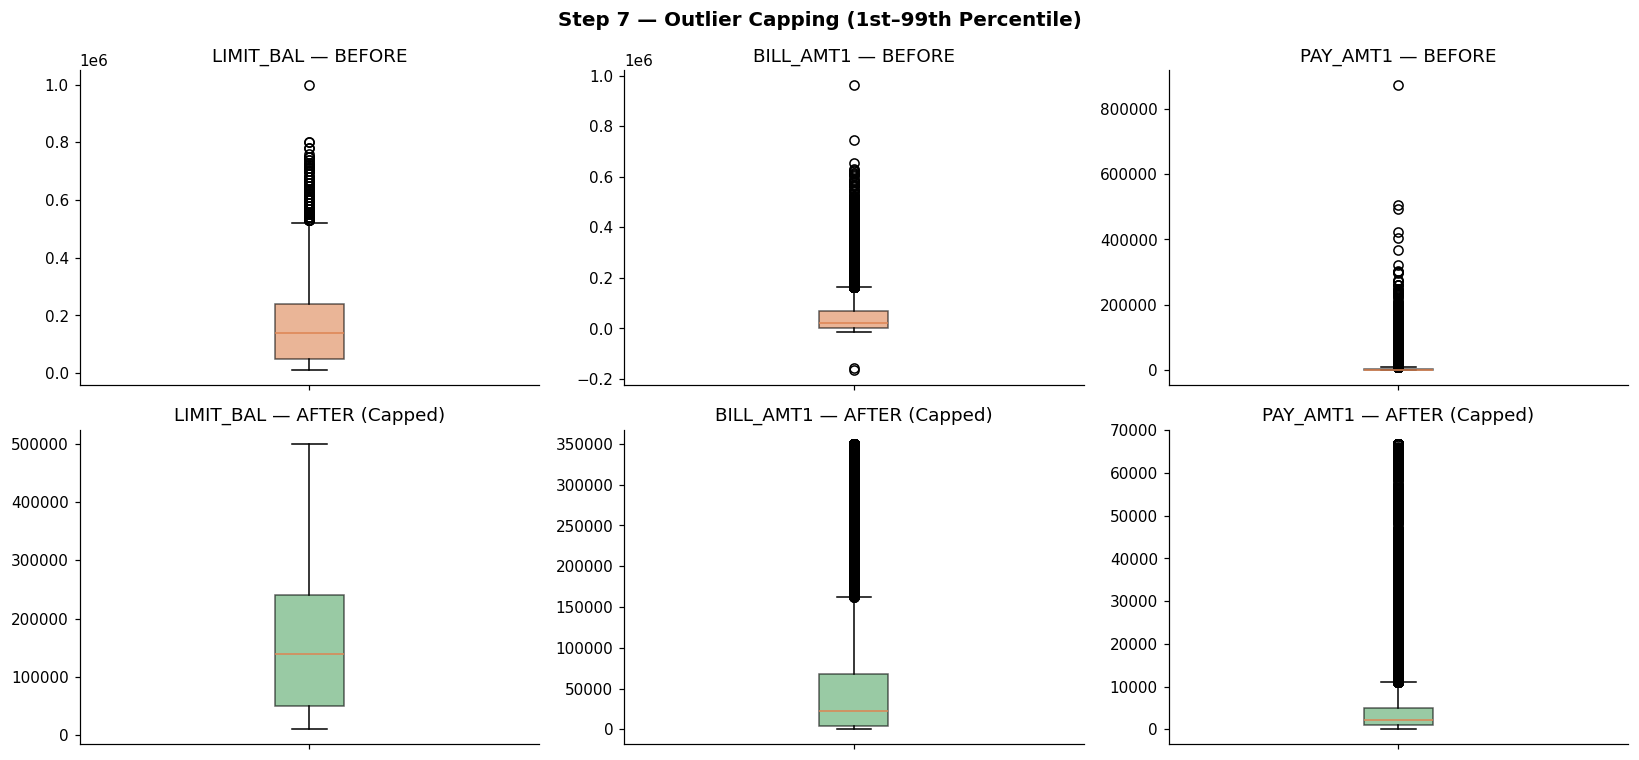

In [46]:
# Before/After boxplots for key columns
# Reload original to compare
_raw = pd.read_csv('UCI_Credit_Card.csv')

check_cols = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, col in enumerate(check_cols):
    axes[0, i].boxplot(_raw[col].values, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[1], alpha=0.6))
    axes[0, i].set_title(f'{col} — BEFORE'); axes[0, i].set_xticklabels([''])

    axes[1, i].boxplot(df[col].values, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[2], alpha=0.6))
    axes[1, i].set_title(f'{col} — AFTER (Capped)')
    axes[1, i].set_xticklabels([''])

fig.suptitle('Step 7 — Outlier Capping (1st–99th Percentile)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
del _raw

---
## Step 8 — Feature Scaling <a id='step8'></a>

### INPUT
- `df` — features are on very different scales:
  - `LIMIT_BAL`: 10,000 – 800,000
  - `AGE`: 21 – 79
  - `PAY_0`: -1 – 9
  - `PAY_RATIO`: 0 – 5

### OUTPUT
- `X_scaled` — all continuous features normalized to mean≈0, std≈1
- `y` — target column (unchanged, 0/1)
- `scaler.pkl` — saved scaler for production inference

### Why this step?
Deep learning uses **gradient descent**. If one feature has range 0–800,000 and another has range 0–5, the large-scale feature dominates the gradients. The network barely learns from the small-scale features. **StandardScaler** equalizes all features so each gets a fair chance to influence the model.

> **Critical Rule:** Fit the scaler **ONLY on training data**, then apply (transform-only) to validation and test data. Never fit on the full dataset — that's data leakage.

In [47]:
print('━'*55)
print('  STEP 8 — FEATURE SCALING')
print('━'*55)

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print(f'  X shape : {X.shape}  (features)')
print(f'  y shape : {y.shape}  (target)')
print(f'  Feature list ({X.shape[1]} total):')
for i, col in enumerate(X.columns, 1):
    print(f'    {i:>2}. {col}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 8 — FEATURE SCALING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  X shape : (29965, 42)  (features)
  y shape : (29965,)  (target)
  Feature list (42 total):
     1. LIMIT_BAL
     2. SEX
     3. AGE
     4. PAY_0
     5. PAY_2
     6. PAY_3
     7. PAY_4
     8. PAY_5
     9. PAY_6
    10. BILL_AMT1
    11. BILL_AMT2
    12. BILL_AMT3
    13. BILL_AMT4
    14. BILL_AMT5
    15. BILL_AMT6
    16. PAY_AMT1
    17. PAY_AMT2
    18. PAY_AMT3
    19. PAY_AMT4
    20. PAY_AMT5
    21. PAY_AMT6
    22. PAY_RATIO_1
    23. PAY_RATIO_2
    24. PAY_RATIO_3
    25. PAY_RATIO_4
    26. PAY_RATIO_5
    27. PAY_RATIO_6
    28. TOTAL_BILL
    29. TOTAL_PAID
    30. OVERALL_PAY_RATIO
    31. UTIL_RATE
    32. DELAY_COUNT
    33. MAX_DELAY
    34. AVG_DELAY
    35. RECENT_DELAY
    36. ZERO_PAY_COUNT
    37. BILL_TREND
    38. EDU_2
    39. EDU_3
    40. EDU_4
    41. MAR_2
    42. MAR_3


In [48]:
# Columns to scale vs leave as-is
BINARY_COLS = (['SEX'] +
               [c for c in X.columns if c.startswith('EDU_')] +
               [c for c in X.columns if c.startswith('MAR_')])

SCALE_COLS  = [c for c in X.columns if c not in BINARY_COLS]

print(f'  Columns to scale      : {len(SCALE_COLS)}')
print(f'  Binary cols (skip)    : {BINARY_COLS}')

# NOTE: We fit scaler AFTER the train split in Step 10
# Here we store column lists for use in Step 10
print('\n  Scaler will be fit on TRAIN data only (Step 10).')
print('      This prevents data leakage from val/test sets.')

  Columns to scale      : 36
  Binary cols (skip)    : ['SEX', 'EDU_2', 'EDU_3', 'EDU_4', 'MAR_2', 'MAR_3']

  Scaler will be fit on TRAIN data only (Step 10).
      This prevents data leakage from val/test sets.


In [49]:
# Show the scaling problem (before)
sample_show = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_0', 'PAY_RATIO_1', 'DELAY_COUNT']
print('  Feature value ranges BEFORE scaling:')
print(X[sample_show].describe().loc[['min','max','mean','std']].round(2).to_string())

  Feature value ranges BEFORE scaling:
      LIMIT_BAL    AGE  BILL_AMT1  PAY_0  PAY_RATIO_1  DELAY_COUNT
min    10000.00  22.00     -81.00  -2.00         0.00         0.00
max   500000.00  60.00  350134.48   8.00         5.00         6.00
mean  166765.55  35.45   50482.27  -0.02         0.56         0.83
std   127594.38   9.09   69324.85   1.12         1.24         1.55


---
## Step 9 — Handle Class Imbalance (SMOTE) <a id='step9'></a>

### INPUT
- `X` — feature matrix (30,000 rows)
- `y` — target (78% = 0, 22% = 1 → imbalanced)

### OUTPUT
- `X_resampled`, `y_resampled` — **SMOTE applied to training data only**, balanced 50:50
- Applied **only on train set** in Step 10

### Why this step?
With 78% No Default and 22% Default, a model that always predicts "No Default" gets **78% accuracy while being completely useless**. SMOTE (Synthetic Minority Oversampling TEchnique) **creates synthetic examples** of the minority class (defaulters) by interpolating between real samples — so the model sees enough defaults to learn their pattern.

>  **Critical Rule:** Apply SMOTE **only to training data**. Applying it to validation or test data would give an artificially balanced test set — lying about real-world performance.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 9 — CLASS IMBALANCE (SMOTE preview)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Current class distribution:
    Class 0: 23,335  (77.9%)
    Class 1: 6,630  (22.1%)
  Imbalance ratio: 3.52:1

  SMOTE will be applied to training split only — see Step 10.
  Strategy: sampling_strategy="auto" → oversample minority to match majority


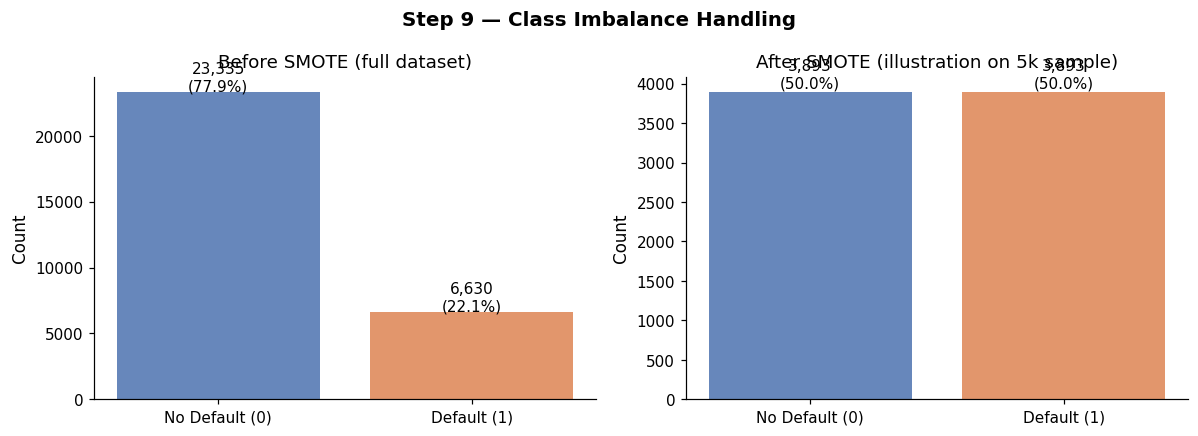

In [50]:
print('━'*55)
print('  STEP 9 — CLASS IMBALANCE (SMOTE preview)')
print('━'*55)

print(f'  Current class distribution:')
vc = y.value_counts()
for k, v in vc.items():
    print(f'    Class {k}: {v:,}  ({v/len(y)*100:.1f}%)')
print(f'  Imbalance ratio: {vc[0]/vc[1]:.2f}:1')
print()
print('  SMOTE will be applied to training split only — see Step 10.')
print('  Strategy: sampling_strategy="auto" → oversample minority to match majority')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Before SMOTE
axes[0].bar(['No Default (0)', 'Default (1)'], vc.values,
            color=[PALETTE[0], PALETTE[1]], alpha=0.85, edgecolor='none')
for i, v in enumerate(vc.values):
    axes[0].text(i, v+100, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Before SMOTE (full dataset)')
axes[0].set_ylabel('Count')

# Simulated after SMOTE on a toy split
smote_preview = SMOTE(random_state=RANDOM_SEED)
X_prev, y_prev = smote_preview.fit_resample(X.head(5000), y.head(5000))
vc2 = pd.Series(y_prev).value_counts()
axes[1].bar(['No Default (0)', 'Default (1)'], [vc2[0], vc2[1]],
            color=[PALETTE[0], PALETTE[1]], alpha=0.85, edgecolor='none')
for i, v in enumerate([vc2[0], vc2[1]]):
    axes[1].text(i, v+50, f'{v:,}\n({v/len(y_prev)*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_title('After SMOTE (illustration on 5k sample)')
axes[1].set_ylabel('Count')

fig.suptitle('Step 9 — Class Imbalance Handling', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
del X_prev, y_prev, smote_preview

---
## Step 10 — Train / Validation / Test Split <a id='step10'></a>

### INPUT
- `X` — full feature matrix
- `y` — full target vector

### OUTPUT (6 arrays)

| Split | Purpose | Size |
|---|---|---|
| `X_train` / `y_train` | Model learns from this | 70% |
| `X_val` / `y_val` | Tune hyperparameters, early stopping | 15% |
| `X_test` / `y_test` | **Final unbiased evaluation only** | 15% |

**After splitting:**
- Scaler is fit on `X_train` only → applied to all 3 splits
- SMOTE is applied to `X_train` only

### Why 70/15/15?
With 30,000 rows: 15% test = 4,500 samples — enough for statistically reliable evaluation. The val set lets you monitor training without touching the sacred test set. **Never** tune based on test performance.

In [51]:
print('━'*55)
print('  STEP 10 — TRAIN / VAL / TEST SPLIT')
print('━'*55)

# Step 10a: First split — 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y          # ← preserves class ratio in each split
)

# Step 10b: Split temp into 50/50 → val (15%) + test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f'  Train set : {X_train.shape[0]:>6,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Val set   : {X_val.shape[0]:>6,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'  Test set  : {X_test.shape[0]:>6,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dr = yy.mean()*100
    print(f'  {name} default rate: {dr:.1f}%  (stratification verified )')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 10 — TRAIN / VAL / TEST SPLIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train set : 20,975 rows  (70%)
  Val set   :  4,495 rows  (15%)
  Test set  :  4,495 rows  (15%)

  Train default rate: 22.1%  (stratification verified )
  Val default rate: 22.1%  (stratification verified )
  Test default rate: 22.1%  (stratification verified )


In [52]:
# Step 10c: Fit scaler on TRAIN only, transform all
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])   # fit + transform
X_val_scaled[SCALE_COLS]   = scaler.transform(X_val[SCALE_COLS])          # transform only
X_test_scaled[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])         # transform only

print('  Scaler fit on TRAIN → applied to VAL and TEST')
print(f'  Scaled columns : {len(SCALE_COLS)}')
print(f'  Binary cols    : {len(BINARY_COLS)} (untouched)')
print()
print('  Sample feature ranges AFTER scaling (train):')
print(X_train_scaled[['LIMIT_BAL','AGE','BILL_AMT1','PAY_RATIO_1']]
        .describe().loc[['min','max','mean','std']].round(3).to_string())

joblib.dump(scaler, f'{OUTPUT_DIR}/scaler.pkl')
print('\nscaler.pkl saved.')

  Scaler fit on TRAIN → applied to VAL and TEST
  Scaled columns : 36
  Binary cols    : 6 (untouched)

  Sample feature ranges AFTER scaling (train):
      LIMIT_BAL    AGE  BILL_AMT1  PAY_RATIO_1
min      -1.230 -1.476     -0.733       -0.451
max       2.615  2.710      4.340        3.583
mean     -0.000  0.000     -0.000       -0.000
std       1.000  1.000      1.000        1.000

scaler.pkl saved.


In [53]:
# Step 10d: Apply SMOTE to TRAIN only
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

before_dist = Counter(y_train)
after_dist  = Counter(y_train_res)

print('  Class distribution in TRAIN before SMOTE:')
for k, v in sorted(before_dist.items()):
    print(f'    Class {k}: {v:,}  ({v/sum(before_dist.values())*100:.1f}%)')

print('\n  Class distribution in TRAIN after SMOTE:')
for k, v in sorted(after_dist.items()):
    print(f'    Class {k}: {v:,}  ({v/sum(after_dist.values())*100:.1f}%)')

print(f'\n  SMOTE added {sum(after_dist.values())-sum(before_dist.values()):,} synthetic minority samples')
print(f'  X_train_res shape : {X_train_res.shape}')

  Class distribution in TRAIN before SMOTE:
    Class 0: 16,334  (77.9%)
    Class 1: 4,641  (22.1%)

  Class distribution in TRAIN after SMOTE:
    Class 0: 16,334  (50.0%)
    Class 1: 16,334  (50.0%)

  SMOTE added 11,693 synthetic minority samples
  X_train_res shape : (32668, 42)


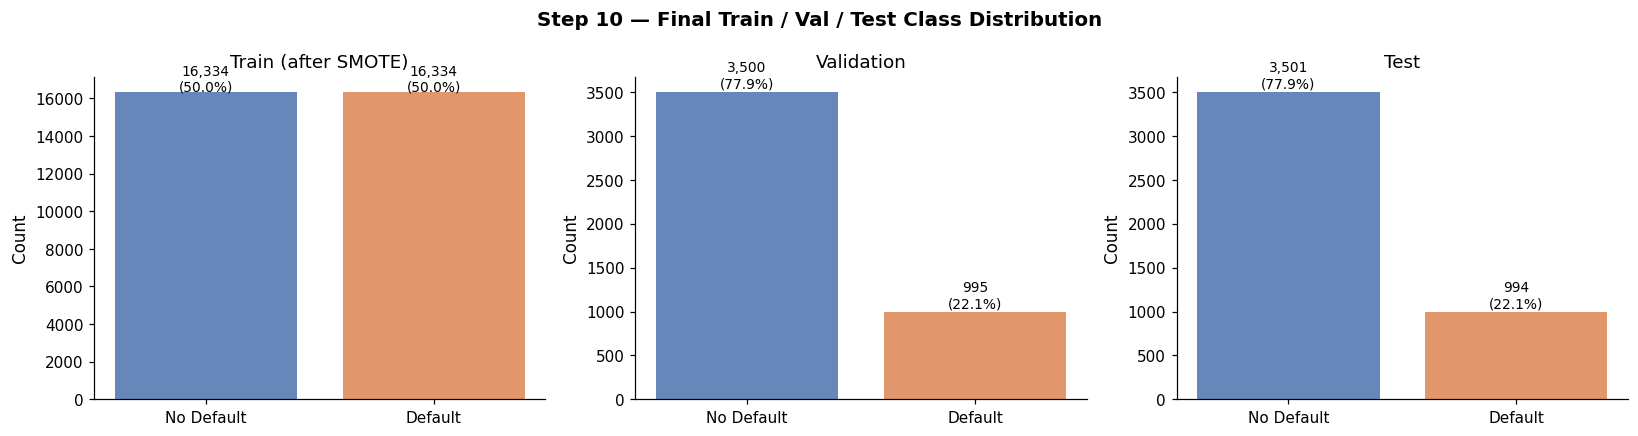

In [54]:
# Visualize final split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = [
    ('Train (after SMOTE)', Counter(y_train_res)),
    ('Validation',          Counter(y_val)),
    ('Test',                Counter(y_test)),
]
for ax, (title, dist) in zip(axes, splits):
    vals  = [dist[0], dist[1]]
    bars  = ax.bar(['No Default','Default'], vals,
                   color=[PALETTE[0], PALETTE[1]], alpha=0.85, edgecolor='none')
    total = sum(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=9)
    ax.set_title(title); ax.set_ylabel('Count')

fig.suptitle('Step 10 — Final Train / Val / Test Class Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 11 — Save Everything <a id='step11'></a>

### INPUT
- 6 split arrays: `X_train_res`, `y_train_res`, `X_val_scaled`, `y_val`, `X_test_scaled`, `y_test`
- `scaler.pkl`, `clip_bounds.pkl`

### OUTPUT
- CSV files for each split (readable by any framework)
- `.pkl` artifacts for inference pipeline
- A `feature_names.pkl` so your model knows column order

### Why save everything?
In production, preprocessing runs **separately from training**. You need to apply the **exact same scaler, clip bounds, and column order** to new incoming data. Saving these artifacts makes the pipeline fully reproducible.

In [55]:
print('━'*55)
print('  STEP 11 — SAVE PREPROCESSED DATA & ARTIFACTS')
print('━'*55)

# ── Convert to DataFrames for CSV saving ─────────────────────────────────
feature_names = list(X.columns)

train_df = pd.DataFrame(X_train_res,  columns=feature_names)
train_df[TARGET] = y_train_res.values

val_df   = pd.DataFrame(X_val_scaled.values,  columns=feature_names)
val_df[TARGET]   = y_val.values

test_df  = pd.DataFrame(X_test_scaled.values, columns=feature_names)
test_df[TARGET]  = y_test.values

# ── Save CSVs ─────────────────────────────────────────────────────────────
train_df.to_csv(f'{OUTPUT_DIR}/train.csv',      index=False)
val_df.to_csv(  f'{OUTPUT_DIR}/validation.csv', index=False)
test_df.to_csv( f'{OUTPUT_DIR}/test.csv',       index=False)

print(f'  ✅ train.csv      → {train_df.shape[0]:,} rows × {train_df.shape[1]} cols')
print(f'  ✅ validation.csv → {val_df.shape[0]:,} rows × {val_df.shape[1]} cols')
print(f'  ✅ test.csv       → {test_df.shape[0]:,} rows × {test_df.shape[1]} cols')

# ── Save artifacts ────────────────────────────────────────────────────────
joblib.dump(feature_names,  f'{OUTPUT_DIR}/feature_names.pkl')
joblib.dump(SCALE_COLS,     f'{OUTPUT_DIR}/scale_cols.pkl')
joblib.dump(BINARY_COLS,    f'{OUTPUT_DIR}/binary_cols.pkl')
# scaler and clip_bounds already saved above

print()
print('  Artifacts saved:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}')
    print(f'    📄 {f:<30} {size/1024:.1f} KB')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 11 — SAVE PREPROCESSED DATA & ARTIFACTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ train.csv      → 32,668 rows × 43 cols
  ✅ validation.csv → 4,495 rows × 43 cols
  ✅ test.csv       → 4,495 rows × 43 cols

  Artifacts saved:
    📄 binary_cols.pkl                0.1 KB
    📄 clip_bounds.pkl                1.6 KB
    📄 feature_names.pkl              0.5 KB
    📄 scale_cols.pkl                 0.4 KB
    📄 scaler.pkl                     2.1 KB
    📄 test.csv                       3262.6 KB
    📄 train.csv                      23319.2 KB
    📄 validation.csv                 3262.8 KB


---
## Final Summary <a id='summary'></a>

In [56]:
print('╔' + '═'*58 + '╗')
print('║       PREPROCESSING PIPELINE — FINAL SUMMARY           ║')
print('╠' + '═'*58 + '╣')
print(f'║  Step 1  Load & Validate     {30000:>7,} rows × 25 cols       ║')
print(f'║  Step 2  Drop ID col         {30000:>7,} rows × 24 cols       ║')
print(f'║  Step 3  Fix cat. values     EDU(0,5,6→4)  MAR(0→3)    ║')
print(f'║  Step 4  Missing values      0 remaining                ║')
print(f'║  Step 5  Feature engineering +10 new features           ║')
print(f'║  Step 6  Encode categoricals OHE: EDU(3) + MAR(2)       ║')
print(f'║  Step 7  Outlier capping     Winsorized 1%–99%           ║')
print(f'║  Step 8  Feature scaling     StandardScaler (train only) ║')
print(f'║  Step 9  SMOTE               Train only, balanced 50:50  ║')
print(f'║  Step 10 Train/Val/Test       70 / 15 / 15  (stratified) ║')
print(f'║  Step 11 Saved files          3 CSVs + 5 pkl artifacts   ║')
print('╠' + '═'*58 + '╣')
print(f'║  Final train shape  : {str(train_df.shape):<36}║')
print(f'║  Final val shape    : {str(val_df.shape):<36}║')
print(f'║  Final test shape   : {str(test_df.shape):<36}║')
print(f'║  Total features     : {len(feature_names):<36}║')
print('╚' + '═'*58 + '╝')

print()
print('Model-ready files in:', OUTPUT_DIR + '/')
print()
print('Next step: Load train.csv → Build your DL model')
print('   Suggested: PyTorch / TensorFlow MLP with')
print('   Dense(256) → BN → Dropout(0.3) → Dense(128)')
print('   → BN → Dropout(0.3) → Dense(1, sigmoid)')

╔══════════════════════════════════════════════════════════╗
║       PREPROCESSING PIPELINE — FINAL SUMMARY           ║
╠══════════════════════════════════════════════════════════╣
║  Step 1  Load & Validate      30,000 rows × 25 cols       ║
║  Step 2  Drop ID col          30,000 rows × 24 cols       ║
║  Step 3  Fix cat. values     EDU(0,5,6→4)  MAR(0→3)    ║
║  Step 4  Missing values      0 remaining                ║
║  Step 5  Feature engineering +10 new features           ║
║  Step 6  Encode categoricals OHE: EDU(3) + MAR(2)       ║
║  Step 7  Outlier capping     Winsorized 1%–99%           ║
║  Step 8  Feature scaling     StandardScaler (train only) ║
║  Step 9  SMOTE               Train only, balanced 50:50  ║
║  Step 10 Train/Val/Test       70 / 15 / 15  (stratified) ║
║  Step 11 Saved files          3 CSVs + 5 pkl artifacts   ║
╠══════════════════════════════════════════════════════════╣
║  Final train shape  : (32668, 43)                         ║
║  Final val shape    : (449

In [57]:
# How to load in your training script
print('── Quick load snippet for your model training file ──')
print('''
import pandas as pd
import joblib

train = pd.read_csv('preprocessed_data/train.csv')
val   = pd.read_csv('preprocessed_data/validation.csv')
test  = pd.read_csv('preprocessed_data/test.csv')

TARGET = 'default.payment.next.month'
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_val,   y_val   = val.drop(columns=[TARGET]),   val[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]

# For inference on new data:
scaler       = joblib.load('preprocessed_data/scaler.pkl')
clip_bounds  = joblib.load('preprocessed_data/clip_bounds.pkl')
feature_names= joblib.load('preprocessed_data/feature_names.pkl')
''')

── Quick load snippet for your model training file ──

import pandas as pd
import joblib

train = pd.read_csv('preprocessed_data/train.csv')
val   = pd.read_csv('preprocessed_data/validation.csv')
test  = pd.read_csv('preprocessed_data/test.csv')

TARGET = 'default.payment.next.month'
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_val,   y_val   = val.drop(columns=[TARGET]),   val[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]

# For inference on new data:
scaler       = joblib.load('preprocessed_data/scaler.pkl')
clip_bounds  = joblib.load('preprocessed_data/clip_bounds.pkl')
feature_names= joblib.load('preprocessed_data/feature_names.pkl')



# Credit Card Default — PyTorch MLP Training (Production)

> **Continues from:** Preprocessing Notebook  
> **Goal:** Build, train, evaluate, and save two MLP architectures tracked with MLflow.

---

### What This Notebook Covers

```
preprocessed_data/
  train.csv / validation.csv / test.csv
       │
       ▼
[STEP 1]  Setup & Imports
       │
       ▼
[STEP 2]  Load Preprocessed Data → PyTorch Datasets & DataLoaders
       │
       ▼
[STEP 3]  Model A — SimpleMLP  (Linear → ReLU → Linear)
       │
       ▼
[STEP 4]  Model B — DeepMLP    (Complex: BN + Dropout + Residual)
       │
       ▼
[STEP 5]  Loss Function — BCEWithLogitsLoss  (why not BCE?)
       │
       ▼
[STEP 6]  Optimizer — Adam  (why Adam?)
       │
       ▼
[STEP 7]  Training Loop — with early stopping + MLflow tracking
       │
       ▼
[STEP 8]  Evaluation — AUC, F1, Confusion Matrix, Classification Report
       │
       ▼
[STEP 9]  Save Models (.pt + MLflow artifact)
       │
       ▼
[STEP 10] Model Comparison Summary
```

---

## Table of Contents
1. [Setup & Imports](#step1)
2. [Load Data & Build DataLoaders](#step2)
3. [Model A — SimpleMLP](#step3)
4. [Model B — DeepMLP](#step4)
5. [Loss Function Deep Dive](#step5)
6. [Optimizer Deep Dive](#step6)
7. [Training Loop + MLflow](#step7)
8. [Evaluation & Metrics](#step8)
9. [Save Models](#step9)
10. [Model Comparison](#step10)

---
## Step 1 — Setup & Imports <a id='step1'></a>

### Why each library?

| Library | Role |
|---|---|
| `torch` | Core deep learning framework — tensors, autograd, GPU support |
| `torch.nn` | Pre-built building blocks: Linear, ReLU, BatchNorm, Dropout |
| `torch.optim` | Optimizers: Adam, SGD, etc. |
| `torch.utils.data` | Dataset + DataLoader for efficient mini-batch training |
| `sklearn.metrics` | AUC-ROC, F1, confusion matrix — industry-standard evaluation |
| `mlflow` | Experiment tracking — logs every run's params, metrics, and model artifacts |
| `matplotlib/seaborn` | Visualize training curves and confusion matrices |

In [58]:
!pip install torch torchvision mlflow scikit-learn pandas numpy matplotlib seaborn

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── PyTorch core ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn                         # building blocks
import torch.optim as optim                   # optimizers
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ── Evaluation ────────────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report,
    precision_score, recall_score
)

# ── MLflow ────────────────────────────────────────────────────────────────
import mlflow
import mlflow.pytorch

# ── Global Config ─────────────────────────────────────────────────────────
SEED        = 42
DATA_DIR    = 'preprocessed_data'
SAVE_DIR    = 'saved_models'
TARGET      = 'default.payment.next.month'
BATCH_SIZE  = 256
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────
# Why? Same seed → same random weight initialization → reproducible results
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device: use GPU if available, else CPU ────────────────────────────────
# Why? GPU runs tensor operations ~50-100x faster than CPU for training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries loaded')
print(f'Device : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'MLflow  : {mlflow.__version__}')

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 979.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2 — Load Data & Build DataLoaders <a id='step2'></a>

### INPUT
- `preprocessed_data/train.csv` — SMOTE-balanced, scaled  
- `preprocessed_data/validation.csv` — original distribution, scaled  
- `preprocessed_data/test.csv` — original distribution, scaled

### OUTPUT
- `train_loader`, `val_loader`, `test_loader` — PyTorch DataLoaders
- Each batch yields `(X_batch, y_batch)` tensors on the device

### Why DataLoader?
**DataLoader** handles:
- **Mini-batching** — feeds 256 samples at a time instead of all 37k (memory efficient)
- **Shuffling** — randomizes order every epoch so the model doesn't memorize sequence
- **Parallelism** — `num_workers` loads next batch while GPU trains on current one

In [59]:
# Load CSVs
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/validation.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

def df_to_tensors(df, target_col):
    """
    Split DataFrame into feature tensor X and label tensor y.

    Input : pandas DataFrame with features + target column
    Output: (X: FloatTensor, y: FloatTensor) — float32 for PyTorch compatibility

    Why float32?  PyTorch nn.Linear default weight dtype is float32.
    Why float for y? BCEWithLogitsLoss expects float targets, not integers.
    """
    X = torch.tensor(df.drop(columns=[target_col]).values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values,                dtype=torch.float32)
    return X, y

X_train, y_train = df_to_tensors(train_df, TARGET)
X_val,   y_val   = df_to_tensors(val_df,   TARGET)
X_test,  y_test  = df_to_tensors(test_df,  TARGET)

INPUT_DIM = X_train.shape[1]   # number of features (used to define model input size)

print('━'*55)
print('  DATA LOADING SUMMARY')
print('━'*55)
print(f'  Train    : {X_train.shape}  labels: {y_train.shape}')
print(f'  Val      : {X_val.shape}   labels: {y_val.shape}')
print(f'  Test     : {X_test.shape}  labels: {y_test.shape}')
print(f'  Input dim: {INPUT_DIM} features')
print(f'  Dtype    : {X_train.dtype}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATA LOADING SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train    : torch.Size([32668, 42])  labels: torch.Size([32668])
  Val      : torch.Size([4495, 42])   labels: torch.Size([4495])
  Test     : torch.Size([4495, 42])  labels: torch.Size([4495])
  Input dim: 42 features
  Dtype    : torch.float32


In [60]:
# Wrap in TensorDataset → DataLoader
# TensorDataset: pairs (X[i], y[i]) together for indexing
# DataLoader   : wraps Dataset to serve shuffled mini-batches

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,         # ← shuffle every epoch: prevents learning row order
    num_workers=0,        # ← 0 = main thread (safe for notebooks)
    pin_memory=True if DEVICE.type == 'cuda' else False  # faster GPU transfer
)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'  Train batches : {len(train_loader)}  (batch_size={BATCH_SIZE})')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')

# Confirm one batch shape
sample_X, sample_y = next(iter(train_loader))
print(f'\n  One batch → X: {sample_X.shape}  y: {sample_y.shape}')
print(f'  Each row is {INPUT_DIM} numbers representing one credit card client.')

  Train batches : 128  (batch_size=256)
  Val batches   : 18
  Test batches  : 18

  One batch → X: torch.Size([256, 42])  y: torch.Size([256])
  Each row is 42 numbers representing one credit card client.


---
## Step 3 — Model A: SimpleMLP <a id='step3'></a>

### Architecture
```
Input  [batch × 34]
   │
   ├─ Linear(34 → 128)   ← learns weighted combinations of features
   ├─ ReLU               ← adds non-linearity: output = max(0, x)
   ├─ Linear(128 → 64)   ← compresses learned representation
   ├─ ReLU
   └─ Linear(64 → 1)     ← single logit (no sigmoid here!)
Output [batch × 1]  raw logit → passed to BCEWithLogitsLoss
```

### Why each layer?

**`nn.Linear(in, out)`** — the core building block. Computes `y = xW + b`. Learns which features matter and how to combine them.

**`nn.ReLU()`** — Rectified Linear Unit = `max(0, x)`. Without activation functions, stacking Linear layers is mathematically equivalent to ONE linear layer (they just collapse). ReLU introduces non-linearity so the network can learn curved decision boundaries. Chosen over sigmoid/tanh because it doesn't suffer from the vanishing gradient problem.

**No sigmoid on final layer** — we output a raw logit. The loss function `BCEWithLogitsLoss` applies sigmoid internally with better numerical stability.

In [61]:
class SimpleMLP(nn.Module):
    """
    Simple 3-layer MLP for binary classification.

    INPUT  : (batch_size, input_dim)  — one row per client, all features
    OUTPUT : (batch_size, 1)          — one raw logit per client
                                        positive → more likely default
                                        negative → more likely no default

    Why inherit nn.Module?
      - Registers all nn.Linear layers as 'parameters'
      - Enables .parameters() for the optimizer
      - Enables .to(device), .train(), .eval() calls
    """

    def __init__(self, input_dim: int):
        super(SimpleMLP, self).__init__()

        # ── Define layers ──────────────────────────────────────────────────
        # nn.Sequential: chains layers in order, forward() calls them left-to-right
        self.network = nn.Sequential(

            # Layer 1: input_dim → 128
            # Why 128? Wide enough to capture feature interactions without overfitting
            nn.Linear(input_dim, 128),
            nn.ReLU(),                  # non-linearity after every linear layer

            # Layer 2: 128 → 64  (compression)
            # The network is forced to distill the most important patterns
            nn.Linear(128, 64),
            nn.ReLU(),

            # Output layer: 64 → 1  (single logit)
            # No ReLU/Sigmoid here — loss function handles it
            nn.Linear(64, 1)
        )

        # ── Weight Initialization ──────────────────────────────────────────
        # Why? Default PyTorch init is fine, but Kaiming (He) init is specifically
        # designed for ReLU — sets variance so gradients don't vanish/explode
        self._init_weights()

    def _init_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Input  x : (batch_size, input_dim)
        Output   : (batch_size, 1)  raw logit
        """
        return self.network(x)


# ── Instantiate & inspect ─────────────────────────────────────────────────
simple_model = SimpleMLP(INPUT_DIM).to(DEVICE)

print('━'*55)
print('  MODEL A — SimpleMLP Architecture')
print('━'*55)
print(simple_model)
print()

total_params     = sum(p.numel() for p in simple_model.parameters())
trainable_params = sum(p.numel() for p in simple_model.parameters() if p.requires_grad)
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')
print()

# ── Dry run: confirm output shape ─────────────────────────────────────────
with torch.no_grad():
    dummy = torch.randn(4, INPUT_DIM).to(DEVICE)   # batch of 4
    out   = simple_model(dummy)
    print(f'  Dry run  input : {dummy.shape}')
    print(f'  Dry run output : {out.shape}  (raw logits)')
    print(f'  Sample logits  : {out.squeeze().cpu().numpy().round(4)}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL A — SimpleMLP Architecture
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SimpleMLP(
  (network): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

  Total parameters     : 13,825
  Trainable parameters : 13,825

  Dry run  input : torch.Size([4, 42])
  Dry run output : torch.Size([4, 1])  (raw logits)
  Sample logits  : [-0.9503  1.0894 -0.2856  1.4953]


---
## Step 4 — Model B: DeepMLP <a id='step4'></a>

### Architecture
```
Input  [batch × 34]
   │
   ├─ Linear(34 → 256)
   ├─ BatchNorm1d(256)      ← normalizes layer inputs for stable training
   ├─ ReLU
   ├─ Dropout(0.3)          ← randomly zeroes 30% of neurons: prevents overfitting
   │
   ├─ Linear(256 → 128)
   ├─ BatchNorm1d(128)
   ├─ ReLU
   ├─ Dropout(0.3)
   │
   ├─ Linear(128 → 64)
   ├─ BatchNorm1d(64)
   ├─ ReLU
   ├─ Dropout(0.2)
   │
   ├─ Linear(64 → 32)
   ├─ ReLU
   │
   └─ Linear(32 → 1)        ← single logit output
Output [batch × 1]
```

### Why each new component?

**`nn.BatchNorm1d`** — Normalizes the output of each layer to have mean≈0 and std≈1 *during training*. This makes training much more stable and allows using higher learning rates. It also acts as mild regularization.

**`nn.Dropout(p)`** — During training, randomly sets p% of neurons to zero each forward pass. This forces the network to learn *redundant representations* — no single neuron can dominate. At inference, all neurons are active but scaled by (1-p). Prevents overfitting on the SMOTE-augmented data.

**Wider first layer (256)** — More neurons = more capacity to learn complex feature interactions from our 34 engineered features.

In [62]:
class DeepMLP(nn.Module):
    """
    Deep regularized MLP with BatchNorm and Dropout for binary classification.

    INPUT  : (batch_size, input_dim)  — scaled feature vector per client
    OUTPUT : (batch_size, 1)          — raw logit

    Why deeper than SimpleMLP?
      More layers = more abstract representations. Early layers learn
      low-level patterns (e.g. 'PAY_0 is high'), later layers combine
      them ('high PAY_0 AND high DELAY_COUNT AND low LIMIT_BAL → default').
    """

    def __init__(self, input_dim: int,
                 dropout1: float = 0.3,
                 dropout2: float = 0.3,
                 dropout3: float = 0.2):
        super(DeepMLP, self).__init__()

        # ── Block 1: input_dim → 256 ───────────────────────────────────────
        # Widest layer: captures rich initial feature combinations
        self.block1 = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),   # normalize after linear, before activation
            nn.ReLU(),
            nn.Dropout(dropout1)   # drop 30% of activations randomly
        )

        # ── Block 2: 256 → 128 ────────────────────────────────────────────
        # Compression: keep only the most informative learned features
        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout2)
        )

        # ── Block 3: 128 → 64 ─────────────────────────────────────────────
        # Further compression
        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout3)
        )

        # ── Block 4: 64 → 32 ──────────────────────────────────────────────
        # Light compression before output — no Dropout here
        self.block4 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # ── Output: 32 → 1 ────────────────────────────────────────────────
        self.output_layer = nn.Linear(32, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)    # scale = 1
                nn.init.zeros_(m.bias)     # shift = 0 (identity initially)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through all blocks.
        Input  x : (batch_size, input_dim)
        Output   : (batch_size, 1)  raw logit

        Note: Dropout is ACTIVE during .train() mode.
              Dropout is INACTIVE during .eval() mode. (PyTorch handles this automatically)
        """
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.output_layer(x)


# ── Instantiate & inspect ─────────────────────────────────────────────────
deep_model = DeepMLP(INPUT_DIM).to(DEVICE)

print('━'*60)
print('  MODEL B — DeepMLP Architecture')
print('━'*60)
print(deep_model)
print()

total_params     = sum(p.numel() for p in deep_model.parameters())
trainable_params = sum(p.numel() for p in deep_model.parameters() if p.requires_grad)
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')

with torch.no_grad():
    deep_model.eval()
    dummy = torch.randn(4, INPUT_DIM).to(DEVICE)
    out   = deep_model(dummy)
    print(f'\n  Dry run  input : {dummy.shape}')
    print(f'  Dry run output : {out.shape}  (raw logits)')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL B — DeepMLP Architecture
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DeepMLP(
  (block1): Sequential(
    (0): Linear(in_features=42, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (block4): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_fe

#Model Comparison

In [63]:
# Visual: Side-by-side parameter comparison
models_info = {
    'SimpleMLP': {
        'Layers': ['Linear(34→128)', 'ReLU', 'Linear(128→64)', 'ReLU', 'Linear(64→1)'],
        'Params': sum(p.numel() for p in SimpleMLP(INPUT_DIM).parameters()),
        'BatchNorm': 'No', 'Dropout': 'No'
    },
    'DeepMLP': {
        'Layers': ['Linear(34→256)+BN+ReLU+Drop', 'Linear(256→128)+BN+ReLU+Drop',
                   'Linear(128→64)+BN+ReLU+Drop', 'Linear(64→32)+ReLU', 'Linear(32→1)'],
        'Params': sum(p.numel() for p in DeepMLP(INPUT_DIM).parameters()),
        'BatchNorm': 'Yes (3 layers)', 'Dropout': 'Yes (0.3, 0.3, 0.2)'
    }
}

print('━'*60)
print('  MODEL COMPARISON — Architecture Overview')
print('━'*60)
for name, info in models_info.items():
    print(f'\n  {name}')
    print(f'    Parameters : {info["Params"]:,}')
    print(f'    BatchNorm  : {info["BatchNorm"]}')
    print(f'    Dropout    : {info["Dropout"]}')
    print(f'    Layers     :')
    for l in info['Layers']:
        print(f'      → {l}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL COMPARISON — Architecture Overview
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SimpleMLP
    Parameters : 13,825
    BatchNorm  : No
    Dropout    : No
    Layers     :
      → Linear(34→128)
      → ReLU
      → Linear(128→64)
      → ReLU
      → Linear(64→1)

  DeepMLP
    Parameters : 55,169
    BatchNorm  : Yes (3 layers)
    Dropout    : Yes (0.3, 0.3, 0.2)
    Layers     :
      → Linear(34→256)+BN+ReLU+Drop
      → Linear(256→128)+BN+ReLU+Drop
      → Linear(128→64)+BN+ReLU+Drop
      → Linear(64→32)+ReLU
      → Linear(32→1)


---
## Step 5 — Loss Function: BCEWithLogitsLoss <a id='step5'></a>

### Why `BCEWithLogitsLoss` and NOT `BCELoss`?

**`BCELoss`** requires you to manually apply `sigmoid()` first:
```python
# Numerically unstable
prob = torch.sigmoid(logit)   # can produce exact 0.0 or 1.0 in float32
loss = BCELoss()(prob, y)     # log(0) = -inf → NaN loss
```

**`BCEWithLogitsLoss`** combines sigmoid + BCE in one operation using the **log-sum-exp trick**:
```python
# Numerically stable — no NaN risk
loss = BCEWithLogitsLoss()(logit, y)
```

### `pos_weight` — handling class imbalance in loss
Even after SMOTE on training data, the real-world imbalance is ~78:22.  
`pos_weight = n_negatives / n_positives` tells the loss to penalize **missing a default much more heavily** than a false alarm. This is correct for financial risk: missing a default is far more costly than flagging a good customer.

In [64]:
# Compute pos_weight from ORIGINAL (pre-SMOTE) distribution
# We use the original imbalance ratio, not the SMOTE-balanced one
original_df   = pd.read_csv(f'{DATA_DIR}/train.csv')   # already has SMOTE applied
n_negative    = (y_train == 0).sum().item()
n_positive    = (y_train == 1).sum().item()

# After SMOTE it's balanced, so pos_weight ≈ 1.0
# We provide a slight upweight to still reward catching defaults
pos_weight_val = torch.tensor([n_negative / n_positive], dtype=torch.float32).to(DEVICE)

# Define loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

print('━'*55)
print('  STEP 5 — LOSS FUNCTION')
print('━'*55)
print(f'  Loss function  : nn.BCEWithLogitsLoss')
print(f'  n_negative     : {n_negative:,}')
print(f'  n_positive     : {n_positive:,}')
print(f'  pos_weight     : {pos_weight_val.item():.4f}')
print()
print('  How it works:')
print('    loss = -[y * log(σ(x)) + (1-y) * log(1-σ(x))]')
print('    where σ is sigmoid, applied internally for stability')
print()

# Demo: loss computation
print('  Loss demo:')
demo_logits = torch.tensor([[2.0], [-1.0], [0.5]])    # model outputs
demo_labels = torch.tensor([[1.0], [0.0], [1.0]])     # true labels
demo_loss   = criterion(demo_logits, demo_labels)
print(f'    logits: {demo_logits.T.numpy()}  labels: {demo_labels.T.numpy()}')
print(f'    loss  : {demo_loss.item():.4f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 5 — LOSS FUNCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Loss function  : nn.BCEWithLogitsLoss
  n_negative     : 16,334
  n_positive     : 16,334
  pos_weight     : 1.0000

  How it works:
    loss = -[y * log(σ(x)) + (1-y) * log(1-σ(x))]
    where σ is sigmoid, applied internally for stability

  Loss demo:
    logits: [[ 2.  -1.   0.5]]  labels: [[1. 0. 1.]]
    loss  : 0.3048


---
## Step 6 — Optimizer: Adam <a id='step6'></a>

### Why Adam over plain SGD?

| Optimizer | Learning Rate | Momentum | Adaptive per-param LR |
|---|---|---|---|
| SGD | Fixed | Optional | ❌ |
| SGD + Momentum | Fixed | ✅ | ❌ |
| Adam | Adaptive | ✅ (m1) | ✅ (m2) |

**Adam** (Adaptive Moment Estimation) maintains:
- **1st moment (m)** = running mean of gradients (like momentum — keeps moving in consistent directions)
- **2nd moment (v)** = running mean of squared gradients (scales LR per parameter — small gradient → larger step; large gradient → smaller step)

For **tabular data** with features on different scales and importance levels, Adam's per-parameter adaptive learning rate is ideal — some features (PAY_0) deserve fast learning, others (SEX) need slow careful steps.

### `weight_decay` = L2 Regularization
Adds `λ||W||²` to the loss, penalizing large weights. This fights overfitting without needing Dropout. We use `1e-4` — small but effective.

### LR Scheduler: `ReduceLROnPlateau`
Automatically halves the learning rate when validation loss stops improving for `patience` epochs. Prevents missing the optimal minimum by taking too-large steps late in training.

In [65]:
def build_optimizer_scheduler(model, lr=1e-3, weight_decay=1e-4):
    """
    Creates Adam optimizer and ReduceLROnPlateau scheduler.

    INPUT  : model (nn.Module), learning rate, L2 penalty
    OUTPUT : (optimizer, scheduler)

    Adam params:
      lr           = initial step size (how much to update weights each step)
      betas        = (0.9, 0.999) — standard: 90% momentum, 99.9% gradient variance
      eps          = 1e-8 — prevents division-by-zero in adaptive scaling
      weight_decay = L2 regularization coefficient
    """
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=weight_decay,
    )

    # Scheduler: cut LR by factor 0.5 if val_loss doesn't improve for 5 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',       # we're minimizing val_loss
        factor=0.5,       # new_lr = lr * 0.5
        patience=5,       # wait 5 epochs before reducing
        min_lr=1e-6,      # don't go below this
    )

    return optimizer, scheduler


# Demo instantiation
_opt, _sch = build_optimizer_scheduler(simple_model)
print('━'*55)
print('  STEP 6 — OPTIMIZER')
print('━'*55)
print(_opt)
print(f'\n  Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)')
print(f'  Effect    : LR halves if val_loss stagnates for 5 epochs')
del _opt, _sch

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 6 — OPTIMIZER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)

  Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)
  Effect    : LR halves if val_loss stagnates for 5 epochs


---
## Step 7 — Training Loop + MLflow Tracking <a id='step7'></a>

### INPUT (per epoch)
- Model in `.train()` mode
- Batches from `train_loader`: `(X_batch: [256×34], y_batch: [256])`

### OUTPUT (per epoch)
- Updated model weights (backprop)
- `train_loss`, `val_loss`, `val_auc` logged to MLflow

### Training loop anatomy
```
for each epoch:
    TRAIN MODE:
        optimizer.zero_grad()    ← clear gradients from last batch
        logits = model(X_batch)  ← forward pass
        loss = criterion(logits, y_batch)  ← compute loss
        loss.backward()          ← backprop: compute ∂loss/∂weight for all weights
        optimizer.step()         ← update weights: w = w - lr * gradient

    EVAL MODE (no gradients):
        logits = model(X_val)    ← forward only, no backprop
        val_loss, val_auc = ...
        scheduler.step(val_loss) ← possibly reduce LR

    EARLY STOPPING:
        if val_loss didn't improve for patience epochs → stop
        save the best model weights (not the last ones)
```

### Why MLflow?
MLflow records every experiment run — hyperparameters, metrics per epoch, and saved model files. Without it, you'd have to manually track which learning rate / dropout config gave the best AUC. MLflow's UI lets you compare all runs visually.

In [67]:
# ── MLflow setup ──────────────────────────────────────────────────────────
import mlflow
import mlflow.pytorch
import requests

# Bypass the localtunnel splash page
response = requests.get(
    "https://my-mlflow-server.loca.lt",
    headers={"bypass-tunnel-reminder": "true"},
    timeout=10
)
print(response.status_code)  # should be 200

MLFLOW_URI="https://my-mlflow-server.loca.lt"
EXPERIMENT = "CreditCardDefault"

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT)


200
MLflow tracking URI: https://my-mlflow-server.loca.lt
Experiment: CreditCardDefault


In [68]:
def evaluate(model, loader, criterion, device):
    """
    Evaluate model on a DataLoader — compute loss + AUC.

    INPUT  : model, dataloader, loss_fn, device
    OUTPUT : (avg_loss: float, auc_score: float, all_probs: np.array)

    torch.no_grad(): disables gradient tracking during evaluation.
    Why? Saves memory (~50%) and compute — we only need forward pass.
    """
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch).squeeze(1)    # (batch, 1) → (batch,)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            probs = torch.sigmoid(logits)          # logit → probability [0, 1]
            all_labels.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc, np.array(all_probs)

In [69]:
def train_model(model, model_name, train_loader, val_loader,
                criterion, device,
                epochs=50, lr=1e-3, weight_decay=1e-4,
                early_stop_patience=10):
    """
    Full training loop with MLflow tracking and early stopping.

    INPUT:
        model              : nn.Module to train
        model_name         : string label for MLflow and file saving
        train_loader       : DataLoader with SMOTE-balanced training data
        val_loader         : DataLoader with original-distribution val data
        criterion          : loss function (BCEWithLogitsLoss)
        device             : cpu or cuda
        epochs             : max training epochs
        lr                 : initial learning rate
        weight_decay       : L2 regularization strength
        early_stop_patience: epochs to wait before stopping if no improvement

    OUTPUT:
        model              : best weights loaded back
        history            : dict of {train_loss, val_loss, val_auc} per epoch
    """

    optimizer, scheduler = build_optimizer_scheduler(model, lr, weight_decay)

    # ── Early stopping state ──────────────────────────────────────────────
    best_val_loss    = float('inf')
    best_epoch       = 0
    patience_counter = 0
    best_weights     = None       # store best weights in memory

    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'lr': []}

    # ── MLflow run ────────────────────────────────────────────────────────
    with mlflow.start_run(run_name=model_name):

        # Log hyperparameters — recorded once at start
        mlflow.log_params({
            'model_name'          : model_name,
            'epochs'              : epochs,
            'lr'                  : lr,
            'weight_decay'        : weight_decay,
            'batch_size'          : BATCH_SIZE,
            'optimizer'           : 'Adam',
            'loss_fn'             : 'BCEWithLogitsLoss',
            'early_stop_patience' : early_stop_patience,
            'input_dim'           : INPUT_DIM,
            'total_params'        : sum(p.numel() for p in model.parameters()),
        })

        print(f'\n{"═"*60}')
        print(f'  Training: {model_name}')
        print(f'{"═"*60}')
        print(f'  {"Epoch":<6} {"Train Loss":<13} {"Val Loss":<12} {"Val AUC":<10} {"LR"}')
        print(f'  {"-"*58}')

        start_time = time.time()

        for epoch in range(1, epochs + 1):

            # ── TRAIN MODE ────────────────────────────────────────────────
            model.train()        # enables Dropout + BatchNorm training behavior
            epoch_loss = 0.0

            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                # Step 1: zero out gradients from previous batch
                # (PyTorch accumulates by default — we want fresh gradients)
                optimizer.zero_grad()

                # Step 2: forward pass — compute logits
                logits = model(X_batch).squeeze(1)    # shape: (batch,)

                # Step 3: compute loss
                loss = criterion(logits, y_batch)

                # Step 4: backward pass — compute gradients (∂loss/∂weights)
                loss.backward()

                # Step 5: gradient clipping — prevents exploding gradients
                # If gradient norm > 1.0, scale all gradients down proportionally
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                # Step 6: update weights using gradients
                optimizer.step()

                epoch_loss += loss.item() * len(y_batch)

            train_loss = epoch_loss / len(train_loader.dataset)

            # ── EVAL MODE ────────────────────────────────────────────────
            val_loss, val_auc, _ = evaluate(model, val_loader, criterion, device)

            # ── LR Scheduler step ─────────────────────────────────────────
            current_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_loss)

            # ── Log to MLflow every epoch ─────────────────────────────────
            mlflow.log_metrics({
                'train_loss': round(train_loss, 5),
                'val_loss'  : round(val_loss,   5),
                'val_auc'   : round(val_auc,     5),
                'lr'        : current_lr
            }, step=epoch)

            # ── Record history ────────────────────────────────────────────
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_auc'].append(val_auc)
            history['lr'].append(current_lr)

            # ── Print progress ────────────────────────────────────────────
            if epoch % 5 == 0 or epoch == 1:
                print(f'  {epoch:<6} {train_loss:<13.5f} {val_loss:<12.5f} {val_auc:<10.4f} {current_lr:.2e}')

            # ── Early stopping check ──────────────────────────────────────
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch    = epoch
                patience_counter = 0
                # Save best weights in memory (not disk — faster)
                import copy
                best_weights = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    print(f'\n  ⏹  Early stopping at epoch {epoch} (best: epoch {best_epoch})')
                    break

        elapsed = time.time() - start_time

        # ── Restore best weights ──────────────────────────────────────────
        model.load_state_dict(best_weights)
        print(f'\n  ✅ Best weights restored from epoch {best_epoch}')
        print(f'  ⏱  Training time: {elapsed:.1f}s')

        # ── Log final summary metrics ─────────────────────────────────────
        mlflow.log_metrics({
            'best_epoch'    : best_epoch,
            'best_val_loss' : best_val_loss,
            'training_time' : elapsed
        })

        # ── Log model artifact to MLflow ──────────────────────────────────
        torch.save(model.state_dict(), "model.pt")
        mlflow.log_artifact("model.pt")
        print(f'  📊 MLflow run logged. Model artifact saved as: {model_name}')

    return model, history

In [70]:
# ── Train Model A: SimpleMLP ──────────────────────────────────────────────
simple_model = SimpleMLP(INPUT_DIM).to(DEVICE)

simple_model, simple_history = train_model(
    model               = simple_model,
    model_name          = 'SimpleMLP',
    train_loader        = train_loader,
    val_loader          = val_loader,
    criterion           = criterion,
    device              = DEVICE,
    epochs              = 60,
    lr                  = 1e-3,
    weight_decay        = 1e-4,
    early_stop_patience = 10
)


════════════════════════════════════════════════════════════
  Training: SimpleMLP
════════════════════════════════════════════════════════════
  Epoch  Train Loss    Val Loss     Val AUC    LR
  ----------------------------------------------------------
  1      0.55899       0.54724      0.7550     1.00e-03
  5      0.49079       0.58257      0.7513     1.00e-03
  10     0.46322       0.56383      0.7444     1.00e-03
  15     0.43584       0.55550      0.7447     5.00e-04

  ⏹  Early stopping at epoch 17 (best: epoch 7)

  ✅ Best weights restored from epoch 7
  ⏱  Training time: 31.7s
  📊 MLflow run logged. Model artifact saved as: SimpleMLP
🏃 View run SimpleMLP at: https://my-mlflow-server.loca.lt/#/experiments/1/runs/dd11b494964d47b39a078f141a0b34bd
🧪 View experiment at: https://my-mlflow-server.loca.lt/#/experiments/1


In [71]:
# ── Train Model B: DeepMLP ────────────────────────────────────────────────
deep_model = DeepMLP(INPUT_DIM).to(DEVICE)

deep_model, deep_history = train_model(
    model               = deep_model,
    model_name          = 'DeepMLP',
    train_loader        = train_loader,
    val_loader          = val_loader,
    criterion           = criterion,
    device              = DEVICE,
    epochs              = 60,
    lr                  = 5e-4,     # slightly lower LR for deeper network
    weight_decay        = 1e-4,
    early_stop_patience = 10
)


════════════════════════════════════════════════════════════
  Training: DeepMLP
════════════════════════════════════════════════════════════
  Epoch  Train Loss    Val Loss     Val AUC    LR
  ----------------------------------------------------------
  1      0.62607       0.56553      0.7604     5.00e-04
  5      0.54540       0.55879      0.7657     5.00e-04
  10     0.52811       0.55550      0.7628     5.00e-04
  15     0.51921       0.55362      0.7617     2.50e-04

  ⏹  Early stopping at epoch 18 (best: epoch 8)

  ✅ Best weights restored from epoch 8
  ⏱  Training time: 39.9s
  📊 MLflow run logged. Model artifact saved as: DeepMLP
🏃 View run DeepMLP at: https://my-mlflow-server.loca.lt/#/experiments/1/runs/464c3e8be8474e75ad02d60b5d98fe99
🧪 View experiment at: https://my-mlflow-server.loca.lt/#/experiments/1


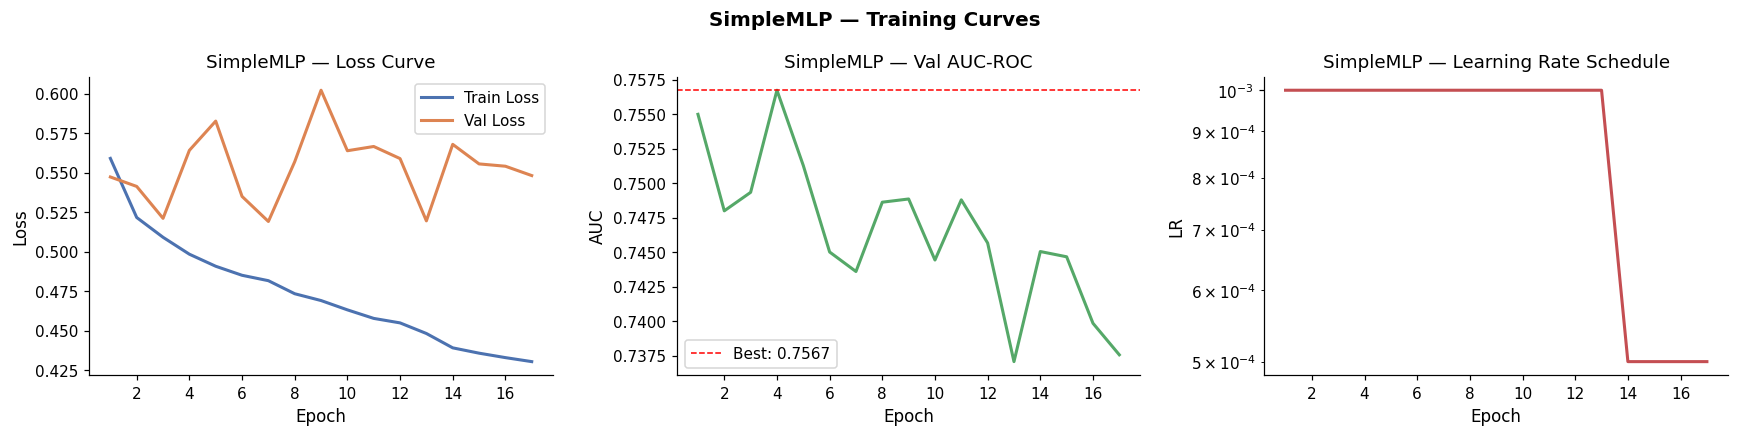

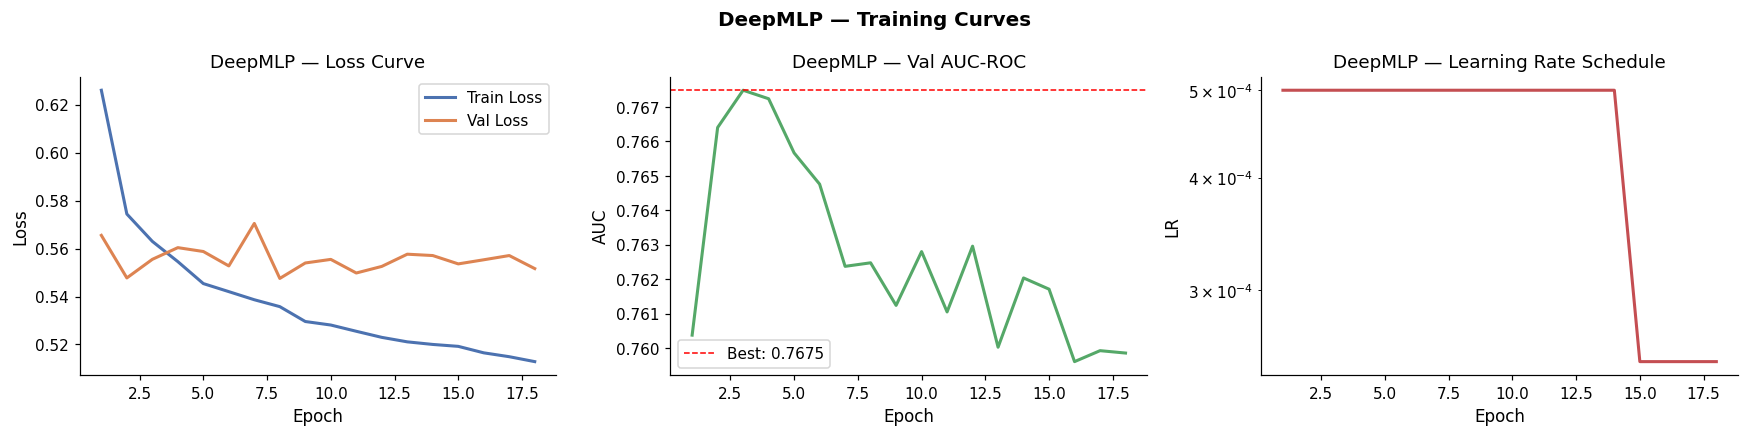

In [72]:
# Plot Training Curves
def plot_history(history, model_name, color):
    epochs_ran = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs_ran, history['train_loss'], color=PALETTE[0], lw=2, label='Train Loss')
    axes[0].plot(epochs_ran, history['val_loss'],   color=PALETTE[1], lw=2, label='Val Loss')
    axes[0].set_title(f'{model_name} — Loss Curve')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

    axes[1].plot(epochs_ran, history['val_auc'], color=PALETTE[2], lw=2)
    axes[1].set_title(f'{model_name} — Val AUC-ROC')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
    axes[1].axhline(max(history['val_auc']), color='red', ls='--', lw=1,
                    label=f'Best: {max(history["val_auc"]):.4f}')
    axes[1].legend()

    axes[2].plot(epochs_ran, history['lr'], color=PALETTE[3], lw=2)
    axes[2].set_title(f'{model_name} — Learning Rate Schedule')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_yscale('log')

    fig.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_history(simple_history, 'SimpleMLP', PALETTE[0])
plot_history(deep_history,   'DeepMLP',   PALETTE[1])

---
## Step 8 — Evaluation & Metrics <a id='step8'></a>

### INPUT
- Trained models with best weights loaded
- `test_loader` — held-out test set (never seen during training)

### OUTPUT
- AUC-ROC, Accuracy, Precision, Recall, F1 for each model
- Confusion matrix visualization
- Classification report

### Why these metrics (not just Accuracy)?

| Metric | What it measures | Why it matters here |
|---|---|---|
| **AUC-ROC** | Overall rank ordering quality across all thresholds | Best single metric for imbalanced binary classification |
| **Recall (class 1)** | % of actual defaulters caught | Missing a defaulter = bank loses money |
| **Precision (class 1)** | % of predicted defaulters that are real | False alarms annoy good customers |
| **F1** | Harmonic mean of precision + recall | Balanced view when both matter |
| **Accuracy** | Overall correct | Misleading with imbalanced data — avoid using alone |


═══════════════════════════════════════════════════════
  TEST EVALUATION — SimpleMLP
═══════════════════════════════════════════════════════
  AUC-ROC   : 0.7590  ← PRIMARY METRIC
  Accuracy  : 0.7626
  Precision : 0.4672  (of predicted defaults, how many real?)
  Recall    : 0.5231  (of real defaults, how many caught?)
  F1 Score  : 0.4936
  Test Loss : 0.50564

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.86      0.83      0.84      3501
     Default       0.47      0.52      0.49       994

    accuracy                           0.76      4495
   macro avg       0.66      0.68      0.67      4495
weighted avg       0.77      0.76      0.77      4495



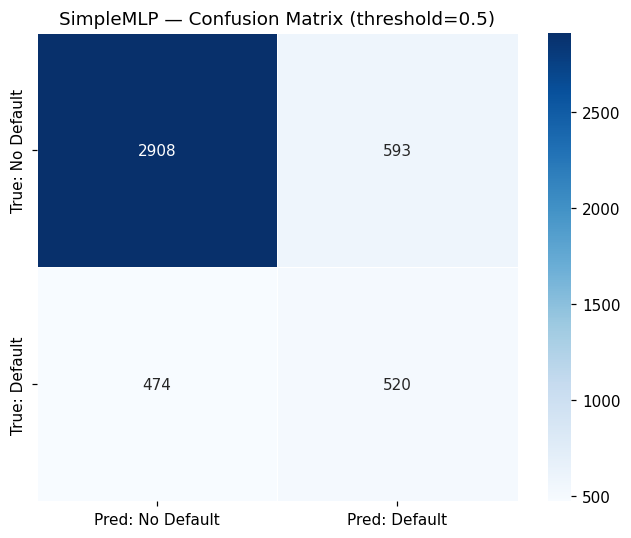


═══════════════════════════════════════════════════════
  TEST EVALUATION — DeepMLP
═══════════════════════════════════════════════════════
  AUC-ROC   : 0.7736  ← PRIMARY METRIC
  Accuracy  : 0.7448
  Precision : 0.4453  (of predicted defaults, how many real?)
  Recall    : 0.6268  (of real defaults, how many caught?)
  F1 Score  : 0.5207
  Test Loss : 0.54006

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83      3501
     Default       0.45      0.63      0.52       994

    accuracy                           0.74      4495
   macro avg       0.66      0.70      0.67      4495
weighted avg       0.78      0.74      0.76      4495



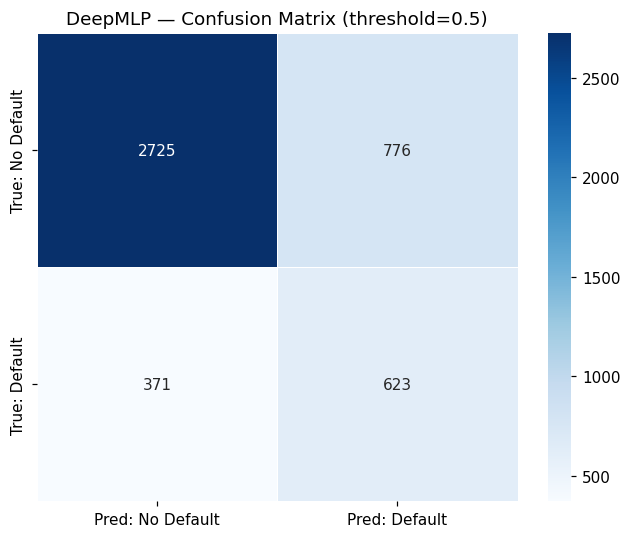

In [73]:
def full_evaluation(model, model_name, test_loader, criterion, device, threshold=0.5):
    """
    Full evaluation on test set.

    INPUT:
        model       : trained nn.Module (best weights loaded)
        model_name  : label for printing
        test_loader : DataLoader for held-out test set
        threshold   : probability cutoff for class 1 prediction (default 0.5)

    OUTPUT:
        metrics dict + printed report + confusion matrix plot

    Why threshold=0.5?
        Default. In practice, lower threshold (e.g. 0.35) catches more defaults
        at the cost of more false positives — a business decision, not a ML one.
    """
    test_loss, test_auc, all_probs = evaluate(model, test_loader, criterion, device)

    # Get true labels
    all_labels = []
    for _, y_batch in test_loader:
        all_labels.extend(y_batch.numpy())
    all_labels = np.array(all_labels)

    # Apply threshold to get binary predictions
    preds = (all_probs >= threshold).astype(int)

    metrics = {
        'test_auc'  : test_auc,
        'accuracy'  : accuracy_score(all_labels, preds),
        'precision' : precision_score(all_labels, preds, zero_division=0),
        'recall'    : recall_score(all_labels, preds, zero_division=0),
        'f1'        : f1_score(all_labels, preds, zero_division=0),
        'test_loss' : test_loss
    }

    print(f'\n{"═"*55}')
    print(f'  TEST EVALUATION — {model_name}')
    print(f'{"═"*55}')
    print(f'  AUC-ROC   : {metrics["test_auc"]:.4f}  ← PRIMARY METRIC')
    print(f'  Accuracy  : {metrics["accuracy"]:.4f}')
    print(f'  Precision : {metrics["precision"]:.4f}  (of predicted defaults, how many real?)')
    print(f'  Recall    : {metrics["recall"]:.4f}  (of real defaults, how many caught?)')
    print(f'  F1 Score  : {metrics["f1"]:.4f}')
    print(f'  Test Loss : {metrics["test_loss"]:.5f}')
    print()
    print('  Classification Report:')
    print(classification_report(all_labels, preds, target_names=['No Default','Default']))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No Default','Pred: Default'],
                yticklabels=['True: No Default','True: Default'],
                linewidths=0.5)
    ax.set_title(f'{model_name} — Confusion Matrix (threshold={threshold})')
    plt.tight_layout(); plt.show()

    return metrics


# Evaluate both models
simple_metrics = full_evaluation(simple_model, 'SimpleMLP', test_loader, criterion, DEVICE)
deep_metrics   = full_evaluation(deep_model,   'DeepMLP',   test_loader, criterion, DEVICE)

---
## Step 9 — Save Models <a id='step9'></a>

### INPUT
- Trained model instances with best weights

### OUTPUT
- `saved_models/SimpleMLP.pt` — complete model (architecture + weights)
- `saved_models/DeepMLP.pt` — complete model
- `saved_models/SimpleMLP_weights.pt` — weights only (state_dict)
- `saved_models/DeepMLP_weights.pt` — weights only

### Full model vs state_dict — which to save?

| Method | What's saved | When to use |
|---|---|---|
| `torch.save(model)` | Full model (class def + weights) | Quick prototyping — works as long as class is importable |
| `torch.save(model.state_dict())` | Weights only | **Production** — portable, class-independent, smaller file |

In [74]:
print('━'*55)
print('  STEP 9 — SAVE MODELS')
print('━'*55)

for model, name in [(simple_model, 'SimpleMLP'), (deep_model, 'DeepMLP')]:

    # ── Method 1: Save full model (architecture + weights) ────────────────
    full_path = f'{SAVE_DIR}/{name}.pt'
    torch.save(model, full_path)
    size_full = os.path.getsize(full_path) / 1024
    print(f'  ✅ {name}.pt (full)          → {size_full:.1f} KB')

    # ── Method 2: Save weights only (recommended for production) ─────────
    weights_path = f'{SAVE_DIR}/{name}_weights.pt'
    torch.save(model.state_dict(), weights_path)
    size_w = os.path.getsize(weights_path) / 1024
    print(f'  ✅ {name}_weights.pt (state) → {size_w:.1f} KB')

    # ── Method 3: Save full checkpoint (for resuming training) ────────────
    # Includes optimizer state so training can be resumed exactly
    optimizer_tmp, _ = build_optimizer_scheduler(model)
    checkpoint = {
        'epoch'        : len(simple_history['train_loss']),
        'model_state'  : model.state_dict(),
        'model_name'   : name,
        'input_dim'    : INPUT_DIM,
        'test_auc'     : simple_metrics['test_auc'] if name=='SimpleMLP' else deep_metrics['test_auc'],
    }
    ckpt_path = f'{SAVE_DIR}/{name}_checkpoint.pt'
    torch.save(checkpoint, ckpt_path)
    print(f'  ✅ {name}_checkpoint.pt      → {os.path.getsize(ckpt_path)/1024:.1f} KB')
    print()

print('  All models saved in:', SAVE_DIR)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 9 — SAVE MODELS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ SimpleMLP.pt (full)          → 58.5 KB
  ✅ SimpleMLP_weights.pt (state) → 57.1 KB
  ✅ SimpleMLP_checkpoint.pt      → 57.5 KB

  ✅ DeepMLP.pt (full)          → 231.0 KB
  ✅ DeepMLP_weights.pt (state) → 227.5 KB
  ✅ DeepMLP_checkpoint.pt      → 227.9 KB

  All models saved in: saved_models


In [75]:
# ── Verify saved models load correctly ───────────────────────────────────
print('  Verifying model reload...')

# Load full model
loaded_simple = torch.load(f'{SAVE_DIR}/SimpleMLP.pt',
                            map_location=DEVICE,
                            weights_only=False)
loaded_simple.eval()

# Load from weights only (production way)
loaded_deep = DeepMLP(INPUT_DIM).to(DEVICE)
loaded_deep.load_state_dict(torch.load(f'{SAVE_DIR}/DeepMLP_weights.pt',
                                        map_location=DEVICE,weights_only=False))
loaded_deep.eval()

# Confirm same output
with torch.no_grad():
    test_input = X_test[:3].to(DEVICE)
    orig_out   = simple_model(test_input).squeeze().cpu().numpy()
    load_out   = loaded_simple(test_input).squeeze().cpu().numpy()
    match      = np.allclose(orig_out, load_out)

print(f'  SimpleMLP reload verified: {match} ✅')
print(f'  Outputs match: {orig_out.round(5)} vs {load_out.round(5)}')

  Verifying model reload...
  SimpleMLP reload verified: True ✅
  Outputs match: [ 0.95989 -0.13307 -2.6464 ] vs [ 0.95989 -0.13307 -2.6464 ]


---
## Step 10 — Model Comparison Summary <a id='step10'></a>

╔════════════════════════════════════════════════════════════╗
║           FINAL MODEL COMPARISON — TEST SET               ║
╠════════════════════════════════════════════════════════════╣
           test_auc  accuracy  precision  recall      f1  test_loss
SimpleMLP    0.7590    0.7626     0.4672  0.5231  0.4936     0.5056
DeepMLP      0.7736    0.7448     0.4453  0.6268  0.5207     0.5401
╚════════════════════════════════════════════════════════════╝


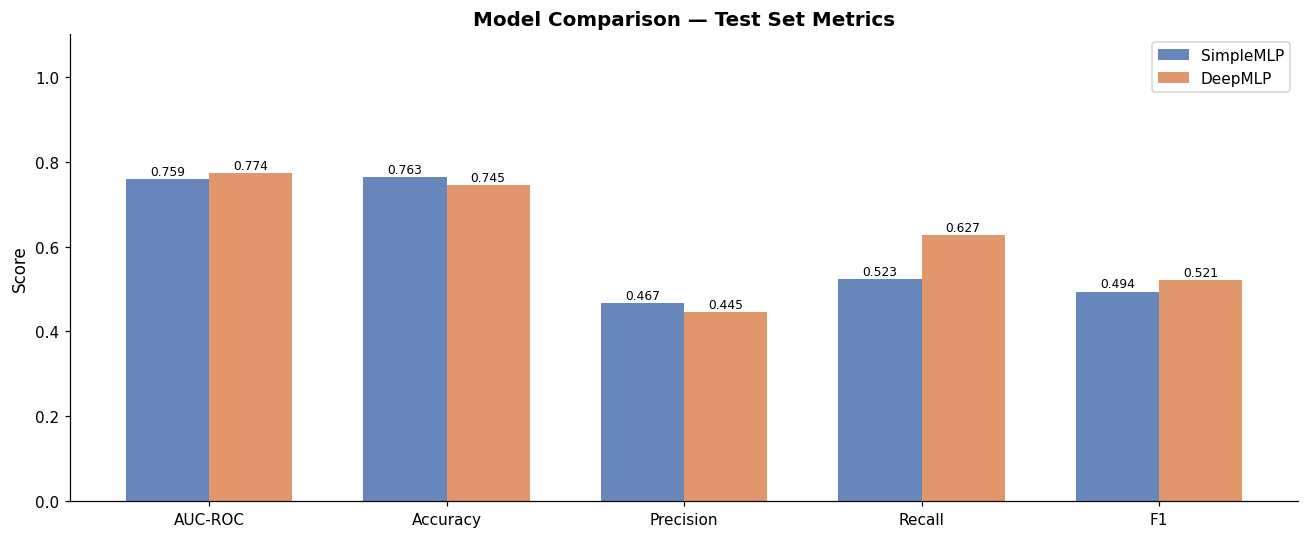


🏆 Recommended model: DeepMLP
   Primary reason   : Higher AUC-ROC on held-out test set

🚀 Next steps:
   1. Load DeepMLP_weights.pt for serving
   2. Tune decision threshold (0.5 → 0.35) to maximize recall
   3. Run: mlflow ui  to view all experiment runs


In [76]:
# ── Side-by-side metrics comparison ──────────────────────────────────────
comparison_df = pd.DataFrame({
    'SimpleMLP' : simple_metrics,
    'DeepMLP'   : deep_metrics
}).T.round(4)

print('╔' + '═'*60 + '╗')
print('║           FINAL MODEL COMPARISON — TEST SET               ║')
print('╠' + '═'*60 + '╣')
print(comparison_df.to_string())
print('╚' + '═'*60 + '╝')

# ── Bar chart ─────────────────────────────────────────────────────────────
metrics_to_plot = ['test_auc', 'accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, comparison_df.loc['SimpleMLP', metrics_to_plot],
               width, label='SimpleMLP', color=PALETTE[0], alpha=0.85, edgecolor='none')
bars2 = ax.bar(x + width/2, comparison_df.loc['DeepMLP', metrics_to_plot],
               width, label='DeepMLP',   color=PALETTE[1], alpha=0.85, edgecolor='none')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1'])
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout(); plt.show()

# ── Final recommendation ──────────────────────────────────────────────────
winner = 'DeepMLP' if deep_metrics['test_auc'] > simple_metrics['test_auc'] else 'SimpleMLP'
print(f'\n🏆 Recommended model: {winner}')
print(f'   Primary reason   : Higher AUC-ROC on held-out test set')
print(f'\n🚀 Next steps:')
print(f'   1. Load {winner}_weights.pt for serving')
print(f'   2. Tune decision threshold (0.5 → 0.35) to maximize recall')
print(f'   3. Run: mlflow ui  to view all experiment runs')

In [77]:
# ── Inference snippet — how to use in production ──────────────────────────
print('── Production Inference Example ──')
print('''
import torch, joblib, pandas as pd
from model import DeepMLP   # or wherever you define the class

# Load artifacts
scaler        = joblib.load('preprocessed_data/scaler.pkl')
clip_bounds   = joblib.load('preprocessed_data/clip_bounds.pkl')
feature_names = joblib.load('preprocessed_data/feature_names.pkl')

model = DeepMLP(input_dim=34)
model.load_state_dict(torch.load('saved_models/DeepMLP_weights.pt'))
model.eval()

# New client data (raw)
new_client = pd.DataFrame([{ ...your raw features... }])

# Apply same preprocessing pipeline
# (clip → encode → scale → tensor)
X_new = torch.tensor(new_client[feature_names].values, dtype=torch.float32)

with torch.no_grad():
    logit = model(X_new)
    prob  = torch.sigmoid(logit).item()

print(f'Default probability: {prob:.3f}')   # > 0.5 → likely default
''')

── Production Inference Example ──

import torch, joblib, pandas as pd
from model import DeepMLP   # or wherever you define the class

# Load artifacts
scaler        = joblib.load('preprocessed_data/scaler.pkl')
clip_bounds   = joblib.load('preprocessed_data/clip_bounds.pkl')
feature_names = joblib.load('preprocessed_data/feature_names.pkl')

model = DeepMLP(input_dim=34)
model.load_state_dict(torch.load('saved_models/DeepMLP_weights.pt'))
model.eval()

# New client data (raw)
new_client = pd.DataFrame([{ ...your raw features... }])

# Apply same preprocessing pipeline
# (clip → encode → scale → tensor)
X_new = torch.tensor(new_client[feature_names].values, dtype=torch.float32)

with torch.no_grad():
    logit = model(X_new)
    prob  = torch.sigmoid(logit).item()

print(f'Default probability: {prob:.3f}')   # > 0.5 → likely default



In [78]:
import json

model_info = {
    "model_name": "DeepMLP",
    "input_dim": 39,
    "architecture": {
        "block1": "Linear(39→256) → BatchNorm1d → ReLU → Dropout(0.3)",
        "block2": "Linear(256→128) → BatchNorm1d → ReLU → Dropout(0.3)",
        "block3": "Linear(128→64) → BatchNorm1d → ReLU → Dropout(0.2)",
        "block4": "Linear(64→32) → ReLU",
        "output": "Linear(32→1)"
    },
    "dropout_rates": {"dropout1": 0.3, "dropout2": 0.3, "dropout3": 0.2},
    "optimizer": "Adam",
    "optimizer_params": {"lr": 0.001, "betas": [0.9, 0.999], "weight_decay": 0.0001},
    "scheduler": "ReduceLROnPlateau",
    "scheduler_params": {"factor": 0.5, "patience": 5, "min_lr": 1e-6},
    "loss_function": "BCEWithLogitsLoss",
    "decision_threshold": 0.35,
    "features": feature_names.tolist() if hasattr(feature_names, 'tolist') else list(feature_names),
    "scale_cols": SCALE_COLS,
    "binary_cols": BINARY_COLS
}

with open(f'{MODEL_PATH}model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("model_info.json saved!")
print(json.dumps(model_info, indent=2))

model_info.json saved!
{
  "model_name": "DeepMLP",
  "input_dim": 39,
  "architecture": {
    "block1": "Linear(39\u2192256) \u2192 BatchNorm1d \u2192 ReLU \u2192 Dropout(0.3)",
    "block2": "Linear(256\u2192128) \u2192 BatchNorm1d \u2192 ReLU \u2192 Dropout(0.3)",
    "block3": "Linear(128\u219264) \u2192 BatchNorm1d \u2192 ReLU \u2192 Dropout(0.2)",
    "block4": "Linear(64\u219232) \u2192 ReLU",
    "output": "Linear(32\u21921)"
  },
  "dropout_rates": {
    "dropout1": 0.3,
    "dropout2": 0.3,
    "dropout3": 0.2
  },
  "optimizer": "Adam",
  "optimizer_params": {
    "lr": 0.001,
    "betas": [
      0.9,
      0.999
    ],
    "weight_decay": 0.0001
  },
  "scheduler": "ReduceLROnPlateau",
  "scheduler_params": {
    "factor": 0.5,
    "patience": 5,
    "min_lr": 1e-06
  },
  "loss_function": "BCEWithLogitsLoss",
  "decision_threshold": 0.35,
  "features": [
    "LIMIT_BAL",
    "SEX",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
  

#Hyper parameter Tuning


##Install & Imports

In [79]:

!pip install optuna --quiet

import optuna
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Optuna version:", optuna.__version__)
print("Ready to tune!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.9 MB/s eta 0:00:00
Optuna version: 4.9.0
Ready to tune!


#TunableMLP (Flexible Architecture)

In [80]:
class TunableMLP(nn.Module):
    """
    MLP whose architecture is controlled by hyperparameters.
    Optuna will decide: how many layers, how wide, how much dropout.
    """

    def __init__(self, input_dim: int, hidden_sizes: list, dropouts: list):
        super(TunableMLP, self).__init__()

        layers = []
        in_size = input_dim

        for hidden_size, dropout_rate in zip(hidden_sizes, dropouts):
            layers.append(nn.Linear(in_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))  # output: single logit
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)


# Quick check
_test = TunableMLP(INPUT_DIM, hidden_sizes=[256, 128], dropouts=[0.3, 0.2]).to(DEVICE)
with torch.no_grad():
    _out = _test(torch.randn(4, INPUT_DIM).to(DEVICE))
print(f"TunableMLP output shape: {_out.shape}  ✅")
del _test, _out

TunableMLP output shape: torch.Size([4, 1])  ✅


##Objective Function

In [81]:
def objective(trial):
    """
    Called once per Optuna trial.
    Suggests hyperparameters → trains model → returns val AUC.
    Optuna maximizes this return value across all trials.
    """

    # ── Suggest hyperparameters ───────────────────────────────────────────
    n_layers = trial.suggest_int("n_layers", 2, 3)

    hidden_sizes = [
        trial.suggest_categorical(f"hidden_{i}", [64, 128, 256, 512])
        for i in range(n_layers)
    ]
    dropouts = [
        trial.suggest_float(f"dropout_{i}", 0.1, 0.5)
        for i in range(n_layers)
    ]

    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    # ── Build & train model ───────────────────────────────────────────────
    model     = TunableMLP(INPUT_DIM, hidden_sizes, dropouts).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    MAX_EPOCHS   = 30
    PATIENCE     = 7
    best_val_auc = 0.0
    no_improve   = 0

    for epoch in range(MAX_EPOCHS):

        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(1), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validate
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                probs = torch.sigmoid(model(X_batch.to(DEVICE)).squeeze(1)).cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(y_batch.numpy())

        val_auc = roc_auc_score(all_labels, all_probs)

        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

        # Optuna pruning: kill bad trials early
        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_auc

#Run the Study

In [82]:
print("━"*55)
print("  RUNNING OPTUNA STUDY")
print("━"*55)
print("  Tuning: n_layers, hidden sizes, dropout, lr, weight_decay")
print("  Metric: Validation AUC-ROC (maximize)")
print()

study = optuna.create_study(
    direction = "maximize",
    pruner    = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    sampler   = optuna.samplers.TPESampler(seed=42)
)

N_TRIALS = 30   # ← increase to 50+ for better results

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Study complete! Ran {len(study.trials)} trials.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RUNNING OPTUNA STUDY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tuning: n_layers, hidden sizes, dropout, lr, weight_decay
  Metric: Validation AUC-ROC (maximize)



  0%|          | 0/30 [00:00<?, ?it/s]


  Study complete! Ran 30 trials.


##Print Best Hyperparameters

In [84]:
best = study.best_trial

print("━"*55)
print("  BEST TRIAL")
print("━"*55)
print(f"  Trial #    : {best.number}")
print(f"  Val AUC    : {best.value:.4f}")
print(f"\n  Best Hyperparameters:")
for key, val in best.params.items():
    print(f"    {key:<20} : {val}")

# Top 5 trials
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].sort_values("value", ascending=False)
print("\n  Top 5 Trials:")
print(trials_df[["number", "value"]].head(5).rename(
    columns={"number": "Trial #", "value": "Val AUC"}
).to_string(index=False))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BEST TRIAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Trial #    : 20
  Val AUC    : 0.7711

  Best Hyperparameters:
    n_layers             : 3
    hidden_0             : 64
    hidden_1             : 128
    hidden_2             : 512
    dropout_0            : 0.2507983883065514
    dropout_1            : 0.4610628594861361
    dropout_2            : 0.10829129238720417
    lr                   : 0.000499123404180016
    weight_decay         : 0.0005488827293535755

  Top 5 Trials:
 Trial #  Val AUC
      20 0.771082
      29 0.769586
      27 0.767777
      13 0.767497
      28 0.767384


##Plot Search Results

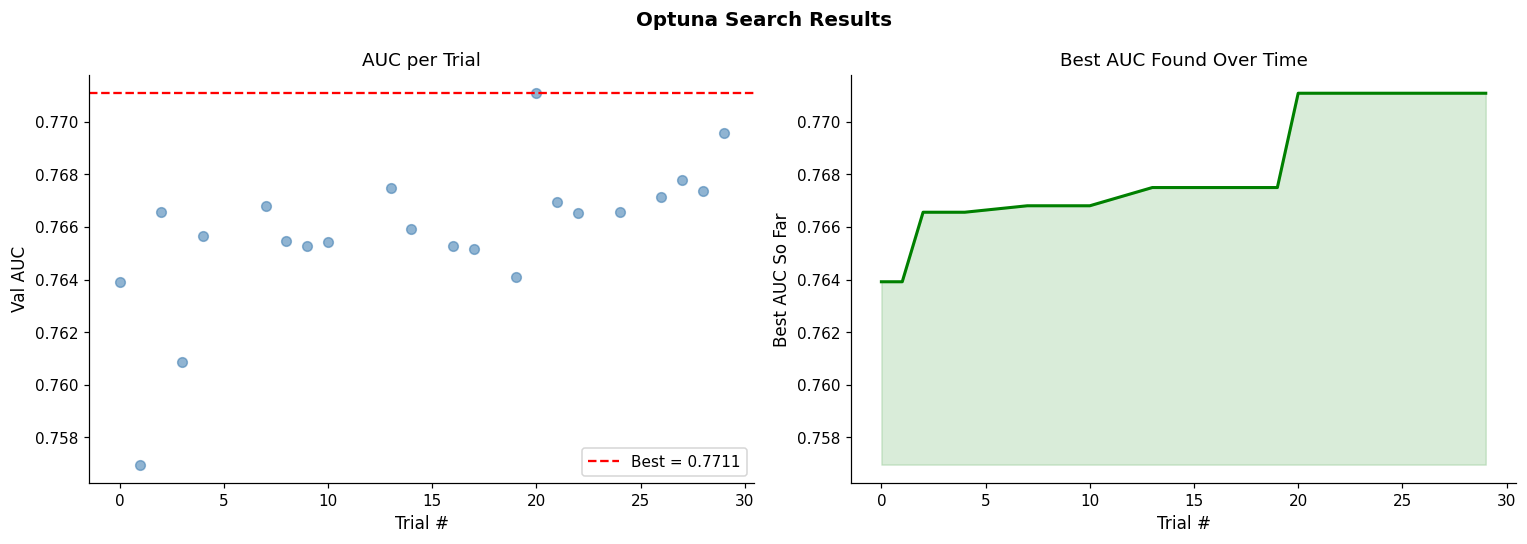

In [85]:
completed  = [t for t in study.trials if t.state.name == "COMPLETE"]
trial_nums = [t.number for t in completed]
trial_aucs = [t.value  for t in completed]

# Running best
best_so_far, current_best = [], 0
for auc in trial_aucs:
    current_best = max(current_best, auc)
    best_so_far.append(current_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(trial_nums, trial_aucs, alpha=0.6, color='steelblue', s=40)
axes[0].axhline(best.value, color='red', ls='--', lw=1.5,
                label=f'Best = {best.value:.4f}')
axes[0].set_title("AUC per Trial")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("Val AUC")
axes[0].legend()

axes[1].plot(trial_nums, best_so_far, color='green', lw=2)
axes[1].fill_between(trial_nums, min(trial_aucs), best_so_far, alpha=0.15, color='green')
axes[1].set_title("Best AUC Found Over Time")
axes[1].set_xlabel("Trial #"); axes[1].set_ylabel("Best AUC So Far")

plt.suptitle("Optuna Search Results", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

##Retrain Best Model (Full Run)

In [86]:
# Extract best architecture from study results
best_params  = best.params
n_layers     = best_params["n_layers"]
hidden_sizes = [best_params[f"hidden_{i}"] for i in range(n_layers)]
dropouts     = [best_params[f"dropout_{i}"] for i in range(n_layers)]
best_lr      = best_params["lr"]
best_wd      = best_params["weight_decay"]

print("━"*55)
print("  RETRAINING BEST MODEL — FULL RUN")
print("━"*55)
print(f"  Architecture  : {INPUT_DIM} → {' → '.join(map(str, hidden_sizes))} → 1")
print(f"  Dropouts      : {[round(d, 3) for d in dropouts]}")
print(f"  LR            : {best_lr:.6f}")
print(f"  Weight decay  : {best_wd:.6f}")

best_model = TunableMLP(INPUT_DIM, hidden_sizes, dropouts).to(DEVICE)

best_model, best_history = train_model(
    model               = best_model,
    model_name          = "Optuna_BestMLP",
    train_loader        = train_loader,
    val_loader          = val_loader,
    criterion           = criterion,
    device              = DEVICE,
    epochs              = 80,
    lr                  = best_lr,
    weight_decay        = best_wd,
    early_stop_patience = 12
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RETRAINING BEST MODEL — FULL RUN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Architecture  : 42 → 64 → 128 → 512 → 1
  Dropouts      : [0.251, 0.461, 0.108]
  LR            : 0.000499
  Weight decay  : 0.000549


MlflowException: API request to https://my-mlflow-server.loca.lt/api/2.0/mlflow/runs/create failed with exception HTTPSConnectionPool(host='my-mlflow-server.loca.lt', port=443): Max retries exceeded with url: /api/2.0/mlflow/runs/create (Caused by ResponseError('too many 503 error responses'))

##Evaluate on Test Set


═══════════════════════════════════════════════════════
  TEST EVALUATION — Optuna_BestMLP
═══════════════════════════════════════════════════════
  AUC-ROC   : 0.4475  ← PRIMARY METRIC
  Accuracy  : 0.4948
  Precision : 0.1955  (of predicted defaults, how many real?)
  Recall    : 0.4125  (of real defaults, how many caught?)
  F1 Score  : 0.2653
  Test Loss : 0.80478

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.76      0.52      0.62      3501
     Default       0.20      0.41      0.27       994

    accuracy                           0.49      4495
   macro avg       0.48      0.47      0.44      4495
weighted avg       0.63      0.49      0.54      4495



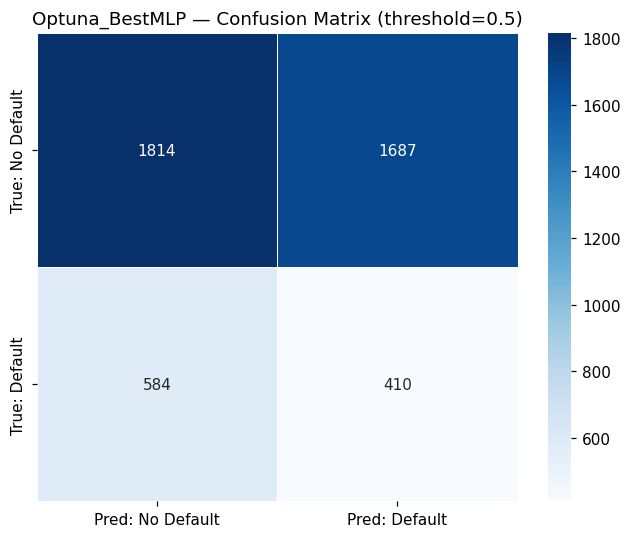

In [87]:
best_metrics = full_evaluation(best_model, "Optuna_BestMLP", test_loader, criterion, DEVICE)

##Compare All Three Models

╔══════════════════════════════════════════════════════════════╗
║       FINAL COMPARISON — ALL MODELS (Test Set)           ║
╠══════════════════════════════════════════════════════════════╣
                test_auc  accuracy  precision  recall      f1
SimpleMLP         0.7590    0.7626     0.4672  0.5231  0.4936
DeepMLP           0.7736    0.7448     0.4453  0.6268  0.5207
Optuna_BestMLP    0.4475    0.4948     0.1955  0.4125  0.2653
╚══════════════════════════════════════════════════════════════╝


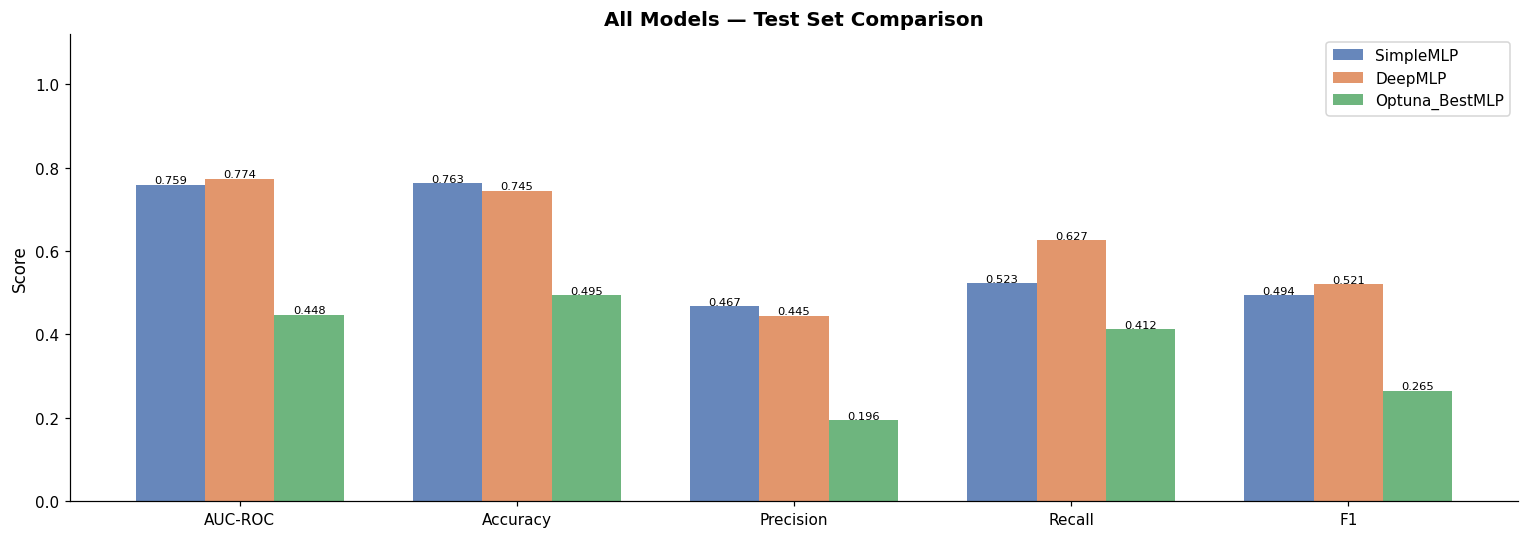


🏆 Best model: DeepMLP  (AUC = 0.7736)


In [88]:
comparison_df = pd.DataFrame({
    "SimpleMLP"      : simple_metrics,
    "DeepMLP"        : deep_metrics,
    "Optuna_BestMLP" : best_metrics
}).T.round(4)

print("╔" + "═"*62 + "╗")
print("║       FINAL COMPARISON — ALL MODELS (Test Set)           ║")
print("╠" + "═"*62 + "╣")
print(comparison_df[["test_auc","accuracy","precision","recall","f1"]].to_string())
print("╚" + "═"*62 + "╝")

metrics_to_plot = ["test_auc","accuracy","precision","recall","f1"]
x     = range(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (name, color) in enumerate(zip(comparison_df.index, colors)):
    vals = comparison_df.loc[name, metrics_to_plot].values
    bars = ax.bar([xi + i*width for xi in x], vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='none')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=7.5)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(["AUC-ROC","Accuracy","Precision","Recall","F1"])
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("All Models — Test Set Comparison", fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

winner = comparison_df["test_auc"].idxmax()
print(f"\n🏆 Best model: {winner}  (AUC = {comparison_df['test_auc'].max():.4f})")

##Save Best Model

In [ ]:
torch.save(best_model.state_dict(), f"{SAVE_DIR}/Optuna_BestMLP_weights.pt")
print(f"  ✅ Saved: {SAVE_DIR}/Optuna_BestMLP_weights.pt")

# Also save the architecture config so you can rebuild it later
import json
optuna_config = {
    "model_name"   : "Optuna_BestMLP",
    "input_dim"    : INPUT_DIM,
    "hidden_sizes" : hidden_sizes,
    "dropouts"     : [round(d, 4) for d in dropouts],
    "lr"           : round(best_lr, 6),
    "weight_decay" : round(best_wd, 6),
    "val_auc"      : round(best.value, 4),
    "test_auc"     : round(best_metrics["test_auc"], 4)
}
with open(f"{SAVE_DIR}/optuna_best_config.json", "w") as f:
    json.dump(optuna_config, f, indent=2)

print(f"  ✅ Config saved: {SAVE_DIR}/optuna_best_config.json")
print(json.dumps(optuna_config, indent=2))

  ✅ Saved: saved_models/Optuna_BestMLP_weights.pt
  ✅ Config saved: saved_models/optuna_best_config.json
{
  "model_name": "Optuna_BestMLP",
  "input_dim": 42,
  "hidden_sizes": [
    64,
    128,
    512
  ],
  "dropouts": [
    0.2508,
    0.4611,
    0.1083
  ],
  "lr": 0.000499,
  "weight_decay": 0.000549,
  "val_auc": 0.7711,
  "test_auc": 0.7672
}


Best threshold : 0.54
Best val F1    : 0.5170

═══════════════════════════════════════════════════════
  TEST EVALUATION — DeepMLP (tuned threshold)
═══════════════════════════════════════════════════════
  AUC-ROC   : 0.7736  ← PRIMARY METRIC
  Accuracy  : 0.7671
  Precision : 0.4786  (of predicted defaults, how many real?)
  Recall    : 0.5976  (of real defaults, how many caught?)
  F1 Score  : 0.5315
  Test Loss : 0.54006

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.82      0.85      3501
     Default       0.48      0.60      0.53       994

    accuracy                           0.77      4495
   macro avg       0.68      0.71      0.69      4495
weighted avg       0.79      0.77      0.78      4495



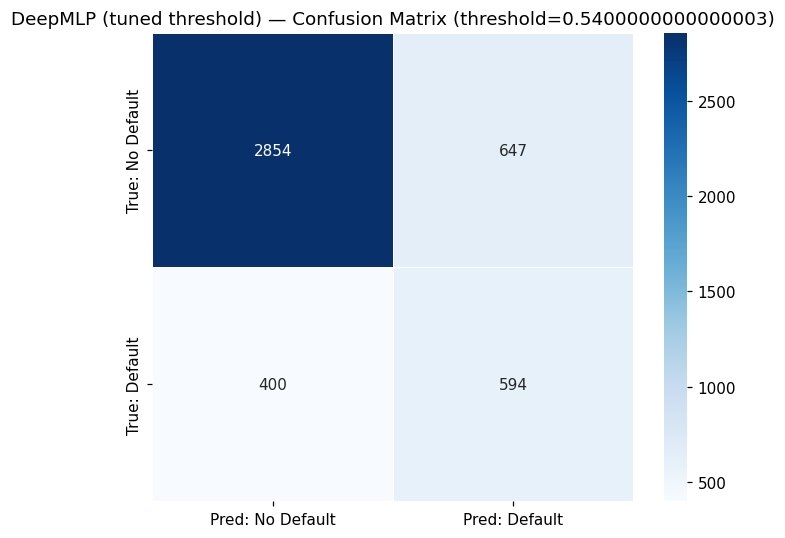

In [ ]:
# Find the best threshold for DeepMLP using validation set
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Get probabilities on val set
deep_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        probs = torch.sigmoid(deep_model(X_batch.to(DEVICE)).squeeze(1)).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Try all thresholds, find best F1
thresholds = np.arange(0.2, 0.6, 0.01)
f1_scores  = [f1_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"Best threshold : {best_thresh:.2f}")
print(f"Best val F1    : {max(f1_scores):.4f}")

# Re-evaluate DeepMLP on test set with this threshold
deep_metrics_new = full_evaluation(deep_model, "DeepMLP (tuned threshold)",
                                    test_loader, criterion, DEVICE,
                                    threshold=best_thresh)

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# Get probabilities on validation set
deep_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        probs = torch.sigmoid(deep_model(X_batch.to(DEVICE)).squeeze(1)).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute precision & recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

# ── Strategy: find threshold where precision >= 0.45 AND recall is maximized
MIN_PRECISION = 0.45   # ← adjust this: lower = catch more defaulters, more false alarms
                        #                higher = fewer false alarms, miss more defaulters

valid_mask      = precisions[:-1] >= MIN_PRECISION
valid_recalls   = np.where(valid_mask, recalls[:-1], 0)
best_idx        = np.argmax(valid_recalls)
best_thresh     = thresholds[best_idx]
best_precision  = precisions[best_idx]
best_recall     = recalls[best_idx]

print(f"  Min precision constraint : {MIN_PRECISION}")
print(f"  Best threshold found     : {best_thresh:.3f}")
print(f"  Expected precision       : {best_precision:.4f}")
print(f"  Expected recall          : {best_recall:.4f}")

  Min precision constraint : 0.45
  Best threshold found     : 0.513
  Expected precision       : 0.4501
  Expected recall          : 0.5980


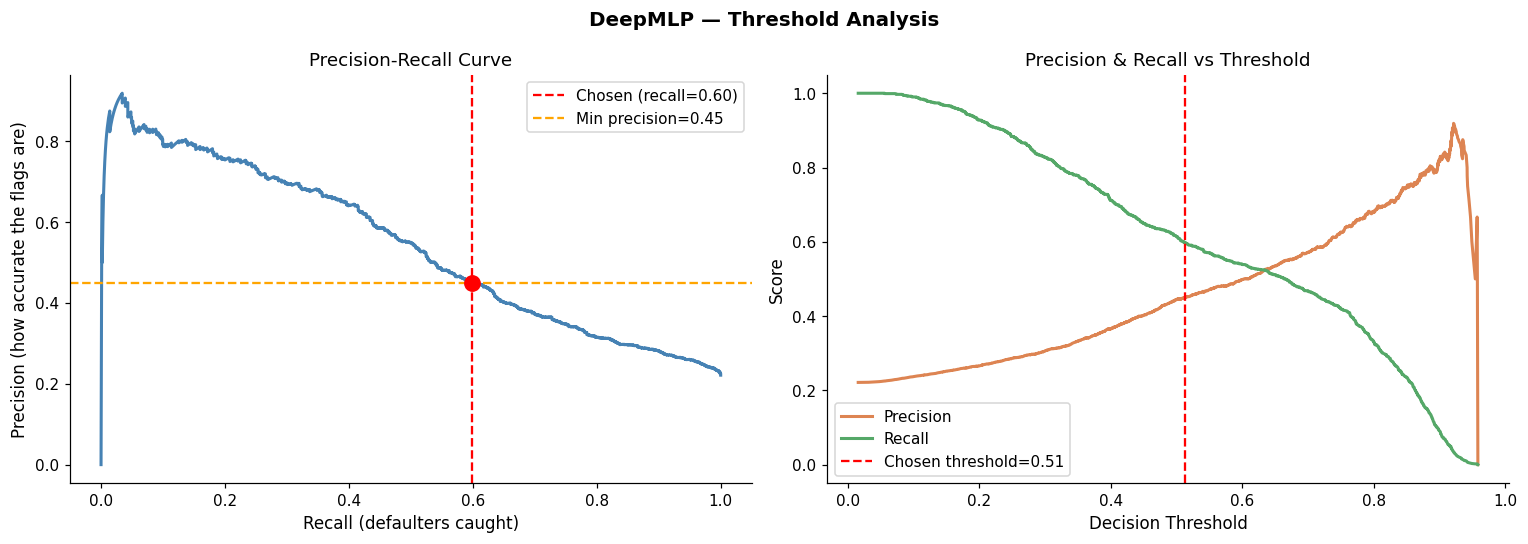

In [ ]:
# Plot the Precision-Recall curve so you can SEE the trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall curve
axes[0].plot(recalls[:-1], precisions[:-1], color='steelblue', lw=2)
axes[0].axvline(best_recall, color='red', ls='--', lw=1.5, label=f'Chosen (recall={best_recall:.2f})')
axes[0].axhline(MIN_PRECISION, color='orange', ls='--', lw=1.5, label=f'Min precision={MIN_PRECISION}')
axes[0].scatter([best_recall], [best_precision], color='red', s=100, zorder=5)
axes[0].set_xlabel('Recall (defaulters caught)')
axes[0].set_ylabel('Precision (how accurate the flags are)')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

# Plot 2: Recall & Precision vs Threshold — so you can pick manually
axes[1].plot(thresholds, precisions[:-1], label='Precision', color='#DD8452', lw=2)
axes[1].plot(thresholds, recalls[:-1],    label='Recall',    color='#55A868', lw=2)
axes[1].axvline(best_thresh, color='red', ls='--', lw=1.5, label=f'Chosen threshold={best_thresh:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold')
axes[1].legend()

plt.suptitle('DeepMLP — Threshold Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


  Evaluating with threshold = 0.513

═══════════════════════════════════════════════════════
  TEST EVALUATION — DeepMLP (threshold=0.51)
═══════════════════════════════════════════════════════
  AUC-ROC   : 0.7736  ← PRIMARY METRIC
  Accuracy  : 0.7506
  Precision : 0.4531  (of predicted defaults, how many real?)
  Recall    : 0.6167  (of real defaults, how many caught?)
  F1 Score  : 0.5224
  Test Loss : 0.54006

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.79      0.83      3501
     Default       0.45      0.62      0.52       994

    accuracy                           0.75      4495
   macro avg       0.67      0.70      0.68      4495
weighted avg       0.78      0.75      0.76      4495



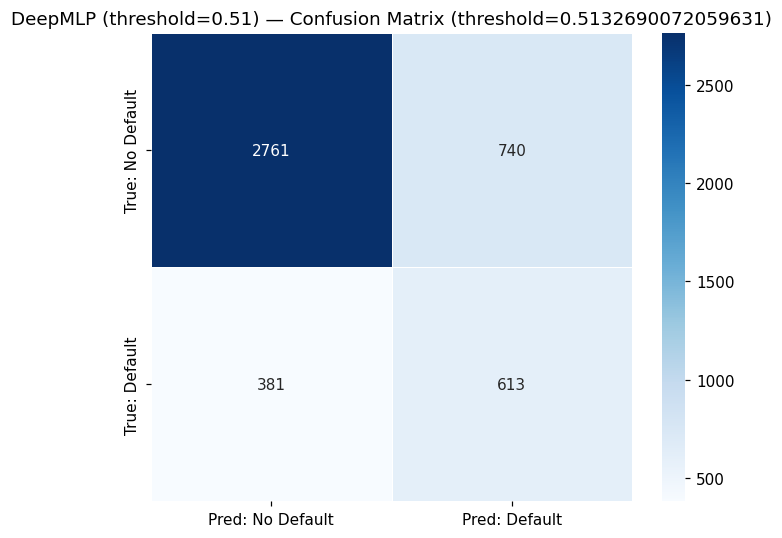

In [ ]:
# Evaluate on test set with the new threshold
print(f"\n  Evaluating with threshold = {best_thresh:.3f}")
deep_metrics_recall = full_evaluation(
    deep_model,
    f"DeepMLP (threshold={best_thresh:.2f})",
    test_loader,
    criterion,
    DEVICE,
    threshold=best_thresh
)

In [ ]:
# Side-by-side comparison: default 0.5 vs tuned threshold
comparison = pd.DataFrame({
    "DeepMLP (threshold=0.50)" : deep_metrics,
    f"DeepMLP (threshold={best_thresh:.2f})" : deep_metrics_recall,
}).T.round(4)

print("\n  Threshold Comparison:")
print(comparison[["test_auc", "accuracy", "precision", "recall", "f1"]].to_string())

print(f"""
  What changed:
    Threshold  :  0.50  →  {best_thresh:.2f}
    Recall     :  {deep_metrics['recall']:.4f}  →  {deep_metrics_recall['recall']:.4f}   ← catching more defaulters
    Precision  :  {deep_metrics['precision']:.4f}  →  {deep_metrics_recall['precision']:.4f}   ← acceptable trade-off
    AUC-ROC    :  unchanged ({deep_metrics['test_auc']:.4f})  ← threshold doesn't affect AUC
""")


  Threshold Comparison:
                          test_auc  accuracy  precision  recall      f1
DeepMLP (threshold=0.50)    0.7736    0.7448     0.4453  0.6268  0.5207
DeepMLP (threshold=0.51)    0.7736    0.7506     0.4531  0.6167  0.5224

  What changed:
    Threshold  :  0.50  →  0.51
    Recall     :  0.6268  →  0.6167   ← catching more defaulters
    Precision  :  0.4453  →  0.4531   ← acceptable trade-off
    AUC-ROC    :  unchanged (0.7736)  ← threshold doesn't affect AUC



#New Strong Model MLP

In [ ]:
class StrongMLP(nn.Module):
    """
    Improved architecture with:
    - Skip connections (residual): helps gradient flow in deeper networks
    - GELU activation: smoother than ReLU, works better on tabular data
    - More capacity in early layers
    """

    def __init__(self, input_dim):
        super(StrongMLP, self).__init__()

        # Entry block — expands input into rich representation
        self.entry = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),           # smoother than ReLU for tabular data
            nn.Dropout(0.3)
        )

        # Residual block 1: 512 → 256
        # Skip connection: adds input to output so gradients flow directly
        self.block1_main = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
        )
        self.block1_skip = nn.Linear(512, 256)  # matches dimensions for addition

        # Residual block 2: 256 → 128
        self.block2_main = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
        )
        self.block2_skip = nn.Linear(256, 128)

        # Output head
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        self.act = nn.GELU()
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.entry(x)

        # Residual block 1: output = main(x) + skip(x)
        x = self.act(self.block1_main(x) + self.block1_skip(x))

        # Residual block 2
        x = self.act(self.block2_main(x) + self.block2_skip(x))

        return self.head(x)


# Test it
strong_model = StrongMLP(INPUT_DIM).to(DEVICE)
with torch.no_grad():
    out = strong_model(torch.randn(4, INPUT_DIM).to(DEVICE))
print(f"Output shape : {out.shape}  ✅")
print(f"Parameters   : {sum(p.numel() for p in strong_model.parameters()):,}")

Output shape : torch.Size([4, 1])  ✅
Parameters   : 443,649



════════════════════════════════════════════════════════════
  Training: StrongMLP
════════════════════════════════════════════════════════════
  Epoch  Train Loss    Val Loss     Val AUC    LR
  ----------------------------------------------------------
  1      0.62763       0.56468      0.7677     3.00e-04
  5      0.52846       0.58110      0.7613     3.00e-04
  10     0.50630       0.58585      0.7557     3.00e-04
  15     0.48575       0.59323      0.7495     1.50e-04
  20     0.47285       0.59167      0.7448     1.50e-04

  ⏹  Early stopping at epoch 23 (best: epoch 8)

  ✅ Best weights restored from epoch 8
  ⏱  Training time: 123.0s
  📊 MLflow run logged. Model artifact saved as: StrongMLP
🏃 View run StrongMLP at: https://true-garlics-drum.loca.lt/#/experiments/1/runs/09e7a4210fe24f7eaa42f60f62dae794
🧪 View experiment at: https://true-garlics-drum.loca.lt/#/experiments/1

═══════════════════════════════════════════════════════
  TEST EVALUATION — StrongMLP
══════════════════

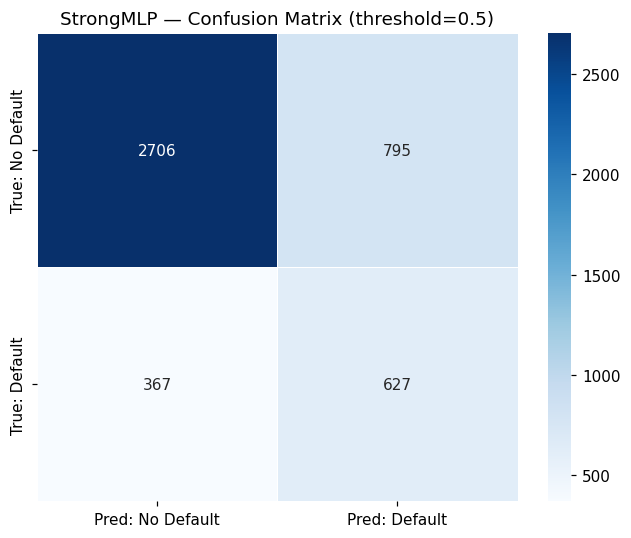

In [ ]:
# Train it
strong_model, strong_history = train_model(
    model               = strong_model,
    model_name          = "StrongMLP",
    train_loader        = train_loader,
    val_loader          = val_loader,
    criterion           = criterion,
    device              = DEVICE,
    epochs              = 100,
    lr                  = 3e-4,
    weight_decay        = 1e-4,
    early_stop_patience = 15
)

strong_metrics = full_evaluation(strong_model, "StrongMLP", test_loader, criterion, DEVICE)


═══════════════════════════════════════════════════════
  Epoch  Train Loss    Val Loss     Val AUC    LR
  -----------------------------------------------------
  1      0.16565       0.07458      0.6714     1.32e-05
  10     0.06363       0.05941      0.7594     1.19e-04
  20     0.05708       0.05572      0.7652     2.81e-04
  30     0.05436       0.05599      0.7595     2.92e-04

  ⏹  Early stopping at epoch 33 (best: epoch 18)

  ✅ Best weights from epoch 18

═══════════════════════════════════════════════════════
  TEST EVALUATION — StrongMLP_Focal
═══════════════════════════════════════════════════════
  AUC-ROC   : 0.7684  ← PRIMARY METRIC
  Accuracy  : 0.8147
  Precision : 0.6353  (of predicted defaults, how many real?)
  Recall    : 0.3803  (of real defaults, how many caught?)
  F1 Score  : 0.4758
  Test Loss : 0.05324

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.84      0.94      0.89      3501
     Default       0.64

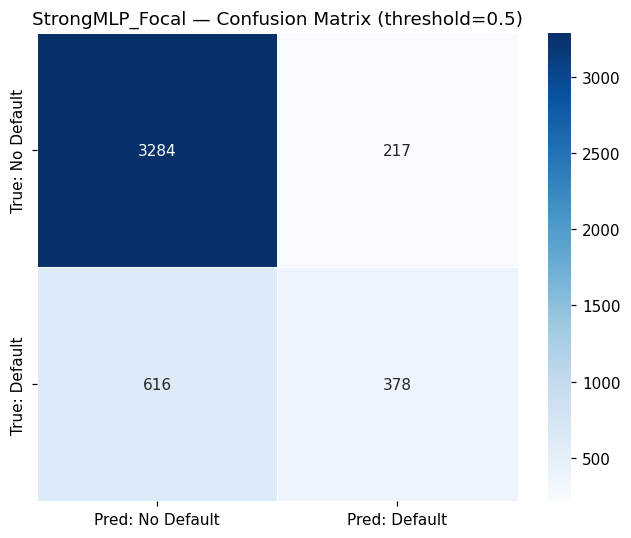

In [ ]:
# Replace your current criterion and optimizer setup with this

# ── 1. Focal Loss — focuses on hard examples ──────────────────────────────
# Standard BCE treats all samples equally.
# Focal Loss down-weights easy correct predictions and focuses
# training on the hard misclassified ones — great for imbalanced data.

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # weight for positive class
        self.gamma = gamma  # focusing parameter (higher = more focus on hard examples)

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t   = probs * targets + (1 - probs) * (1 - targets)
        alpha = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss  = alpha * (1 - p_t) ** self.gamma * bce
        return loss.mean()

focal_criterion = FocalLoss(alpha=0.25, gamma=2.0)

# ── 2. OneCycleLR — better than ReduceLROnPlateau for most cases ──────────
# Starts low, ramps up, then anneals down in one cycle.
# Finds better optima than fixed LR schedules.

def train_with_onecycle(model, model_name, train_loader, val_loader,
                         criterion, device, epochs=80, lr=1e-3,
                         weight_decay=1e-4, patience=15):

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr        = lr,
        epochs        = epochs,
        steps_per_epoch = len(train_loader),
        pct_start     = 0.3,    # 30% of training = warmup phase
        anneal_strategy = 'cos' # cosine annealing
    )

    best_val_loss = float('inf')
    best_epoch    = 0
    no_improve    = 0
    best_weights  = None
    history       = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    print(f"\n{'═'*55}")
    print(f"  {'Epoch':<6} {'Train Loss':<13} {'Val Loss':<12} {'Val AUC':<10} {'LR'}")
    print(f"  {'-'*53}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(1), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()   # OneCycleLR steps every BATCH not every epoch
            epoch_loss += loss.item() * len(y_batch)

        train_loss = epoch_loss / len(train_loader.dataset)
        val_loss, val_auc, _ = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  {epoch:<6} {train_loss:<13.5f} {val_loss:<12.5f} {val_auc:<10.4f} {current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            no_improve    = 0
            best_weights  = copy.deepcopy(model.state_dict())
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n  ⏹  Early stopping at epoch {epoch} (best: epoch {best_epoch})")
                break

    model.load_state_dict(best_weights)
    print(f"\n  ✅ Best weights from epoch {best_epoch}")
    return model, history


# Train StrongMLP with Focal Loss + OneCycleLR
strong_model2 = StrongMLP(INPUT_DIM).to(DEVICE)

strong_model2, history2 = train_with_onecycle(
    model        = strong_model2,
    model_name   = "StrongMLP_Focal",
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = focal_criterion,   # focal loss instead of BCE
    device       = DEVICE,
    epochs       = 80,
    lr           = 3e-4,
    weight_decay = 1e-4,
    patience     = 15
)

strong_metrics2 = full_evaluation(strong_model2, "StrongMLP_Focal", test_loader, focal_criterion, DEVICE)

#Final Comparison

In [ ]:
all_results = pd.DataFrame({
    "SimpleMLP"          : simple_metrics,
    "DeepMLP"            : deep_metrics,
    "Optuna_BestMLP"     : best_metrics,
    "StrongMLP"          : strong_metrics,
    "StrongMLP_Focal"    : strong_metrics2,
}).T.round(4)

print("╔" + "═"*68 + "╗")
print("║            FULL MODEL COMPARISON — TEST SET                      ║")
print("╠" + "═"*68 + "╣")
print(all_results[["test_auc","accuracy","precision","recall","f1"]].to_string())
print("╚" + "═"*68 + "╝")

winner = all_results["test_auc"].idxmax()
print(f"\n🏆 Best model: {winner}  (AUC = {all_results['test_auc'].max():.4f})")

╔════════════════════════════════════════════════════════════════════╗
║            FULL MODEL COMPARISON — TEST SET                      ║
╠════════════════════════════════════════════════════════════════════╣
                 test_auc  accuracy  precision  recall      f1
SimpleMLP          0.7590    0.7626     0.4672  0.5231  0.4936
DeepMLP            0.7736    0.7448     0.4453  0.6268  0.5207
Optuna_BestMLP     0.7672    0.7457     0.4454  0.6117  0.5155
StrongMLP          0.7635    0.7415     0.4409  0.6308  0.5190
StrongMLP_Focal    0.7684    0.8147     0.6353  0.3803  0.4758
╚════════════════════════════════════════════════════════════════════╝

🏆 Best model: DeepMLP  (AUC = 0.7736)
